# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

**Penjelasan Dataset**:
   
Dataset yang digunakan adalah **"Bank Transaction Dataset for Fraud Detection"** dari Kaggle. Dataset ini berisi 2.512 sampel data transaksi yang mencerminkan pola perilaku keuangan dan aktivitas transaksi. Karena tidak memiliki label awal, dataset ini cocok untuk eksplorasi *unsupervised learning* seperti deteksi anomali dan pengelompokan transaksi berdasarkan pola tertentu.

Berikut adalah deskripsi kolom dalam dataset:

1. **TransactionID**: ID unik untuk setiap transaksi.
2. **AccountID**: ID unik untuk setiap akun, yang memiliki beberapa transaksi.
3. **TransactionAmount**: Nilai moneter transaksi, mulai dari pengeluaran kecil hingga pembelian besar (numerikal).
4. **TransactionDate**: Waktu dan tanggal terjadinya transaksi.
5. **TransactionType**: Jenis transaksi, dapat berupa "Credit" atau "Debit" (kategorikal).
6. **Location**: Lokasi geografis transaksi berdasarkan nama kota di AS (kategorikal).
7. **DeviceID**: ID perangkat yang digunakan untuk transaksi.
8. **IPAddress**: Alamat IPv4 terkait transaksi, yang dapat berubah untuk beberapa akun.
9. **MerchantID**: ID unik pedagang, membantu dalam analisis pedagang yang sering digunakan atau mencurigakan.
10. **AccountBalance**: Saldo akun setelah transaksi dilakukan, dengan korelasi logis berdasarkan jenis dan jumlah transaksi (numerikal).
11. **PreviousTransactionDate**: Waktu transaksi terakhir dari akun yang sama, berguna untuk menghitung frekuensi transaksi.
12. **Channel**: Saluran transaksi, seperti "Online", "ATM", atau "Branch" (kategorikal).
13. **CustomerAge**: Usia pemegang akun, yang dikelompokkan secara logis berdasarkan pekerjaan.
14. **CustomerOccupation**: Pekerjaan pemegang akun (misalnya, Dokter, Insinyur, Mahasiswa, Pensiunan), yang mencerminkan pola pendapatan (kategorikal).
15. **TransactionDuration**: Durasi transaksi dalam hitungan detik, bervariasi berdasarkan jenis transaksi.
16. **LoginAttempts**: Jumlah upaya login sebelum transaksi, dengan nilai tinggi yang bisa menunjukkan potensi anomali.

Dataset ini sangat cocok untuk eksplorasi data keuangan dan deteksi kecurangan (*fraud detection*). Dengan kombinasi atribut transaksi, demografi pelanggan, dan pola penggunaan, dataset ini memberikan wawasan mendalam untuk pengembangan model *machine learning* yang berfokus pada keamanan keuangan dan deteksi anomali.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [15]:
%pip install numpy pandas scipy matplotlib seaborn scikit-learn
%pip install kagglehub[pandas-datasets]

# Import library dasar untuk manipulasi dan analisis data
import numpy as np
import pandas as pd

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.preprocessing import RobustScaler, LabelEncoder, PowerTransformer, QuantileTransformer
from scipy.stats.mstats import winsorize
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import library untuk clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, FeatureAgglomeration
from sklearn.metrics import silhouette_score

# Import library Inverse
from scipy.special import inv_boxcox

# Import library untuk feature selection (opsional)
from sklearn.feature_selection import VarianceThreshold

# Import tambahan untuk feature selection otomatis dengan RFECV
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
# Library untuk berinteraksi dengan datasets dari kaggle
import kagglehub

# Library untuk melakukan operasi menggunakan sistem operasi
import os
import warnings

# Mengatur tampilan visualisasi
%matplotlib inline
sns.set_style("whitegrid")


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\ProgramFilesX\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: kagglehub[pandas-datasets] in c:\programfilesx\python310\lib\site-packages (0.3.11)



You should consider upgrading via the 'c:\ProgramFilesX\Python310\python.exe -m pip install --upgrade pip' command.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [16]:
# Download dataset
path = kagglehub.dataset_download("valakhorasani/bank-transaction-dataset-for-fraud-detection")
print("Path to dataset files:", path)

# Memuat dataset
csv_file = os.path.join(path, "bank_transactions_data_2.csv")

# Muat ke DataFrame
df = pd.read_csv(csv_file)

# Simpan ke file CSV baru (opsional)
output_path = "bank_transaction_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Dataset disimpan ke: {output_path}")

Path to dataset files: C:\Users\KillerKing\.cache\kagglehub\datasets\valakhorasani\bank-transaction-dataset-for-fraud-detection\versions\4
Dataset disimpan ke: bank_transaction_dataset.csv


In [17]:
# Memuat dataset dari file CSV (diasumsikan sudah diunduh dari Kaggle)
data = pd.read_csv('bank_transaction_dataset.csv')

# Menampilkan 5 baris pertama dataset
print("5 Baris Pertama Dataset:")
print(data.head())

# Menampilkan informasi dasar dataset
print("\nInformasi Dataset:")
print(data.info())

# Memeriksa jumlah baris dan kolom
print("\nJumlah Baris dan Kolom:", data.shape)

5 Baris Pertama Dataset:
  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70             Doc

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Statistik Deskriptif untuk Kolom Numerikal:
       TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
count        2512.000000  2512.000000          2512.000000    2512.000000   
mean          297.593778    44.673965           119.643312       1.124602   
std           291.946243    17.792198            69.963757       0.602662   
min             0.260000    18.000000            10.000000       1.000000   
25%            81.885000    27.000000            63.000000       1.000000   
50%           211.140000    45.000000           112.500000       1.000000   
75%           414.527500    59.000000           161.000000       1.000000   
max          1919.110000    80.000000           300.000000       5.000000   

       AccountBalance  
count     2512.000000  
mean      5114.302966  
std       3900.942499  
min        101.250000  
25%       1504.370000  
50%       4735.510000  
75%       7678.820000  
max      14977.990000  

Statistik Deskriptif untuk Kolom Kategorikal:

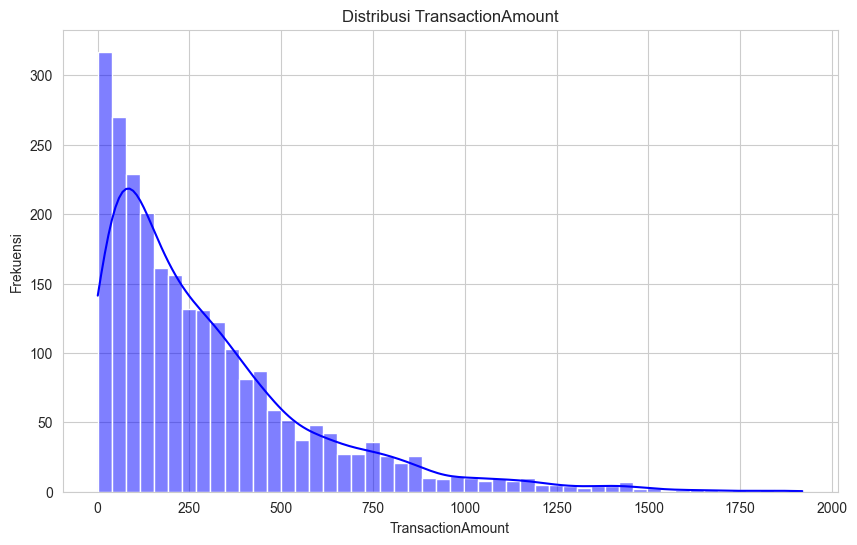

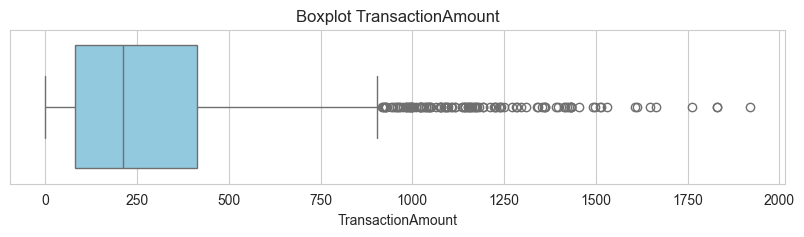

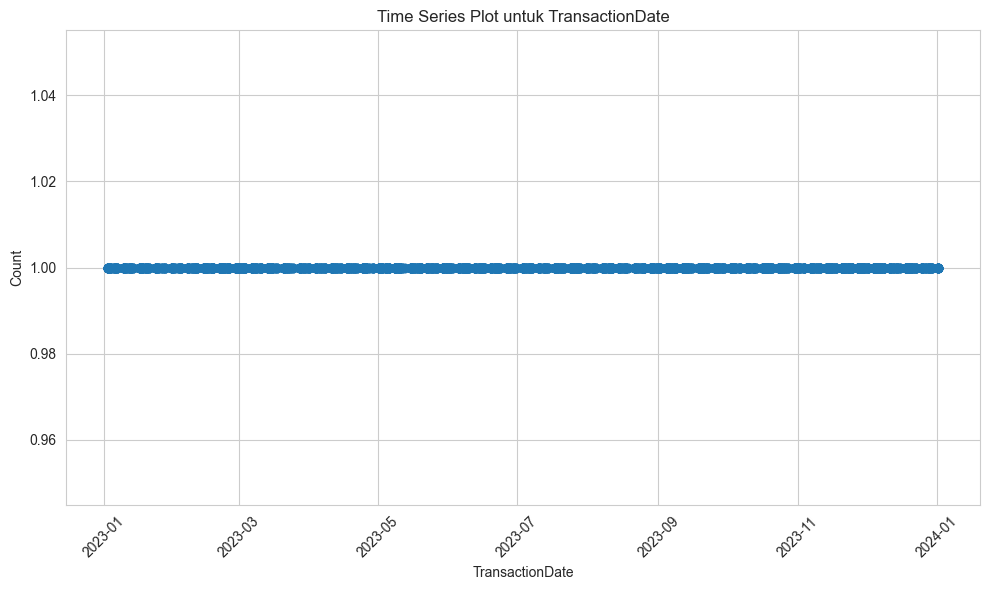

C:\Users\KillerKing\AppData\Local\Temp\ipykernel_17692\3919695841.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='viridis')


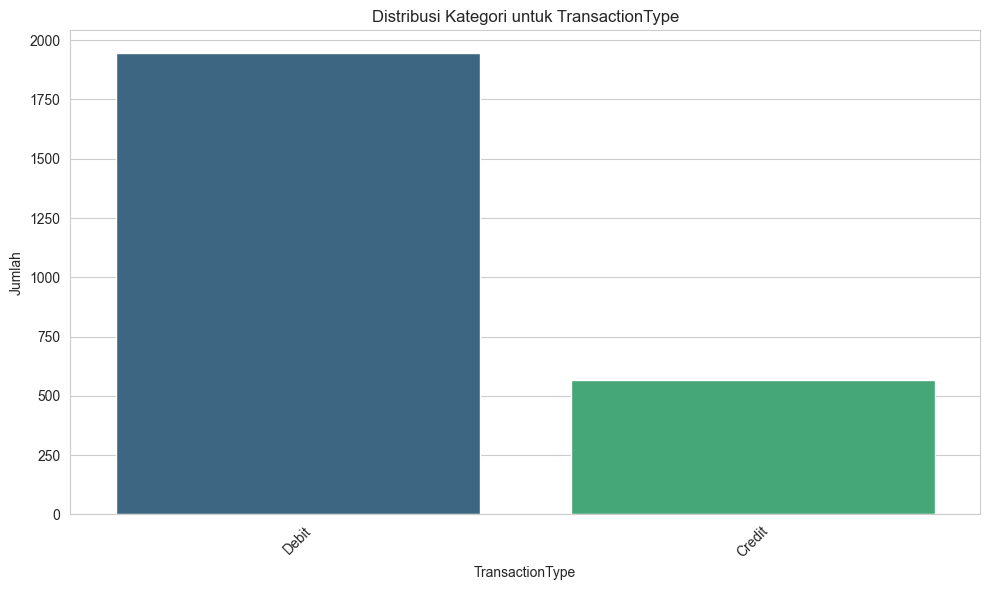

C:\Users\KillerKing\AppData\Local\Temp\ipykernel_17692\3919695841.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='viridis')


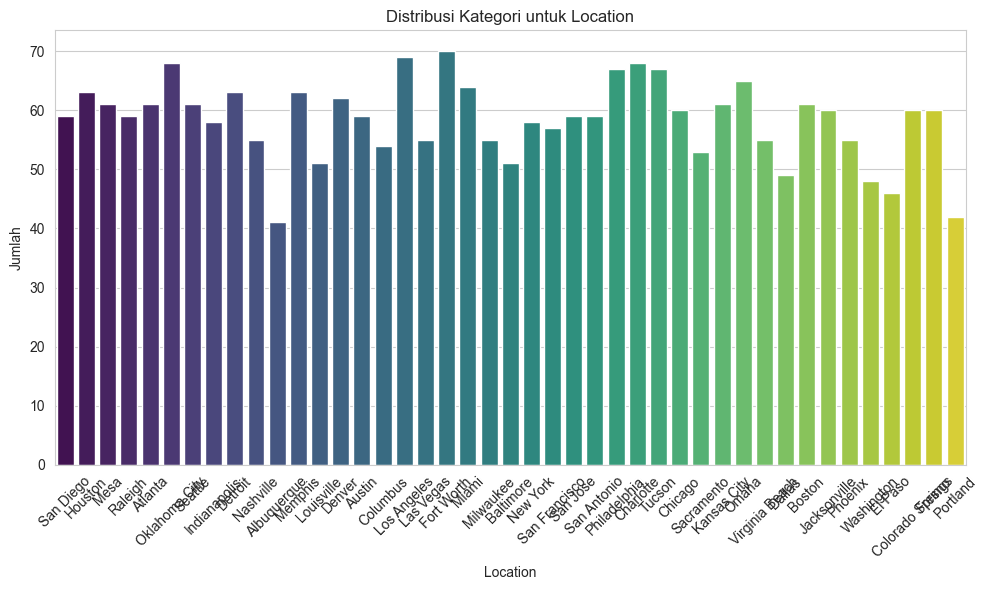

C:\Users\KillerKing\AppData\Local\Temp\ipykernel_17692\3919695841.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='viridis')


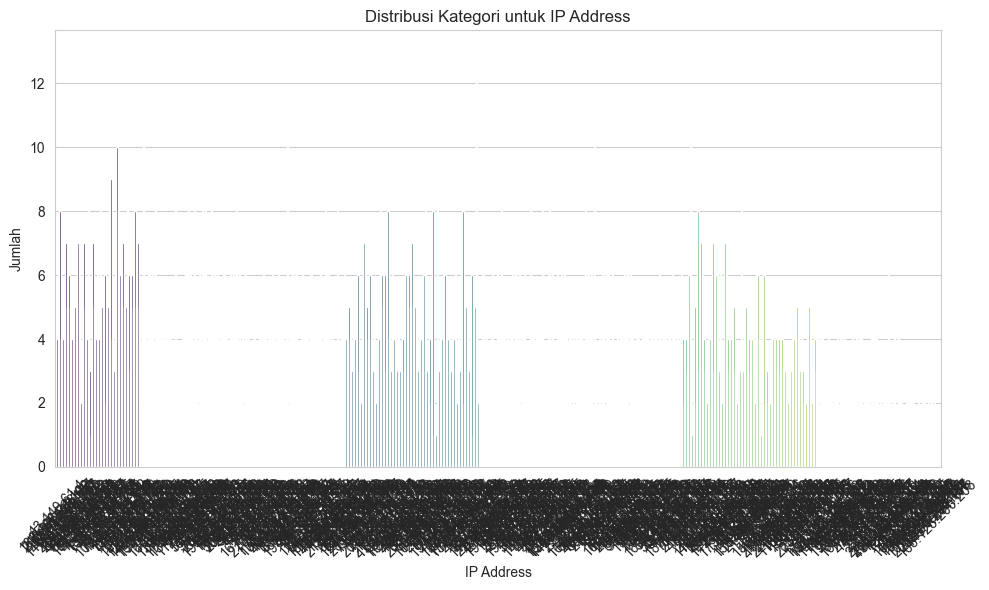

C:\Users\KillerKing\AppData\Local\Temp\ipykernel_17692\3919695841.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='viridis')


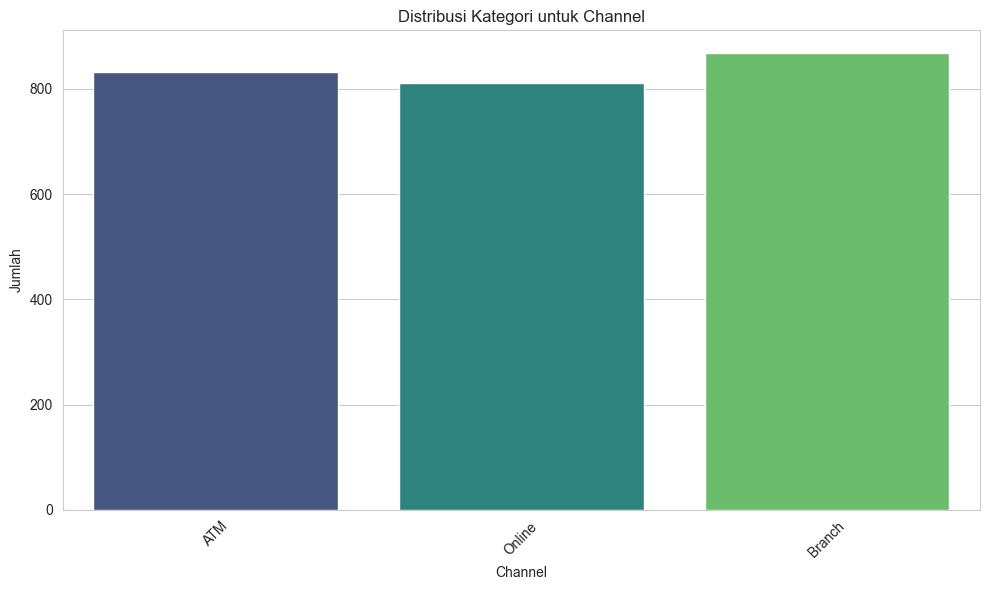

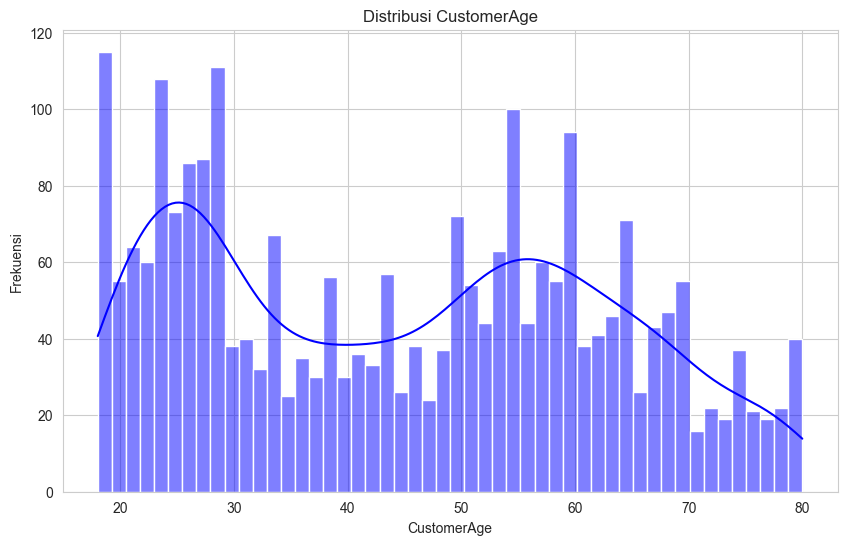

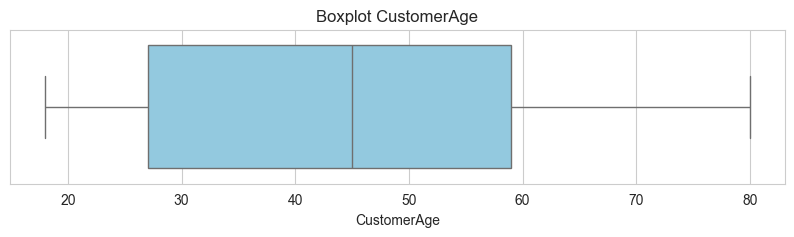

C:\Users\KillerKing\AppData\Local\Temp\ipykernel_17692\3919695841.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette='viridis')


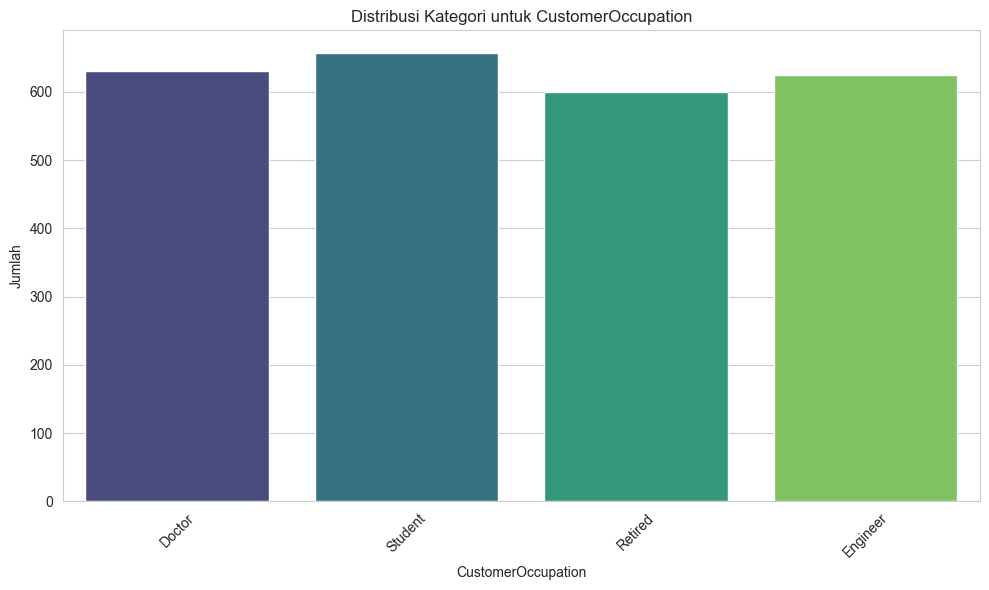

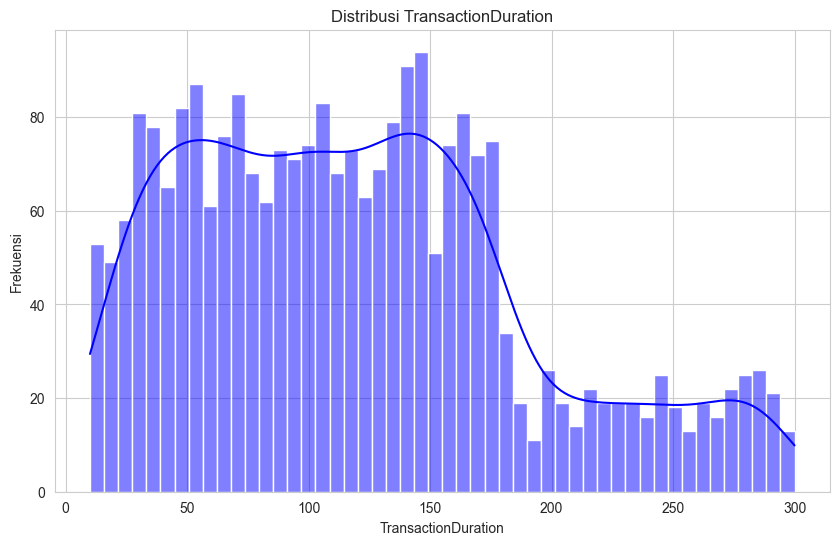

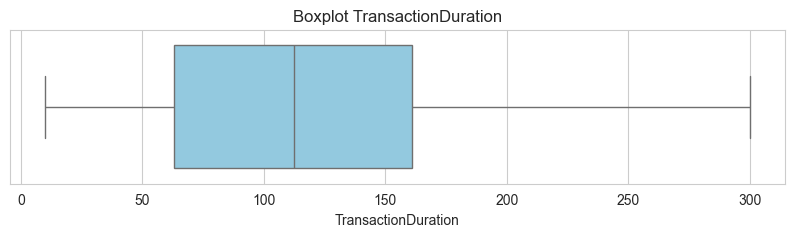

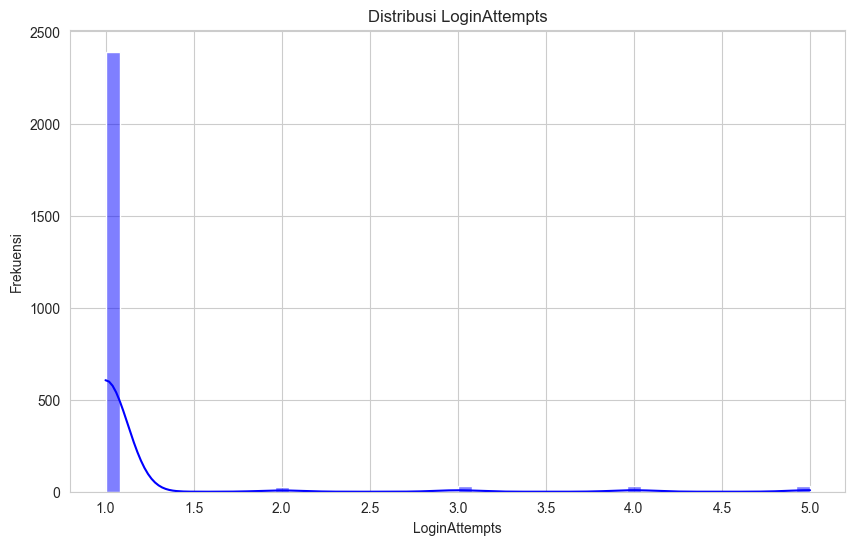

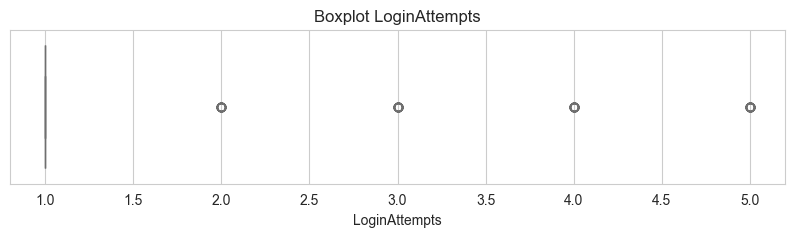

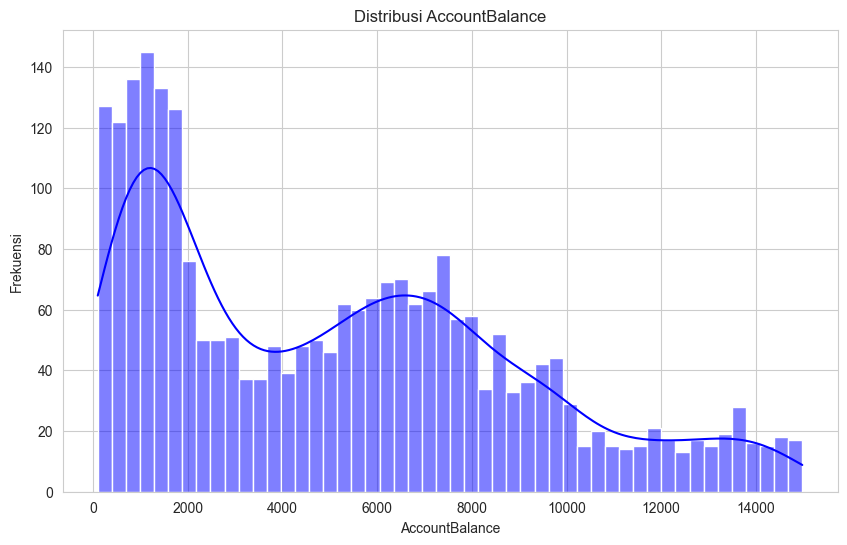

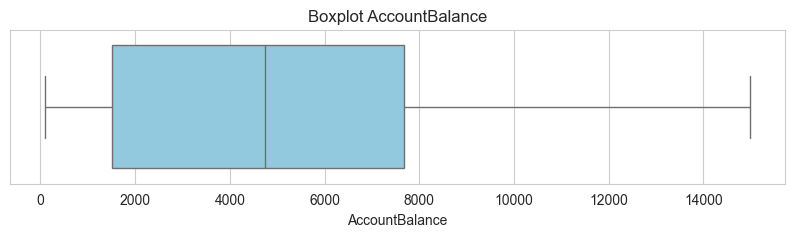

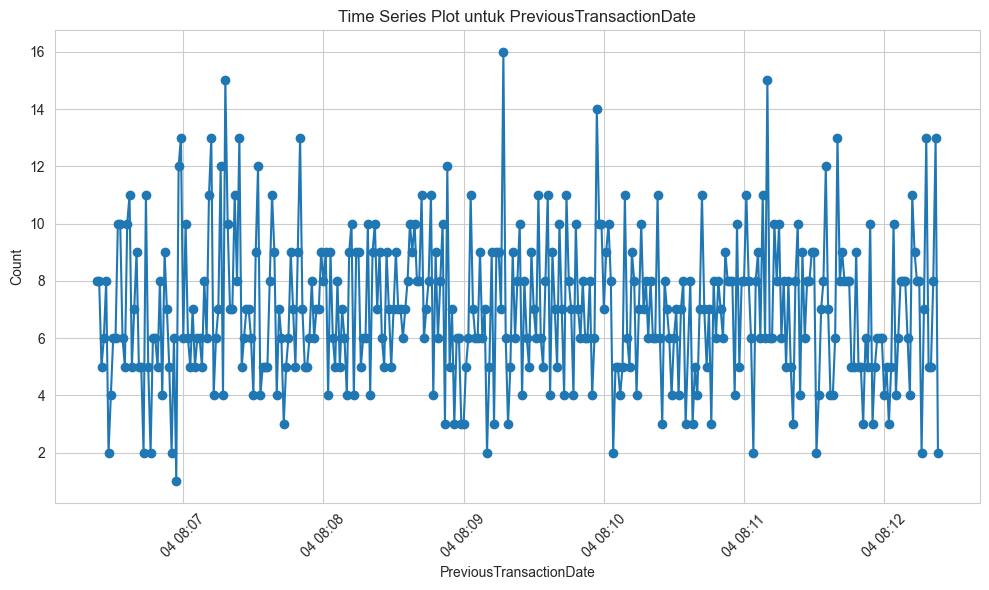

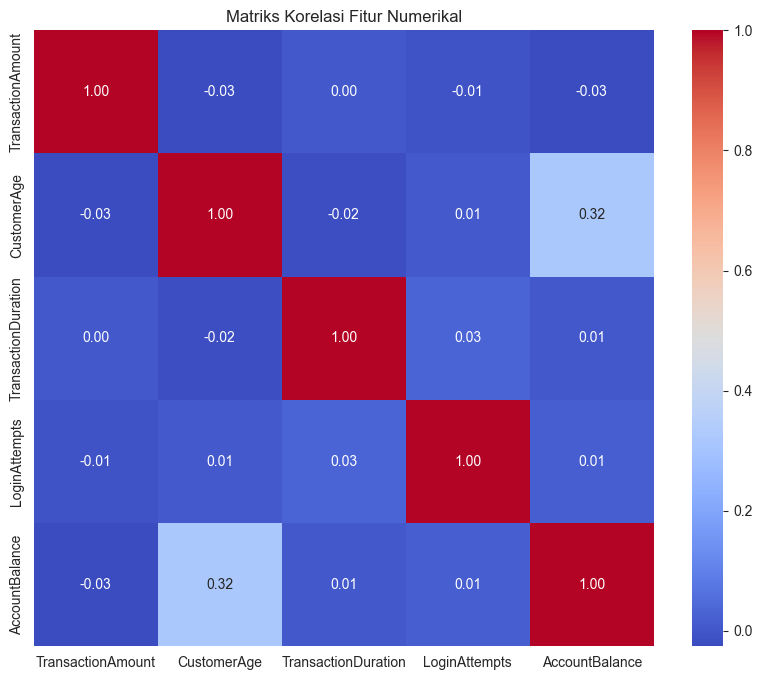

In [18]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================
# 4.1 Statistik Deskriptif
print("Statistik Deskriptif untuk Kolom Numerikal:")
print(data.describe())
print("\nStatistik Deskriptif untuk Kolom Kategorikal:")
print(data.describe(include=['object']))

# 4.2 Pemeriksaan Missing Values
print("\nJumlah Missing Values per Kolom:")
print(data.isnull().sum())

# 4.3 Visualisasi Setiap Kolom (kecuali kolom berakhiran 'id')
for col in data.columns:
    if col.lower().endswith('id'):
        continue

    # Jika kolom merupakan tanggal (dengan mendeteksi 'date' atau tipe datetime)
    if ('date' in col.lower()) or pd.api.types.is_datetime64_any_dtype(data[col]):
        if not pd.api.types.is_datetime64_any_dtype(data[col]):
            data[col] = pd.to_datetime(data[col], errors='coerce')
        timeseries = data.groupby(col).size().reset_index(name='Count')
        plt.figure(figsize=(10, 6))
        plt.plot(timeseries[col], timeseries['Count'], marker='o', linestyle='-')
        plt.title(f'Time Series Plot untuk {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    elif data[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(10, 6))
        sns.histplot(data[col], bins=50, kde=True, color='blue')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
        plt.ylabel('Frekuensi')
        plt.show()
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=data[col], color='skyblue')
        plt.title(f'Boxplot {col}')
        plt.xlabel(col)
        plt.show()
    else:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=col, data=data, palette='viridis')
        plt.title(f'Distribusi Kategori untuk {col}')
        plt.xlabel(col)
        plt.ylabel('Jumlah')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# 4.4 Visualisasi Korelasi Antar Fitur Numerikal
numeric_cols = data.select_dtypes(include=np.number).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriks Korelasi Fitur Numerikal')
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

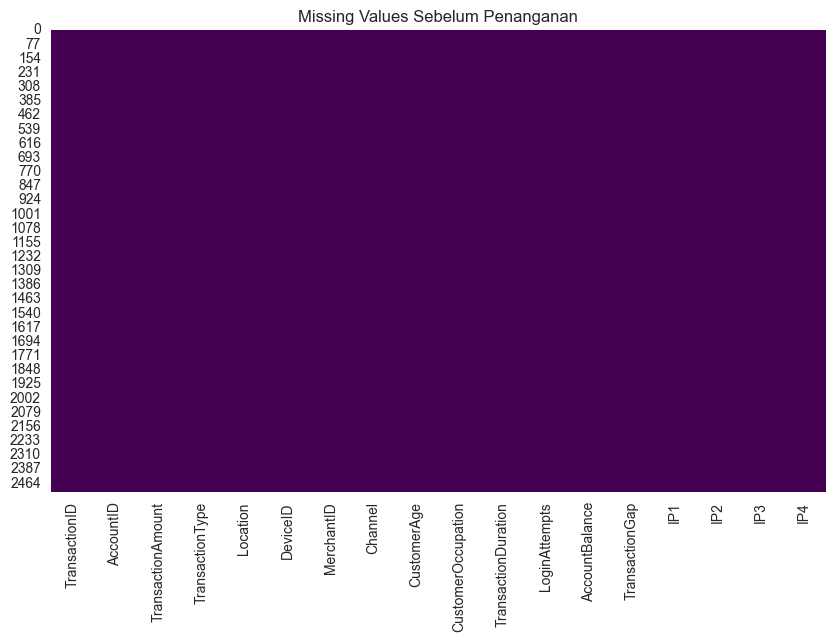

Jumlah data kosong sebelum penanganan:
TransactionID          0
AccountID              0
TransactionAmount      0
TransactionType        0
Location               0
DeviceID               0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
TransactionGap         0
IP1                    0
IP2                    0
IP3                    0
IP4                    0
dtype: int64


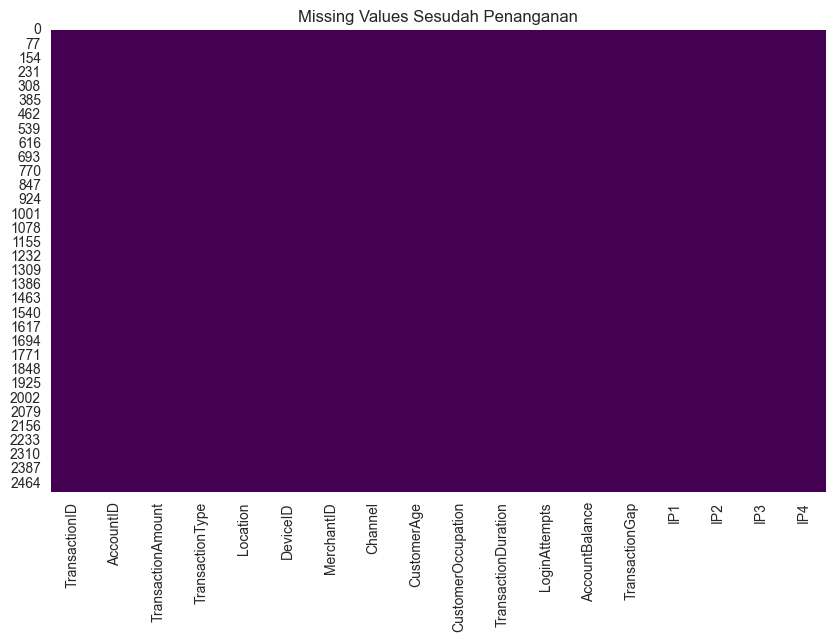


Jumlah data kosong setelah penanganan:
TransactionID          0
AccountID              0
TransactionAmount      0
TransactionType        0
Location               0
DeviceID               0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
TransactionGap         0
IP1                    0
IP2                    0
IP3                    0
IP4                    0
dtype: int64


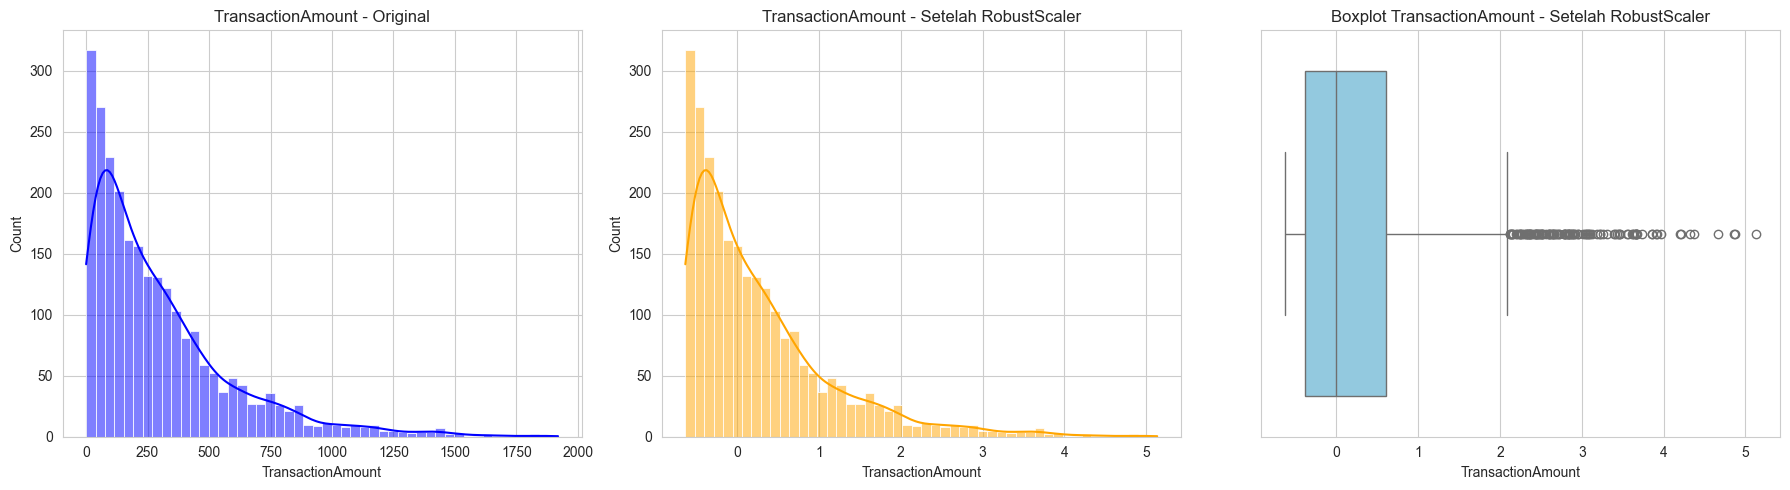

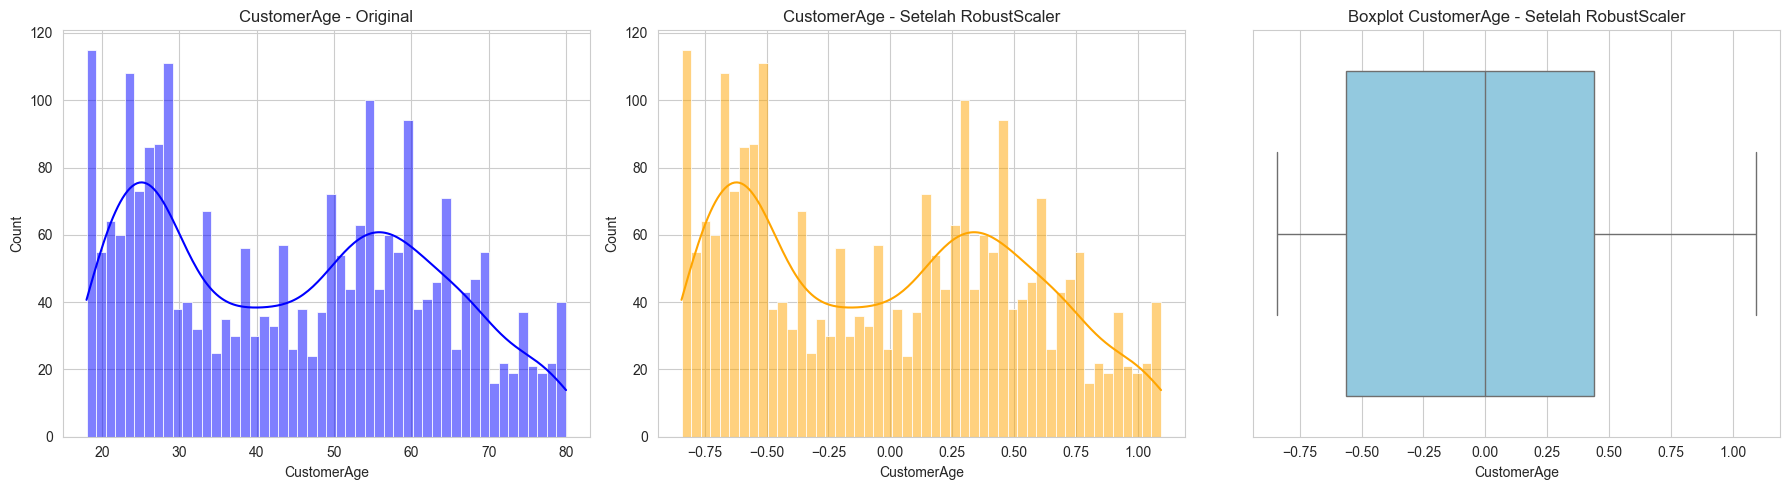

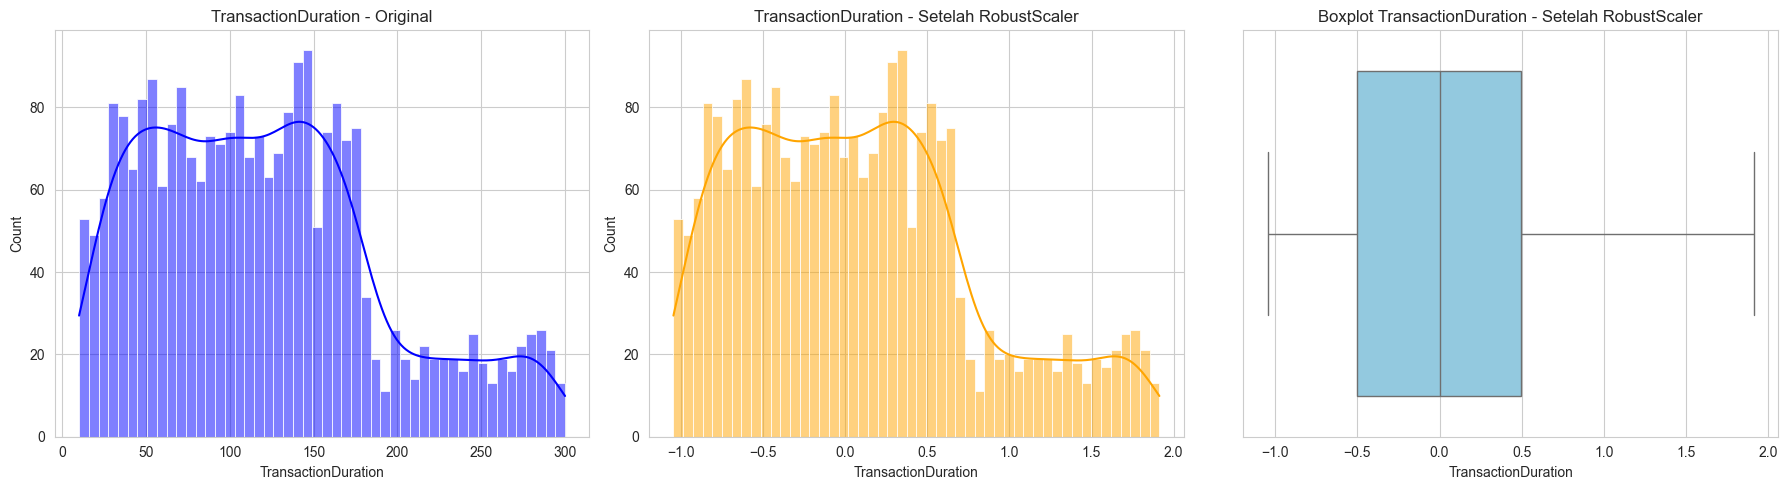

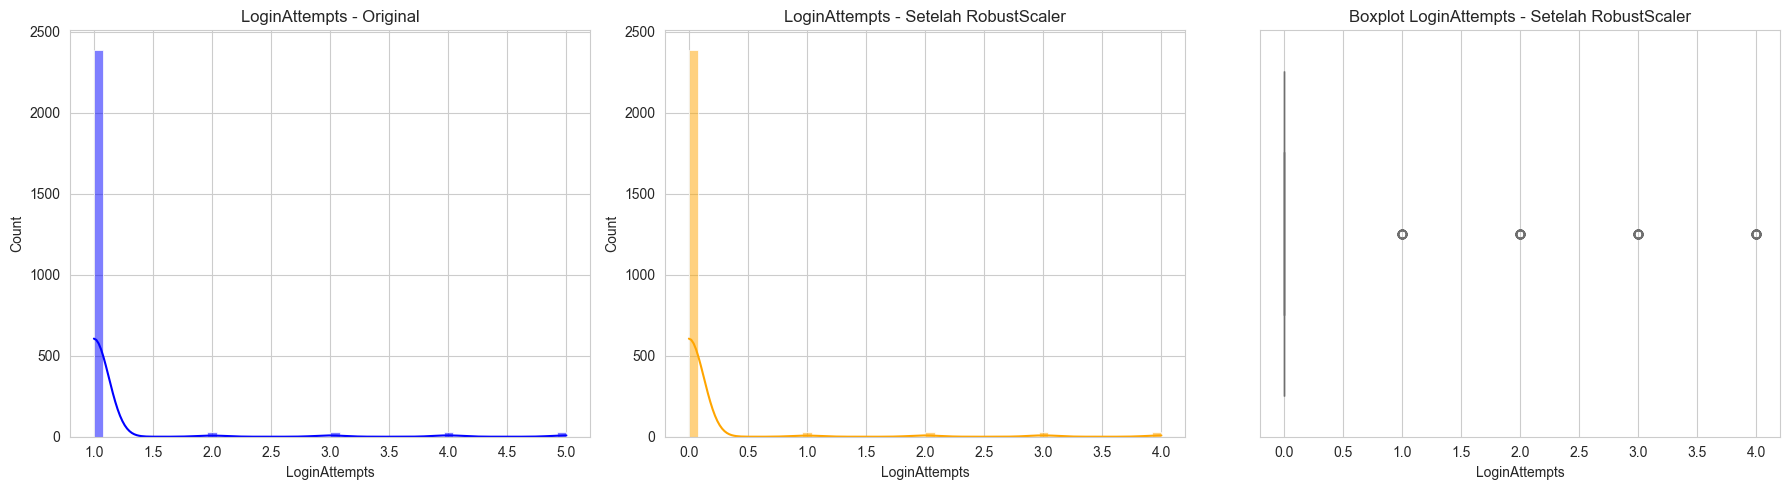

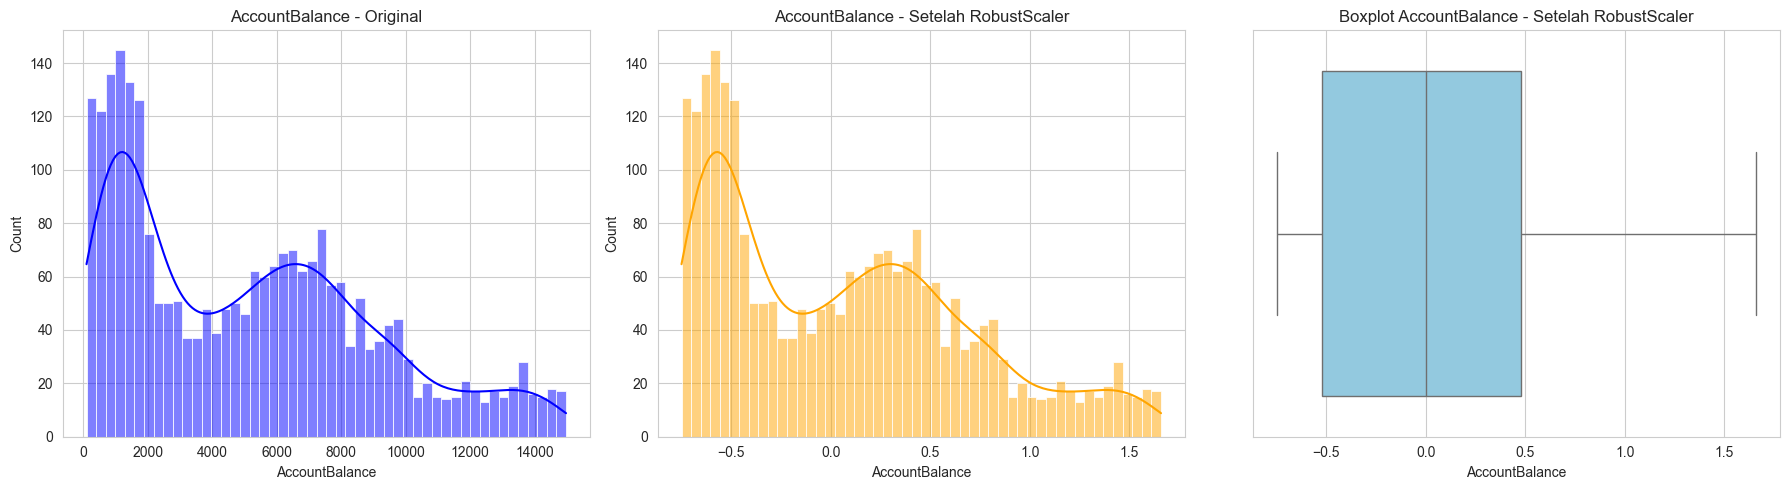

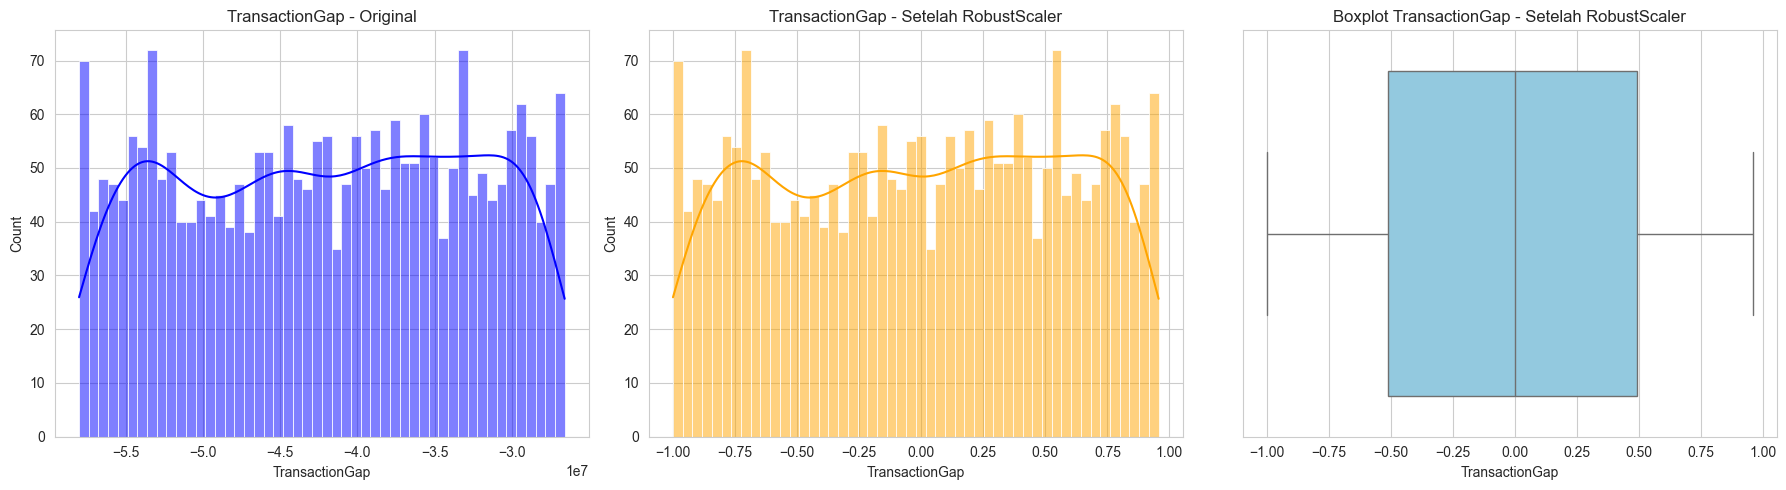

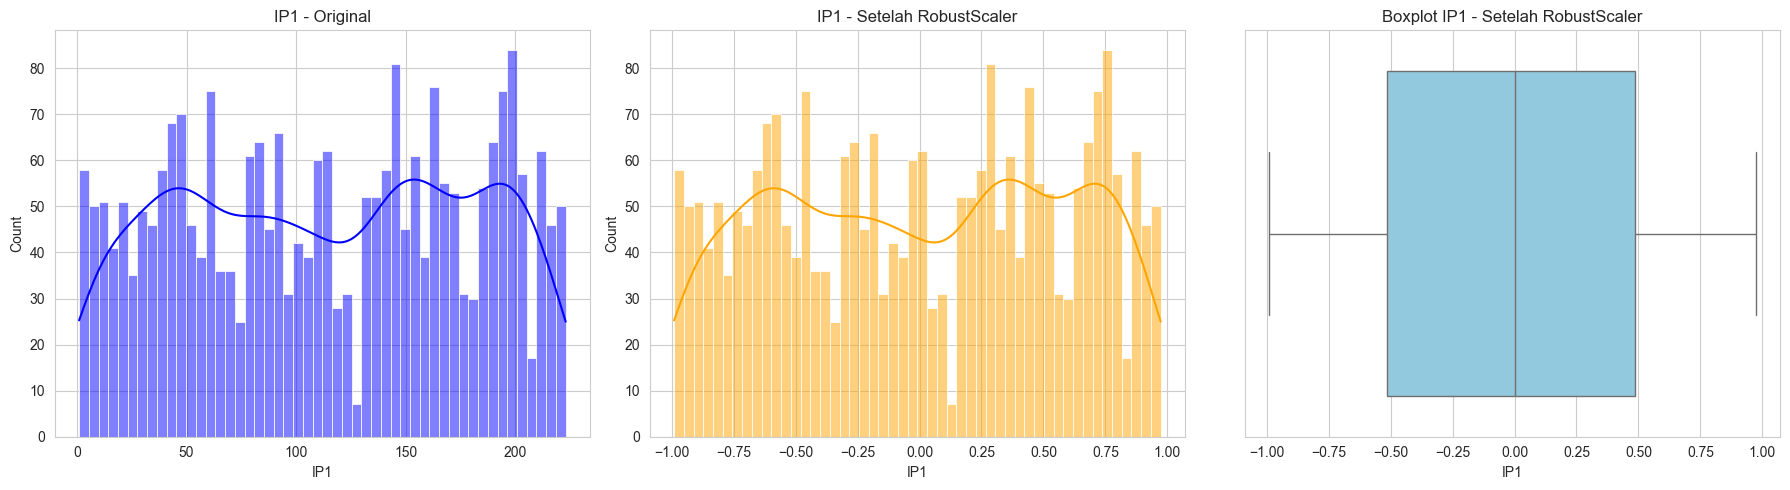

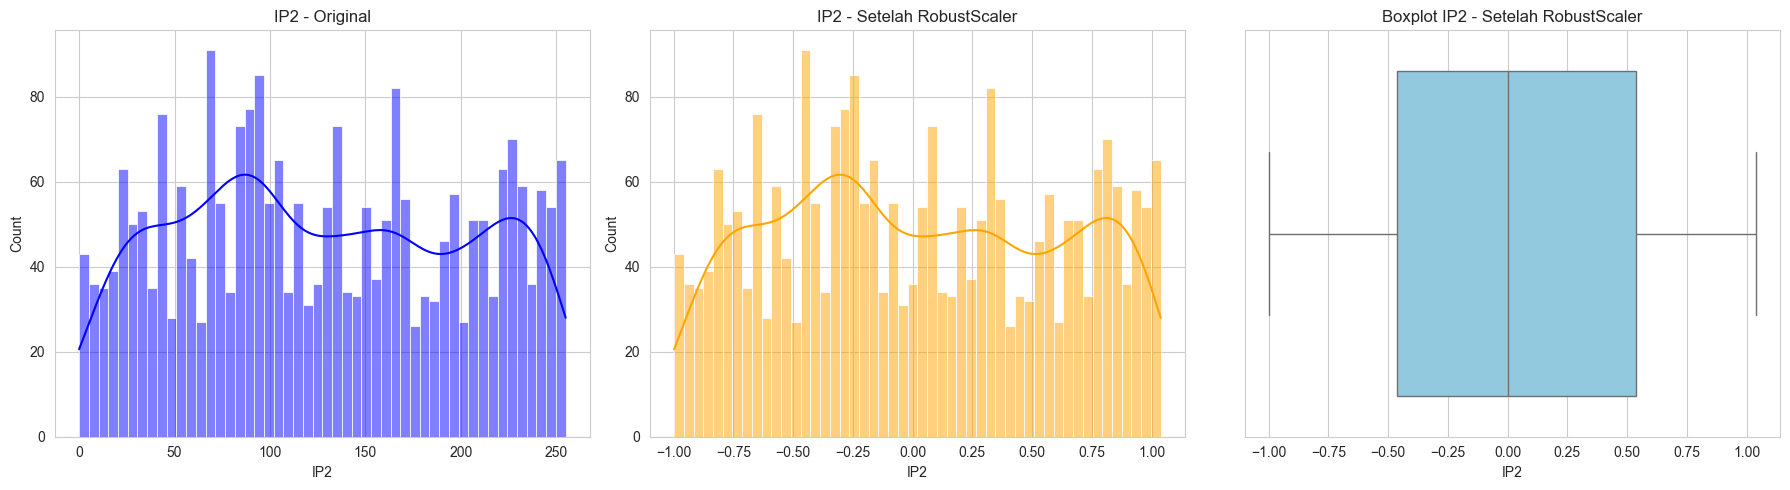

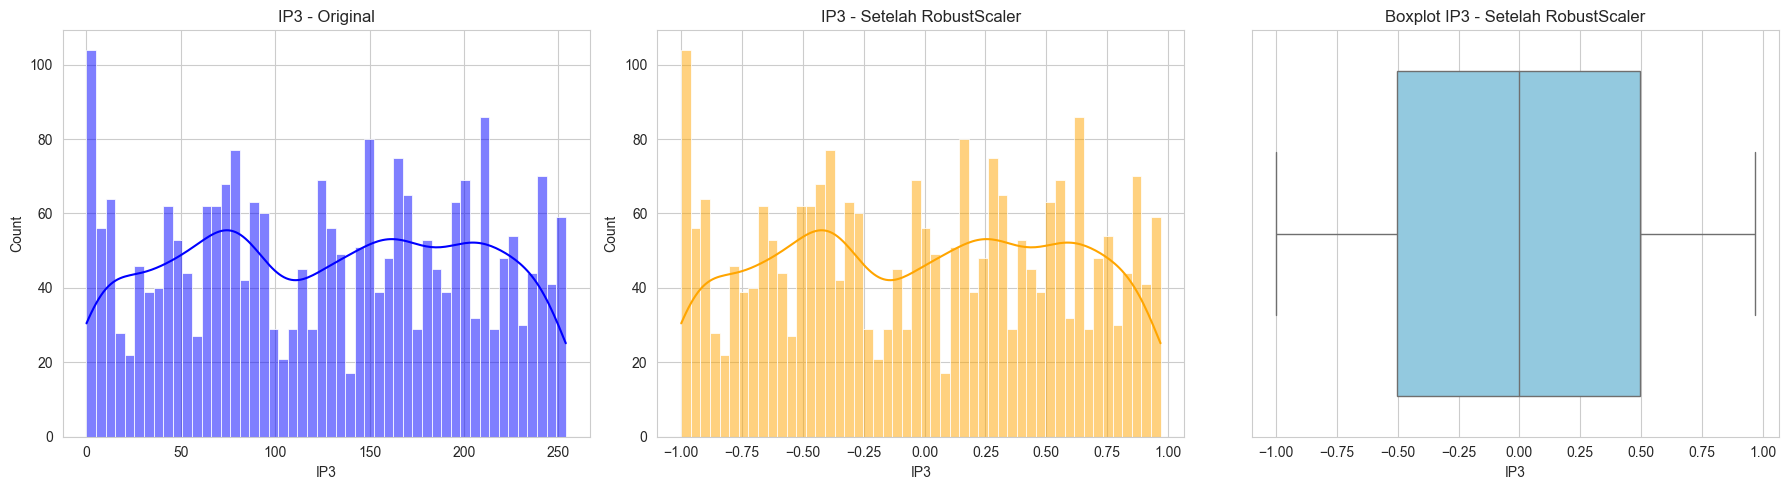

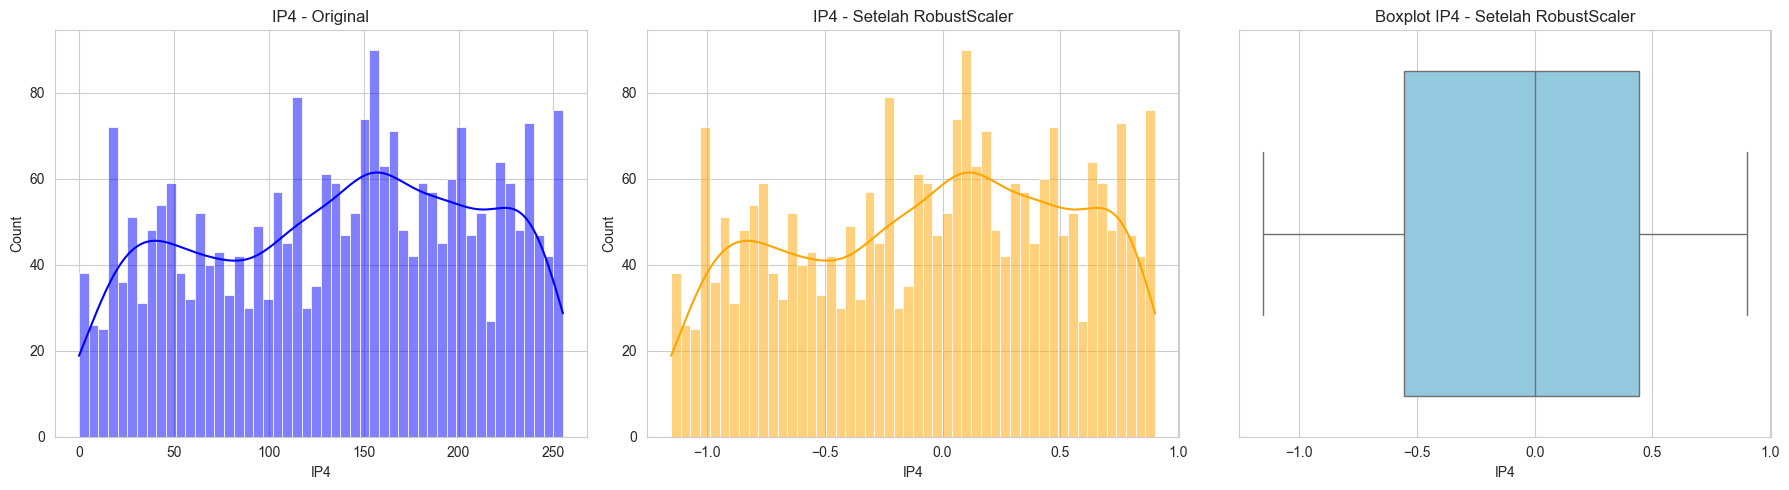


Contoh data pre-improve:
   TransactionID  AccountID  TransactionAmount   Location  DeviceID  \
0              0        126          -0.592378  San Diego       365   
1              1        450           0.496329    Houston        50   
2              2         18          -0.255079       Mesa       229   
3              3         68          -0.080086    Raleigh       182   
4              4        406          -0.594302    Atlanta       298   

   MerchantID Channel  CustomerAge CustomerOccupation  TransactionDuration  \
0          14     ATM      0.78125             Doctor            -0.321429   
1          51     ATM      0.71875             Doctor             0.290816   
2           8  Online     -0.81250            Student            -0.576531   
3           1  Online     -0.59375            Student            -0.892857   
4          90  Online     -0.59375            Student             0.872449   

   LoginAttempts  AccountBalance  TransactionGap       IP1       IP2  \
0     

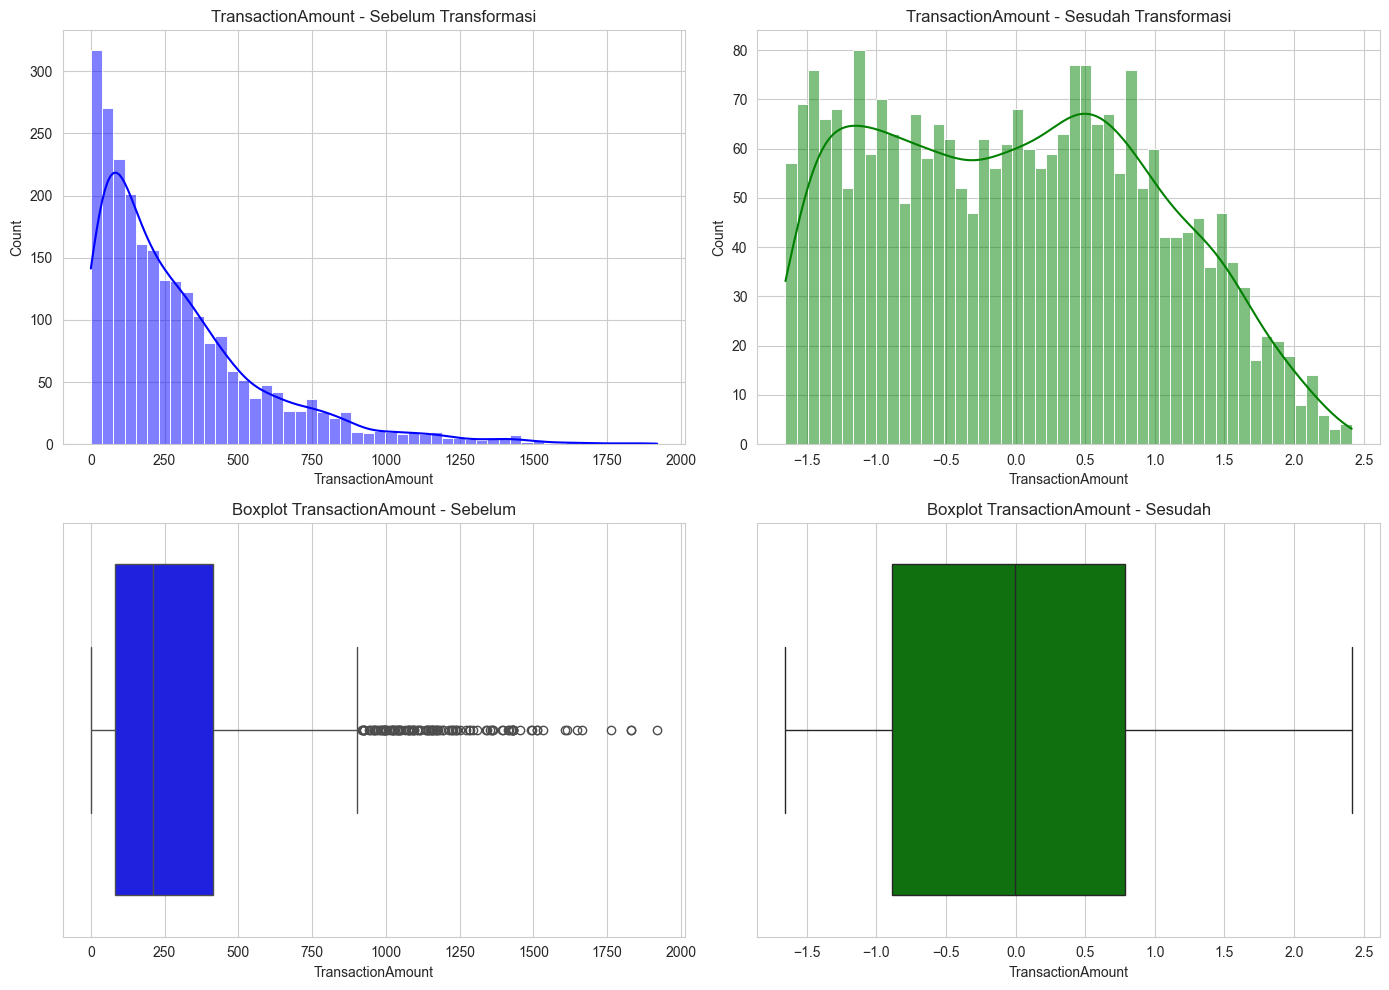

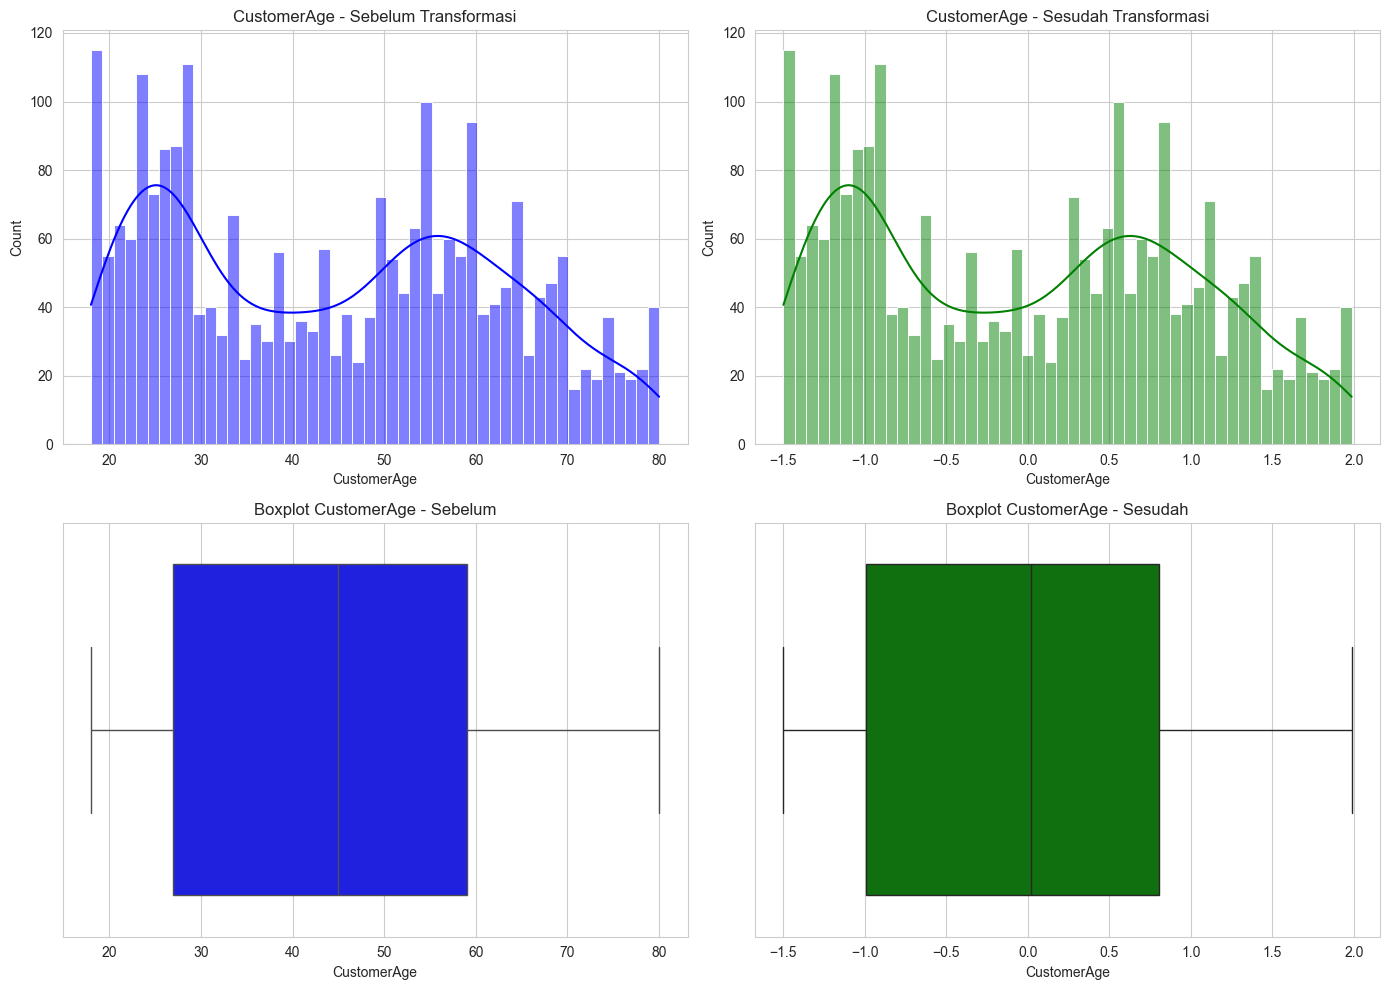

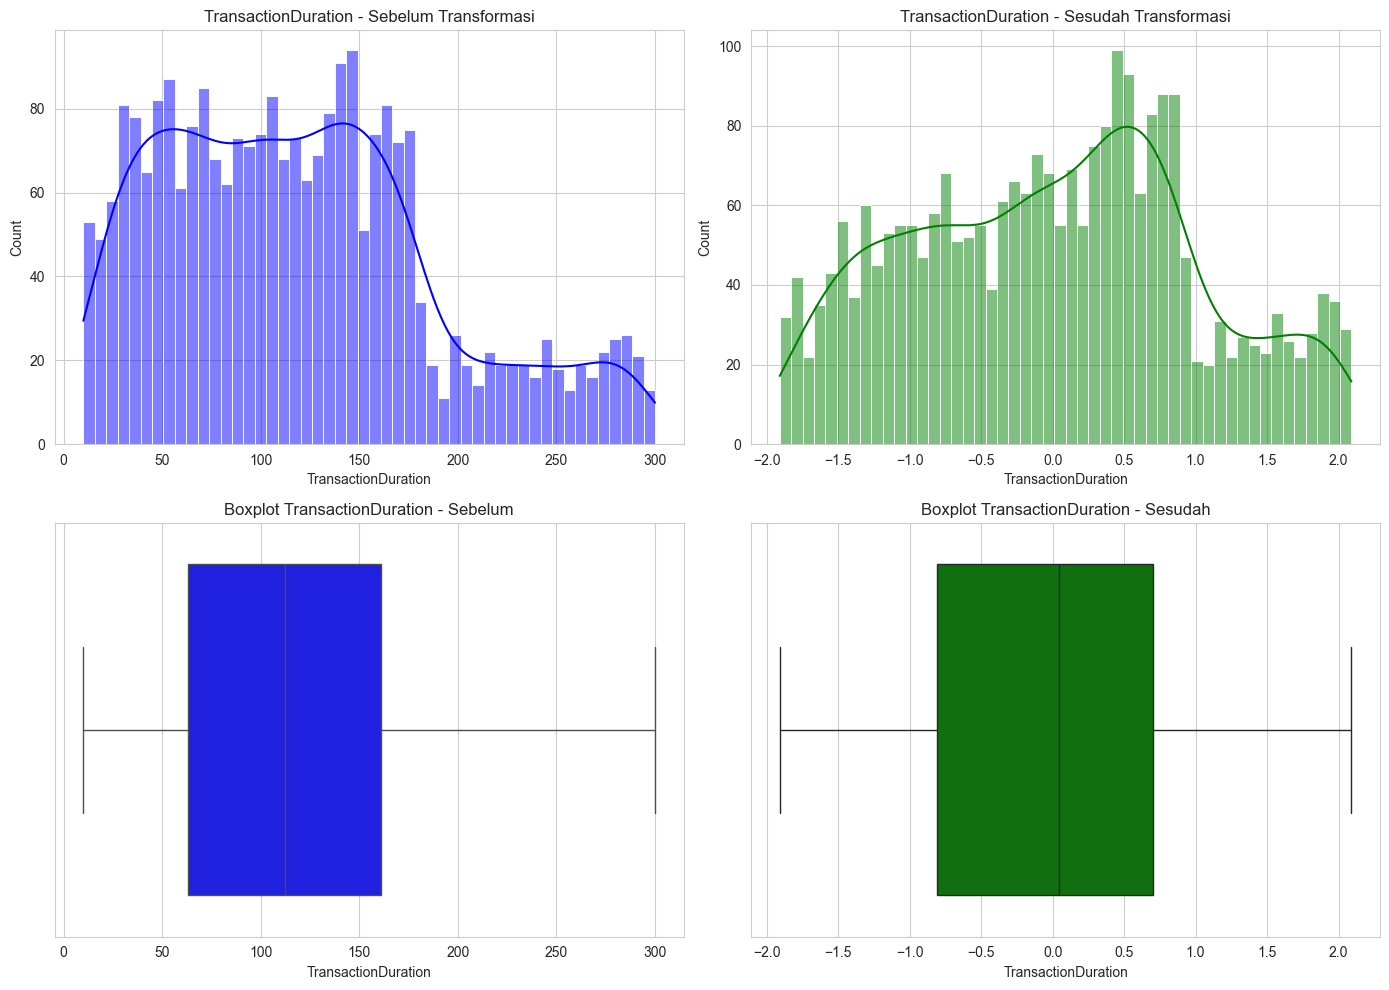

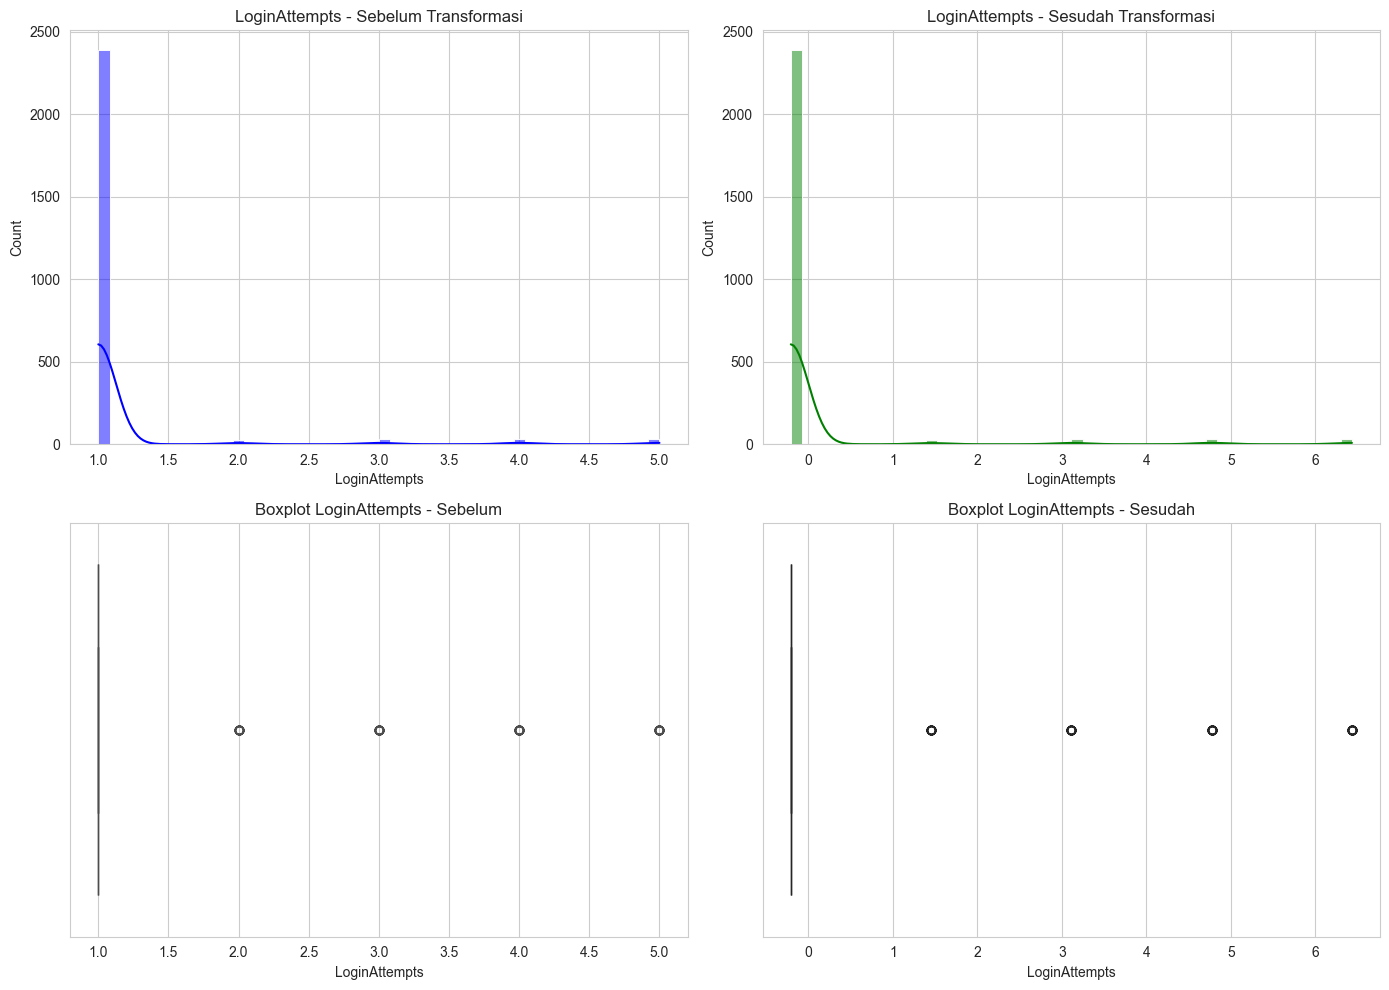

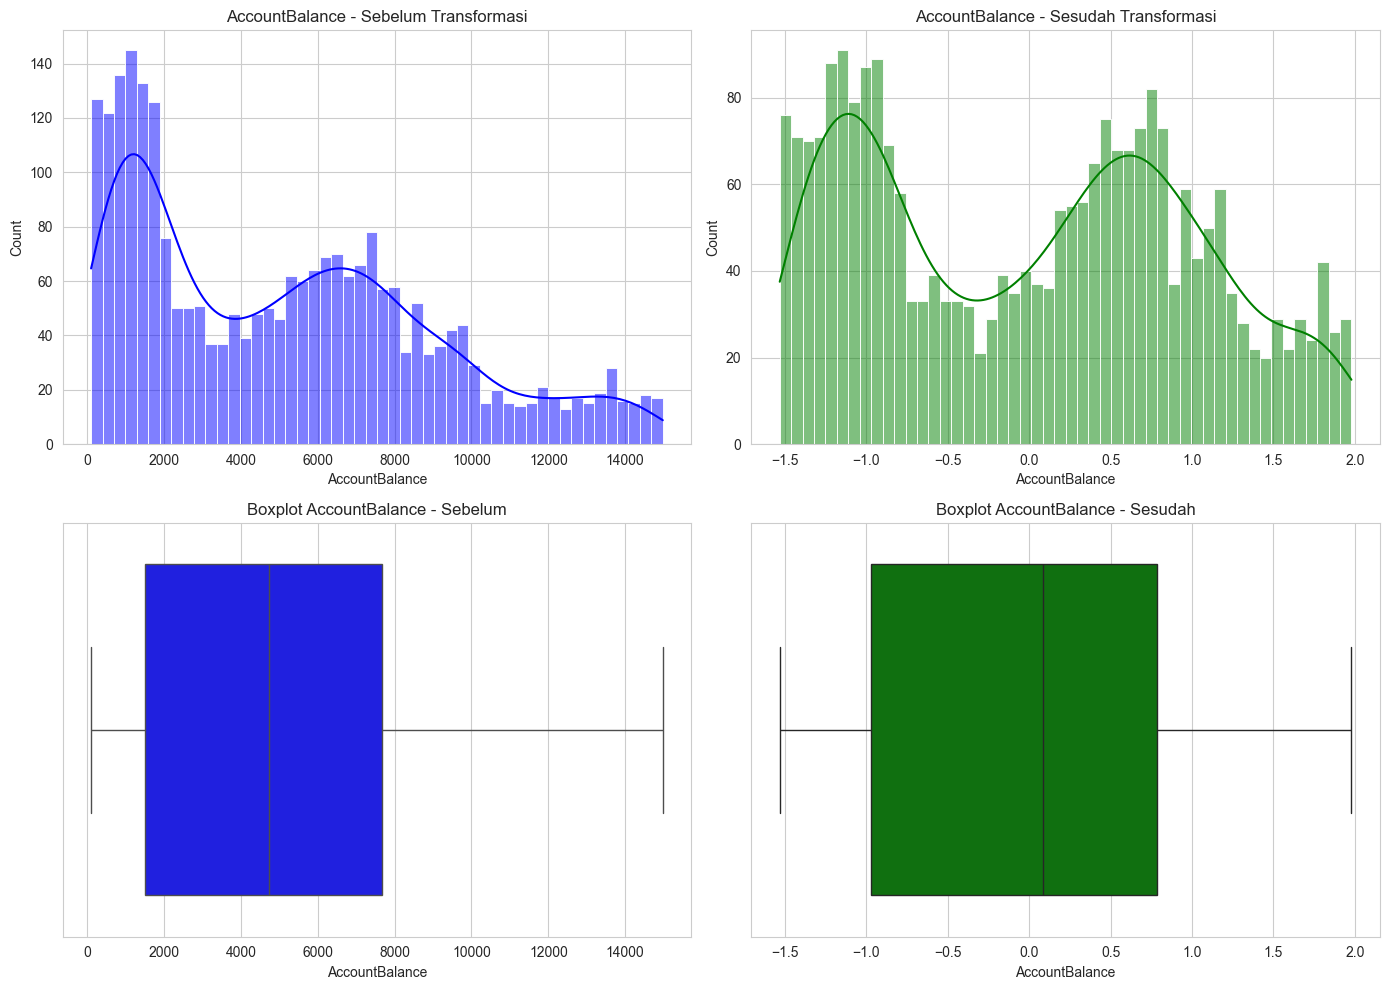

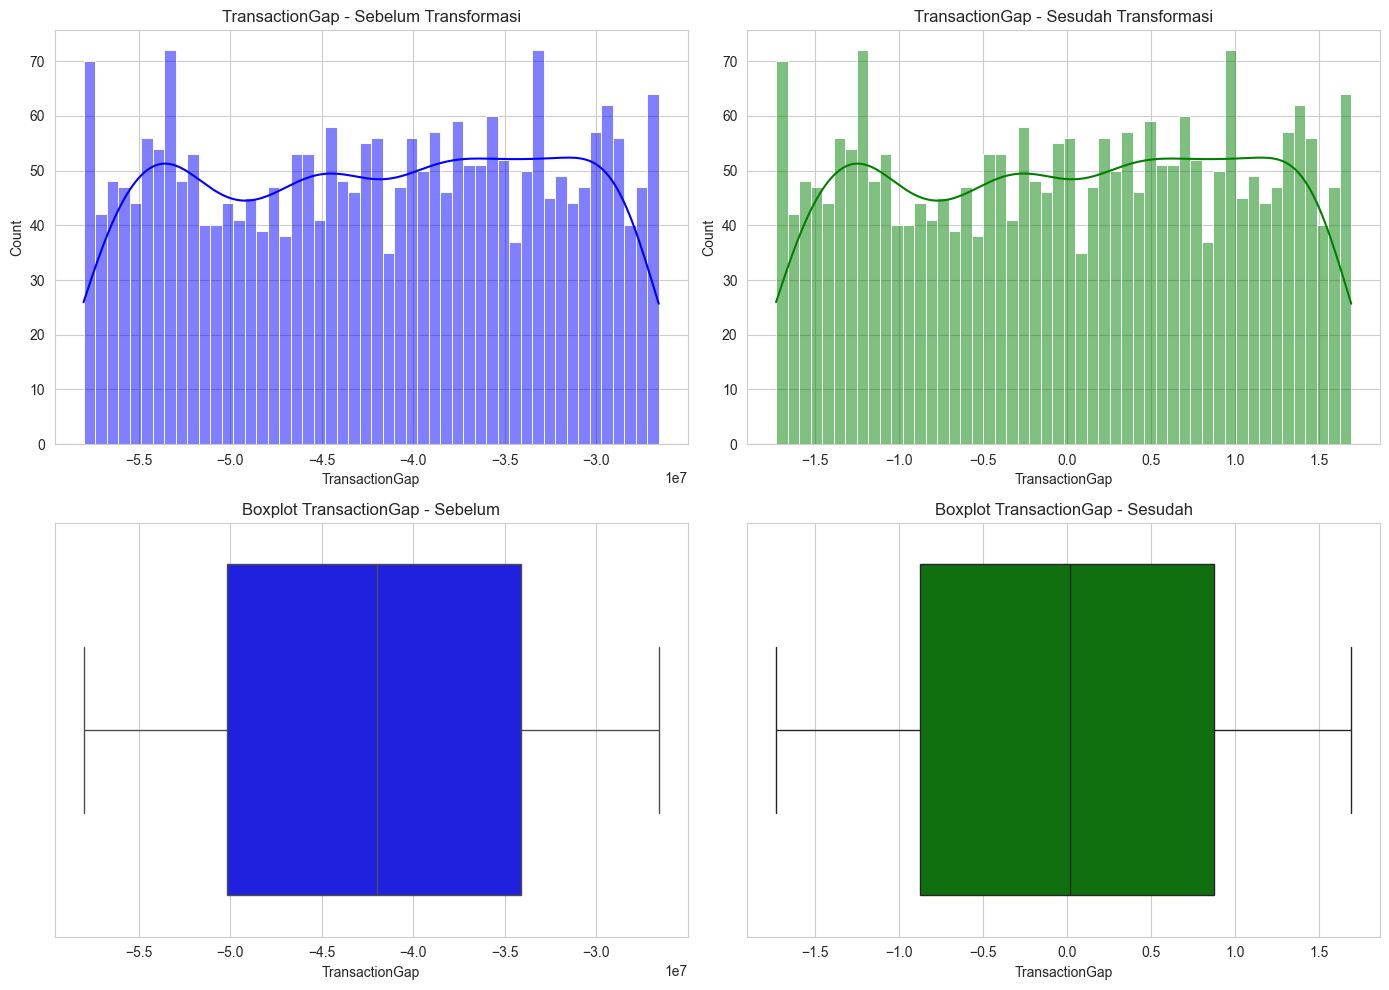

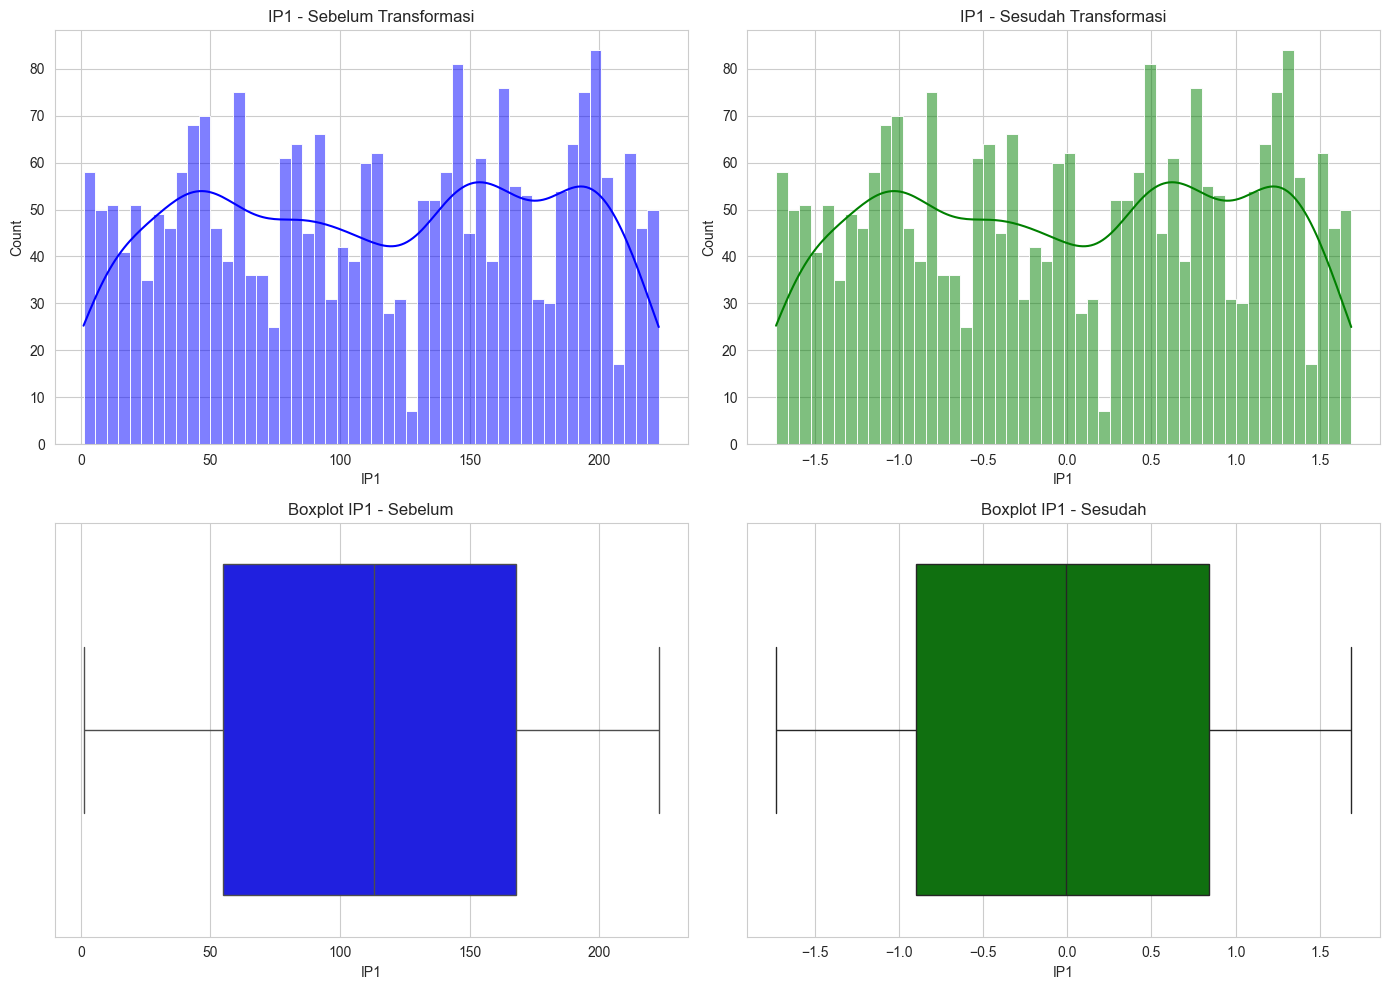

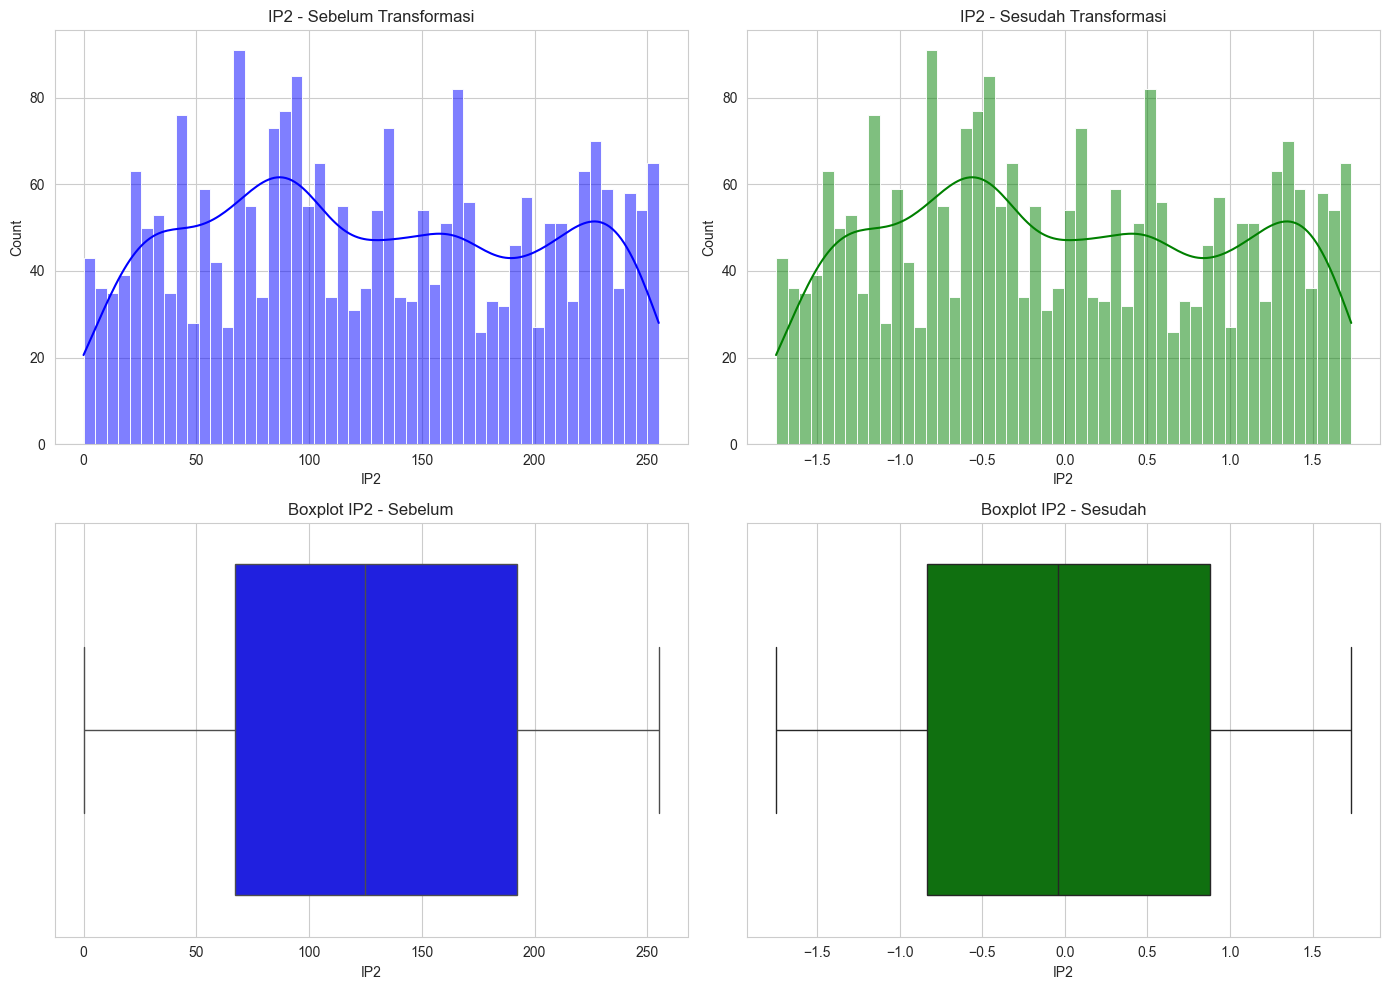

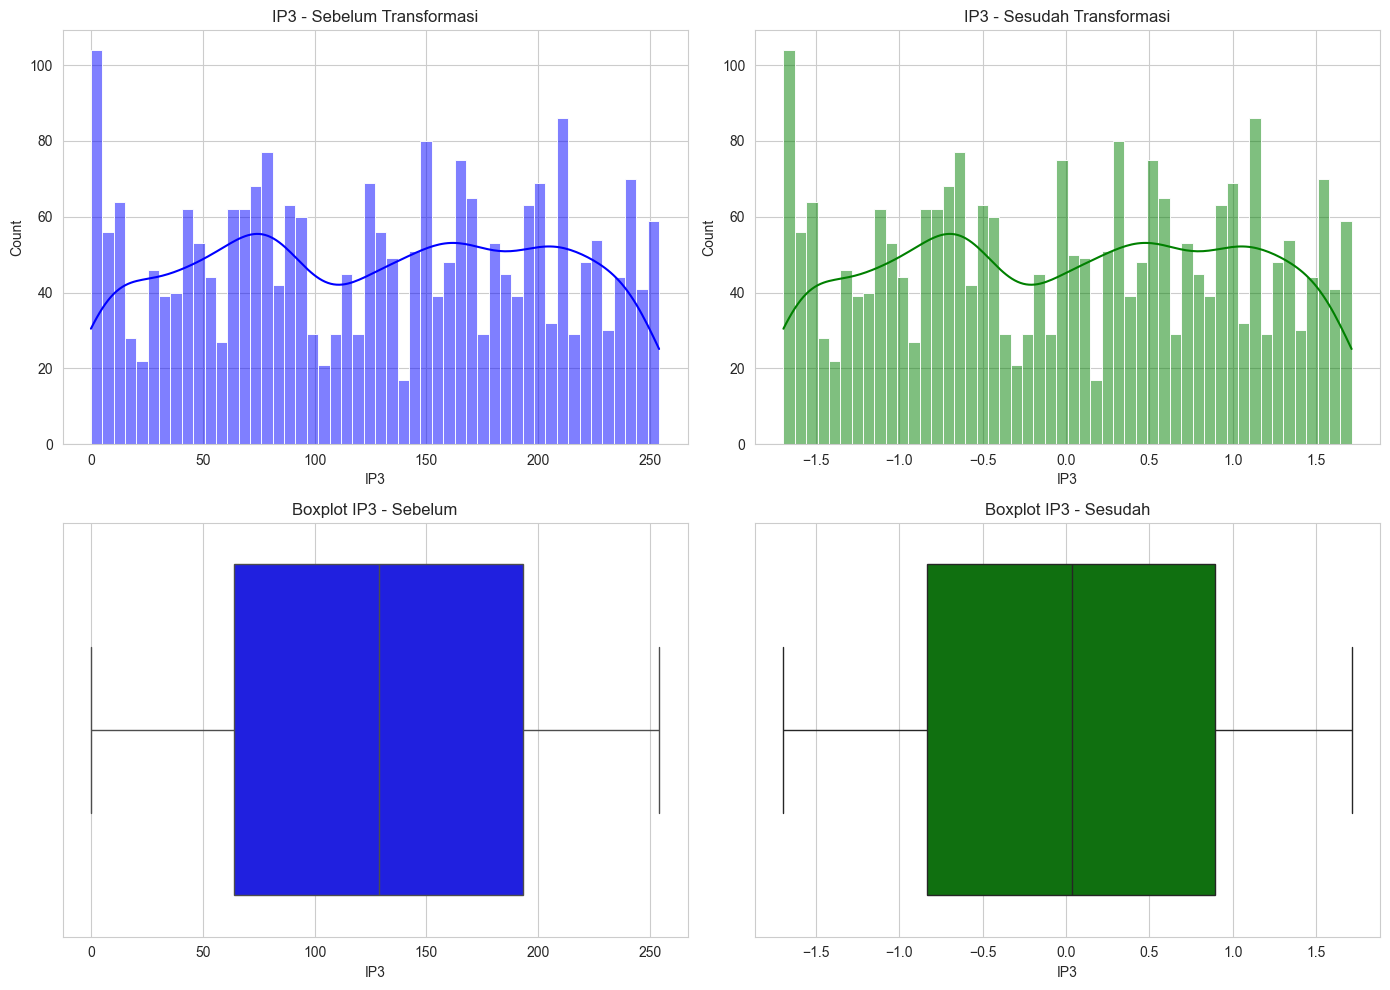

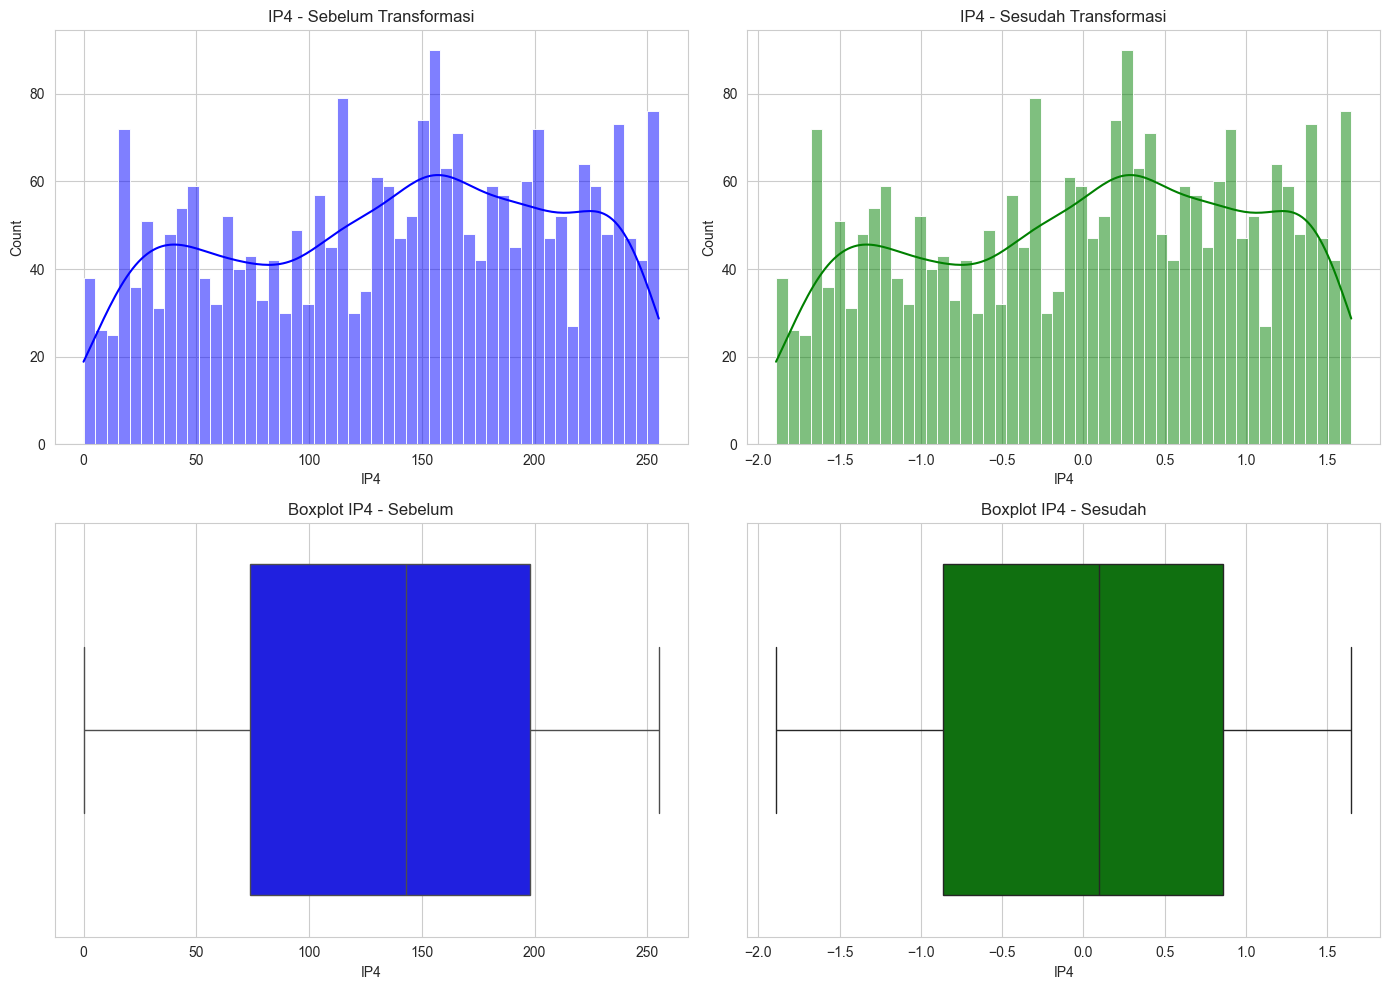


Statistik kolom numerikal setelah perbaikan:
       TransactionAmount   CustomerAge  TransactionDuration  LoginAttempts  \
count       2.512000e+03  2.512000e+03         2.512000e+03   2.512000e+03   
mean        8.485781e-18  9.900078e-18         1.697156e-17   5.657187e-18   
std         1.000199e+00  1.000199e+00         1.000199e+00   1.000199e+00   
min        -1.652432e+00 -1.499493e+00        -1.907702e+00  -2.067936e-01   
25%        -8.865310e-01 -9.935526e-01        -8.058973e-01  -2.067936e-01   
50%        -1.415230e-03  1.832826e-02         4.333207e-02  -2.067936e-01   
75%         7.863050e-01  8.053467e-01         6.996107e-01  -2.067936e-01   
max         2.413389e+00  1.985874e+00         2.089497e+00   6.431745e+00   

       AccountBalance  TransactionGap           IP1           IP2  \
count    2.512000e+03    2.512000e+03  2.512000e+03  2.512000e+03   
mean     1.591084e-18   -4.702537e-17  4.242891e-17  1.202152e-17   
std      1.000199e+00    1.000199e+00  1.000

In [19]:
# Simpan data original sebelum preprocessing
data_truly_original = data.copy()

# Inisialisasi dictionary untuk menyimpan informasi transformasi
transformation_info = {}

# --- 5.1 PREPROCESSING AWAL ---
# Konversi kolom tanggal dan hitung TransactionGap, lalu hapus kolom asli
if 'TransactionDate' in data.columns and 'PreviousTransactionDate' in data.columns:
    data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], errors='coerce')
    data['PreviousTransactionDate'] = pd.to_datetime(data['PreviousTransactionDate'], errors='coerce')
    data['TransactionGap'] = (data['TransactionDate'] - data['PreviousTransactionDate']).dt.total_seconds()
    data.drop(['TransactionDate', 'PreviousTransactionDate'], axis=1, inplace=True)

date_cols = [col for col in data.columns if 'date' in col.lower()]
for col in date_cols:
    transformation_info[col] = {'original_type': data[col].dtype}
    data[col] = pd.to_datetime(data[col], errors='coerce')
    data[f'{col}_year'] = data[col].dt.year
    transformation_info[f'{col}_year'] = {'transformation': 'datetime_component', 'component': 'year', 'original_column': col}
    data[f'{col}_month'] = data[col].dt.month
    transformation_info[f'{col}_month'] = {'transformation': 'datetime_component', 'component': 'month', 'original_column': col}
    data[f'{col}_day'] = data[col].dt.day
    transformation_info[f'{col}_day'] = {'transformation': 'datetime_component', 'component': 'day', 'original_column': col}
    data[f'{col}_hour'] = data[col].dt.hour
    transformation_info[f'{col}_hour'] = {'transformation': 'datetime_component', 'component': 'hour', 'original_column': col}
    data[f'{col}_minute'] = data[col].dt.minute
    transformation_info[f'{col}_minute'] = {'transformation': 'datetime_component', 'component': 'minute', 'original_column': col}
    data[f'{col}_second'] = data[col].dt.second
    transformation_info[f'{col}_second'] = {'transformation': 'datetime_component', 'component': 'second', 'original_column': col}
    data.drop(col, axis=1, inplace=True)

# Penanganan kolom IP Address: pisahkan menjadi empat kolom numerikal
if 'IP Address' in data.columns:
    transformation_info['IP Address'] = {'original_type': data['IP Address'].dtype}
    ip_split = data['IP Address'].str.split('.', expand=True)
    ip_split.columns = ['IP1', 'IP2', 'IP3', 'IP4']
    for col in ip_split.columns:
        ip_split[col] = pd.to_numeric(ip_split[col], errors='coerce')
        transformation_info[col] = {'transformation': 'ip_split', 'original_column': 'IP Address', 'missing_value_handling': 'median'} # Ensure missing value handling is recorded
    data.drop('IP Address', axis=1, inplace=True)
    data = pd.concat([data, ip_split], axis=1)

# Simpan data awal untuk referensi
data_original = data.copy()

# Visualisasi Missing Values sebelum penanganan
plt.figure(figsize=(10, 6))
sns.heatmap(data_original.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Sebelum Penanganan')
plt.show()
print("Jumlah data kosong sebelum penanganan:")
print(data_original.isnull().sum())

# Tangani missing values: untuk kolom objek gunakan mode, untuk numerik gunakan median
for col in data_original.columns:
    transformation_info.setdefault(col, {})['missing_value_handling'] = 'mode' if data_original[col].dtype == 'object' else 'median'
    if data_original[col].dtype == 'object':
        data_original[col] = data_original[col].fillna(data_original[col].mode()[0])
    else:
        data_original[col] = data_original[col].fillna(data_original[col].median())

plt.figure(figsize=(10, 6))
sns.heatmap(data_original.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Sesudah Penanganan')
plt.show()
print("\nJumlah data kosong setelah penanganan:")
print(data_original.isnull().sum())

# One-Hot Encoding untuk kolom TransactionType (jika ada)
if 'TransactionType' in data_original.columns:
    transformation_info['TransactionType'] = {'transformation': 'one_hot_encoding', 'drop_first': True, 'original_type': data_original['TransactionType'].dtype}
    data_before_ohe = data_original.copy()
    data_original = pd.get_dummies(data_original, columns=['TransactionType'], drop_first=True)

# Label Encoding untuk kolom kategorikal (kecuali yang akan diproses secara custom)
cols_to_label = ['Location', 'CustomerOccupation', 'Channel']
label_encoders = {}
categorical_cols = [col for col in data_original.select_dtypes(include=['object']).columns if col not in cols_to_label]
for col in categorical_cols:
    le = LabelEncoder()
    transformation_info[col] = {'transformation': 'label_encoding', 'encoder': le, 'original_type': data_original[col].dtype}
    data_original[col] = le.fit_transform(data_original[col])
    label_encoders[col] = le

# RobustScaler untuk kolom numerik
numeric_cols = data_original.select_dtypes(include=['float64', 'int64']).columns
data_pre_improve = data_original.copy()
scaler = RobustScaler()
data_pre_improve[numeric_cols] = scaler.fit_transform(data_pre_improve[numeric_cols])
transformation_info['RobustScaler'] = {'scaler': scaler, 'columns': numeric_cols.tolist()}

# Visualisasi Distribusi Awal (perbandingan sebelum & sesudah scaling)
for col in numeric_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.histplot(data_original[col], bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f'{col} - Original')
    sns.histplot(data_pre_improve[col], bins=50, kde=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - Setelah RobustScaler')
    sns.boxplot(x=data_pre_improve[col], ax=axes[2], color='skyblue')
    axes[2].set_title(f'Boxplot {col} - Setelah RobustScaler')
    plt.tight_layout()
    plt.show()

print("\nContoh data pre-improve:")
print(data_pre_improve.head())

# --- 5.2 PERBAIKAN DISTRIBUSI & REDUKSI SKEWNESS ---
data_improve = data_pre_improve.copy() # Apply skewness reduction after RobustScaler
data_before_skew = data_original.copy() # Use original data for skewness calculation
cols_keep_outliers = []  # Jika ada kolom yang ingin dipertahankan distribusinya
skewness_transformers = {}
transformation_info['data_before_skew'] = {} # Store min values for log1p and Box-Cox

def transform_series(series, threshold=0.5):
    methods = [
        (lambda s: PowerTransformer(method='yeo-johnson').fit(s.values.reshape(-1,1)), "Yeo-Johnson"),
        (lambda s: (np.log1p(s + abs(s.min()) + 1) if (s < 0).any() else np.log1p(s)), "log1p"),
        (lambda s: QuantileTransformer(output_distribution='normal', random_state=42, n_quantiles=min(100, len(s))).fit(s.values.reshape(-1,1)), "QuantileTransformer"),
        (lambda s: boxcox(s + abs(s.min()) + 1) if (s <= 0).any() else boxcox(s), "Box-Cox")
    ]
    best_method, best_skew, best_transformed, best_transformer = None, np.inf, series.copy(), None
    for func, name in methods:
        try:
            if name == "Yeo-Johnson" or name == "QuantileTransformer":
                transformer = func(series)
                transformed = pd.Series(transformer.transform(series.values.reshape(-1, 1)).flatten(), index=series.index)
                current_skew = transformed.skew()
                if abs(current_skew) < threshold:
                    return transformed, name, transformer
                if abs(current_skew) < abs(best_skew):
                    best_skew = current_skew
                    best_method = name
                    best_transformed = transformed
                    best_transformer = transformer
            elif name == "log1p":
                transformed = pd.Series(func(series), index=series.index)
                current_skew = transformed.skew()
                if abs(current_skew) < threshold:
                    return transformed, name, None # No transformer to store
                if abs(current_skew) < abs(best_skew):
                    best_skew = current_skew
                    best_method = name
                    best_transformed = transformed
                    best_transformer = None
            elif name == "Box-Cox":
                original_min = series.min()
                shifted_series = series + abs(original_min) + 1 if original_min <= 0 else series
                if (shifted_series <= 0).any():
                    transformed, lambda_val = boxcox(shifted_series)
                else:
                    transformed, lambda_val = boxcox(shifted_series)
                transformed = pd.Series(transformed, index=series.index)
                current_skew = pd.Series(transformed).skew()
                if abs(current_skew) < threshold:
                    return transformed, name, lambda_val
                if abs(current_skew) < abs(best_skew):
                    best_skew = current_skew
                    best_method = name
                    best_transformed = transformed
                    best_transformer = lambda_val
        except Exception as e:
            pass
    return best_transformed, best_method, best_transformer

final_methods = {}
for col in numeric_cols:
    original_skew = data_before_skew[col].skew()
    if col in cols_keep_outliers:
        continue
    if abs(original_skew) > 0.5:
        transformed_col, method_used, transformer = transform_series(data_pre_improve[col]) # Apply to scaled data
        trans_skew = transformed_col.skew()
        if abs(trans_skew) <= 0.5:
            data_improve[col] = transformed_col
            final_methods[col] = method_used
            skewness_transformers[col] = {'method': method_used, 'transformer': transformer}
            if method_used == 'log1p':
                transformation_info['data_before_skew'].setdefault(col, {})['min'] = data_before_skew[col].min()
            elif method_used == 'Box-Cox':
                transformation_info['data_before_skew'].setdefault(col, {})['min'] = data_before_skew[col].min()
    else:
        final_methods[col] = "Data Asli (Transformasi Gagal)"

transformation_info['skewness_reduction'] = skewness_transformers

# Scaling ulang dengan StandardScaler
scaler_standard = StandardScaler()
data_improve[numeric_cols] = scaler_standard.fit_transform(data_improve[numeric_cols])
transformation_info['StandardScaler'] = {'scaler': scaler_standard, 'columns': numeric_cols.tolist()}

# Visualisasi perbandingan sebelum & sesudah transformasi
for col in numeric_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.histplot(data_before_skew[col], bins=50, kde=True, ax=axes[0, 0], color='blue')
    axes[0, 0].set_title(f'{col} - Sebelum Transformasi')
    sns.histplot(data_improve[col], bins=50, kde=True, ax=axes[0, 1], color='green')
    axes[0, 1].set_title(f'{col} - Sesudah Transformasi')
    sns.boxplot(x=data_before_skew[col], ax=axes[1, 0], color='blue')
    axes[1, 0].set_title(f'Boxplot {col} - Sebelum')
    sns.boxplot(x=data_improve[col], ax=axes[1, 1], color='green')
    axes[1, 1].set_title(f'Boxplot {col} - Sesudah')
    plt.tight_layout()
    plt.show()

print("\nStatistik kolom numerikal setelah perbaikan:")
print(data_improve[numeric_cols].describe())
print("\nMetode transformasi yang digunakan:")
for col, method in final_methods.items():
    print(f"{col}: {method}")

# --- 5.3 FITUR TURUNAN & LABEL ENCODING REVERSIBLE ---
# Fitur tambahan sesuai dengan tujuan bisnis:
# - Menghitung saldo setelah transaksi
# - Interaksi antara TransactionAmount dan TransactionDuration
# - Frekuensi login (invers dari TransactionGap)
epsilon = 1e-7
if 'TransactionAmount' in data_improve.columns and 'AccountBalance' in data_improve.columns:
    data_improve['Balance_after_Transaction'] = data_improve['AccountBalance'] - data_improve['TransactionAmount']
    transformation_info['Balance_after_Transaction'] = {'transformation': 'feature_engineering', 'operation': 'subtraction', 'columns': ['AccountBalance', 'TransactionAmount']}

if 'TransactionAmount' in data_improve.columns and 'TransactionDuration' in data_improve.columns:
    data_improve['TransactionAmount_x_Duration'] = data_improve['TransactionAmount'] * data_improve['TransactionDuration']
    transformation_info['TransactionAmount_x_Duration'] = {'transformation': 'feature_engineering', 'operation': 'multiplication', 'columns': ['TransactionAmount', 'TransactionDuration']}

if 'TransactionGap' in data_improve.columns:
    data_improve['LoginFrequency'] = 1 / (data_improve['TransactionGap'] + epsilon)
    transformation_info['LoginFrequency'] = {'transformation': 'feature_engineering', 'operation': 'inverse', 'column': 'TransactionGap', 'epsilon': epsilon}

# Lakukan Label Encoding reversible untuk kolom custom
label_encoders_custom = {}
for col in cols_to_label:
    if col in data_improve.columns:
        le = LabelEncoder()
        transformation_info[col] = {'transformation': 'label_encoding', 'encoder': le, 'original_type': data_improve[col].dtype}
        data_improve[col] = le.fit_transform(data_improve[col])
        label_encoders_custom[col] = le

# Gabungkan semua label encoders
transformation_info['label_encoders'] = {**label_encoders, **label_encoders_custom}

print("\nContoh data akhir setelah feature engineering:")
print(data_improve.head())
print("\nInformasi Transformasi:")
print(transformation_info)

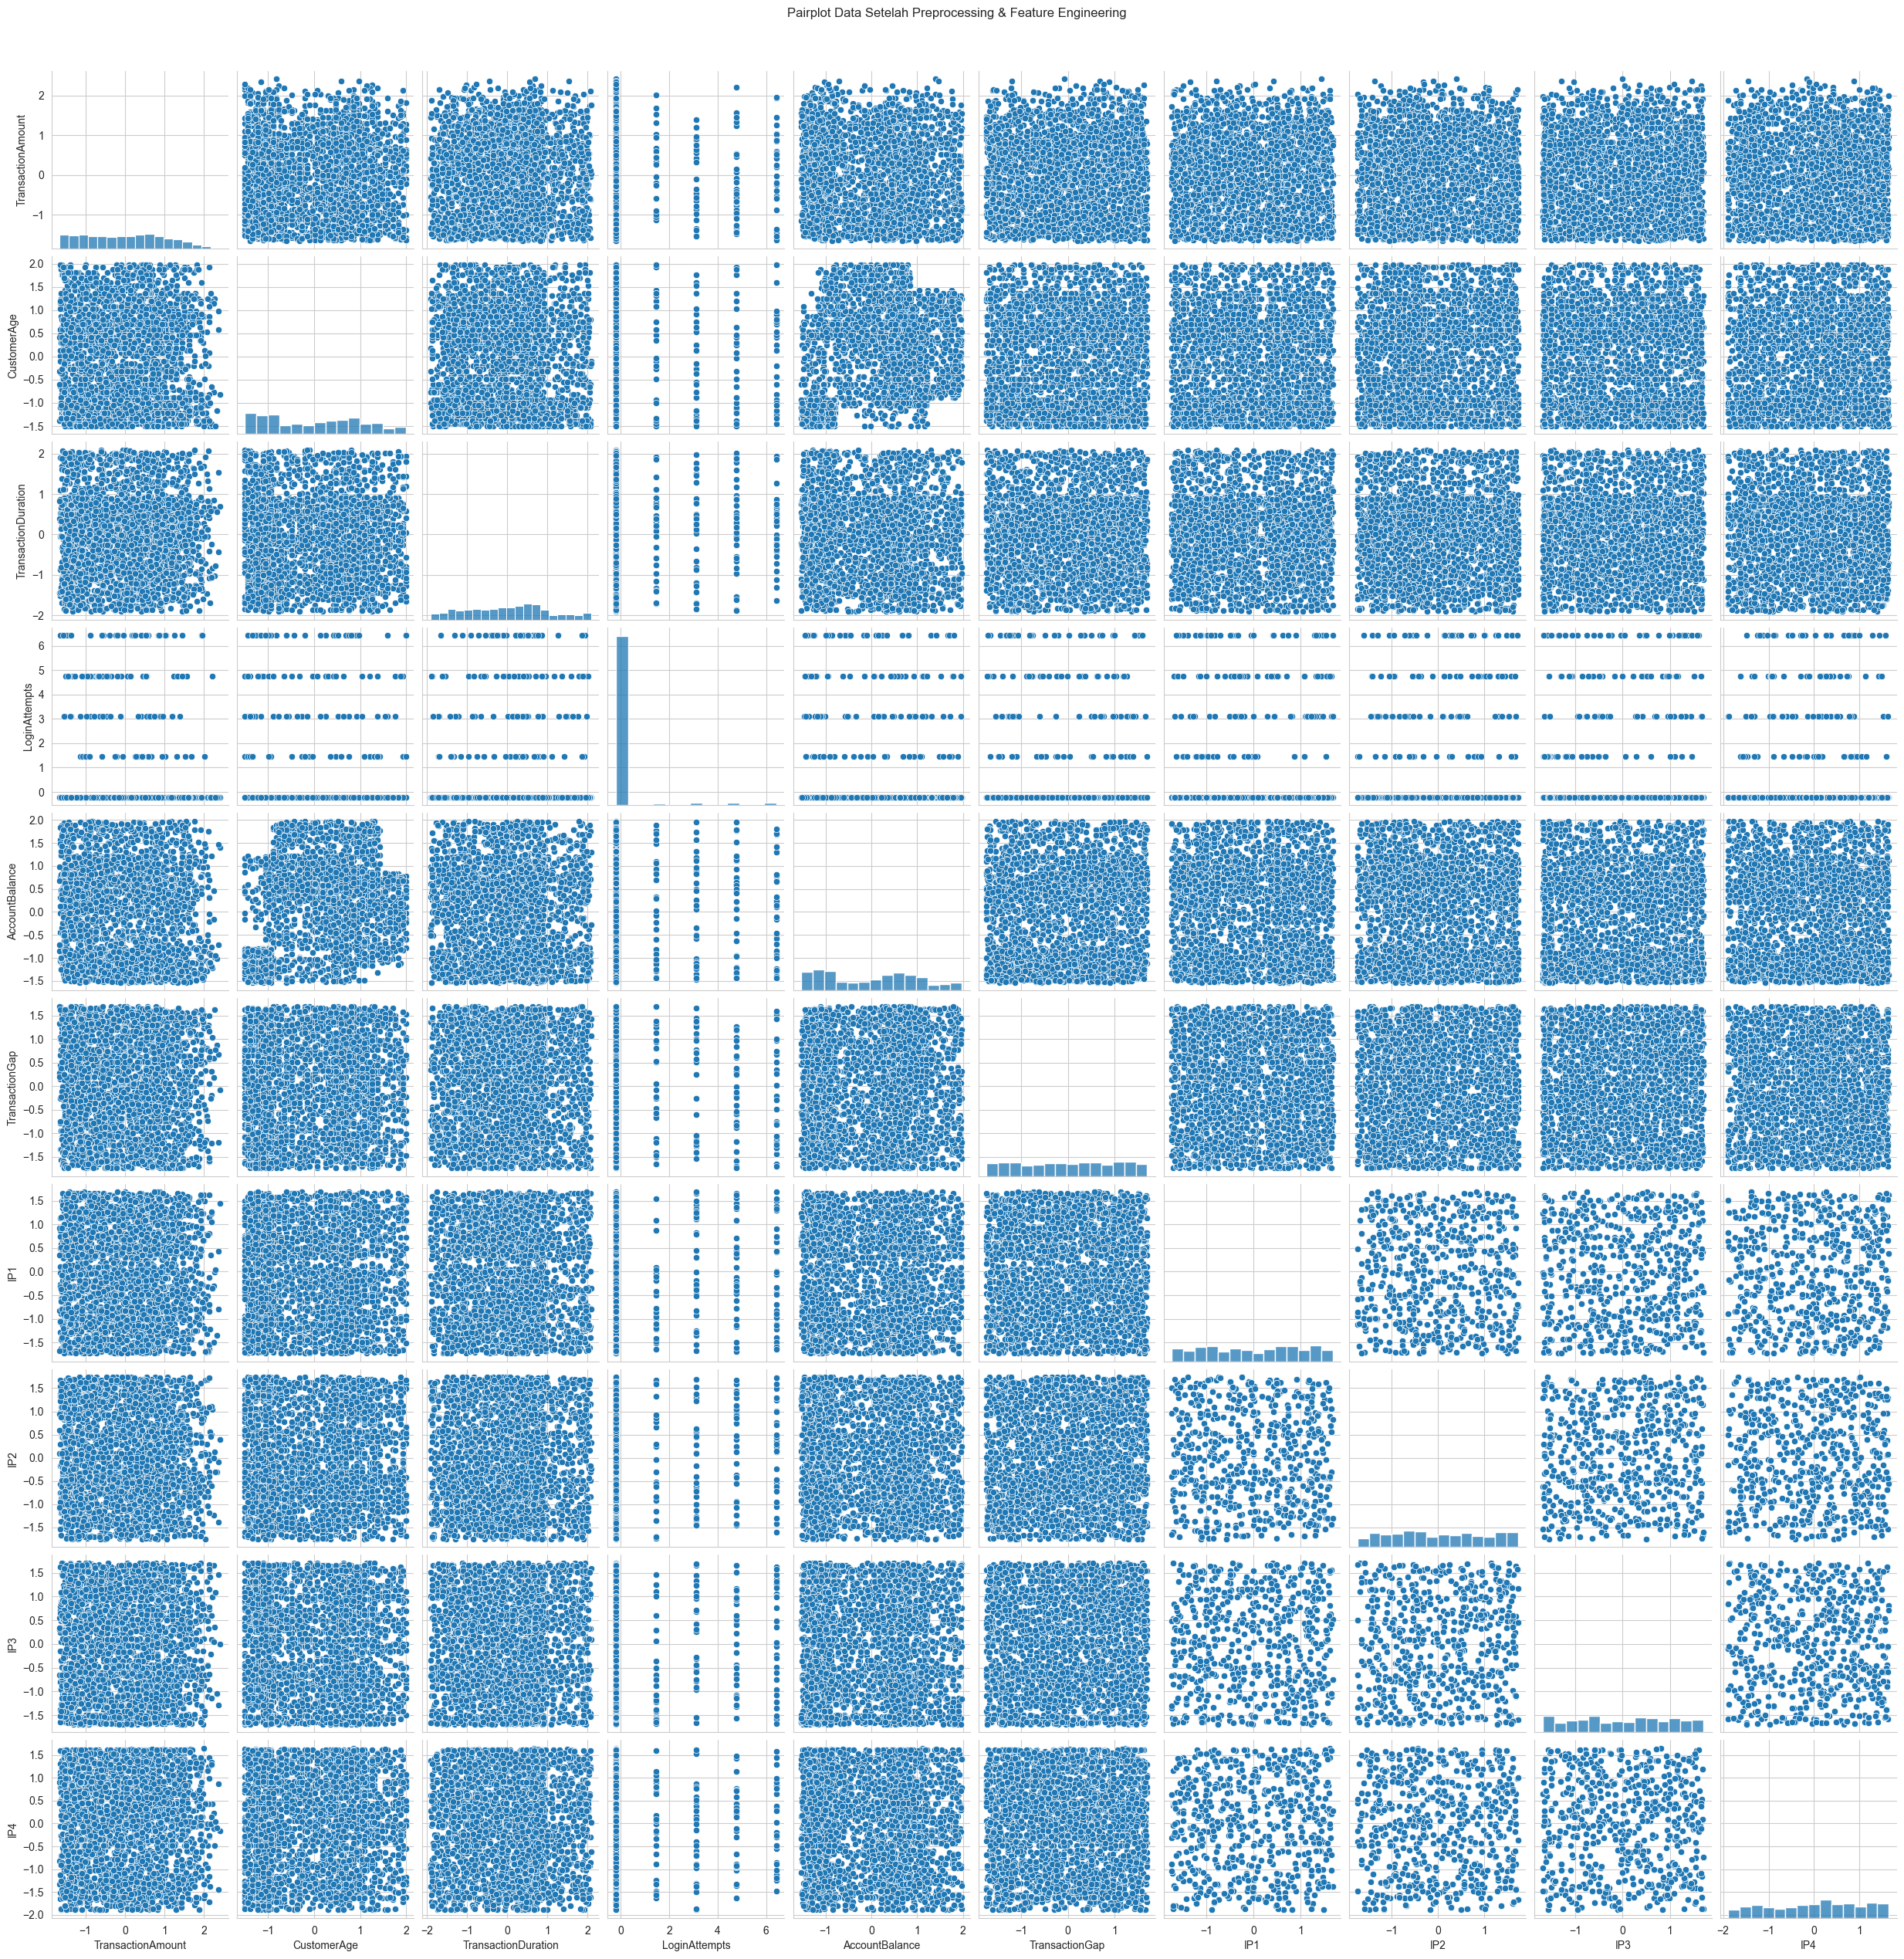

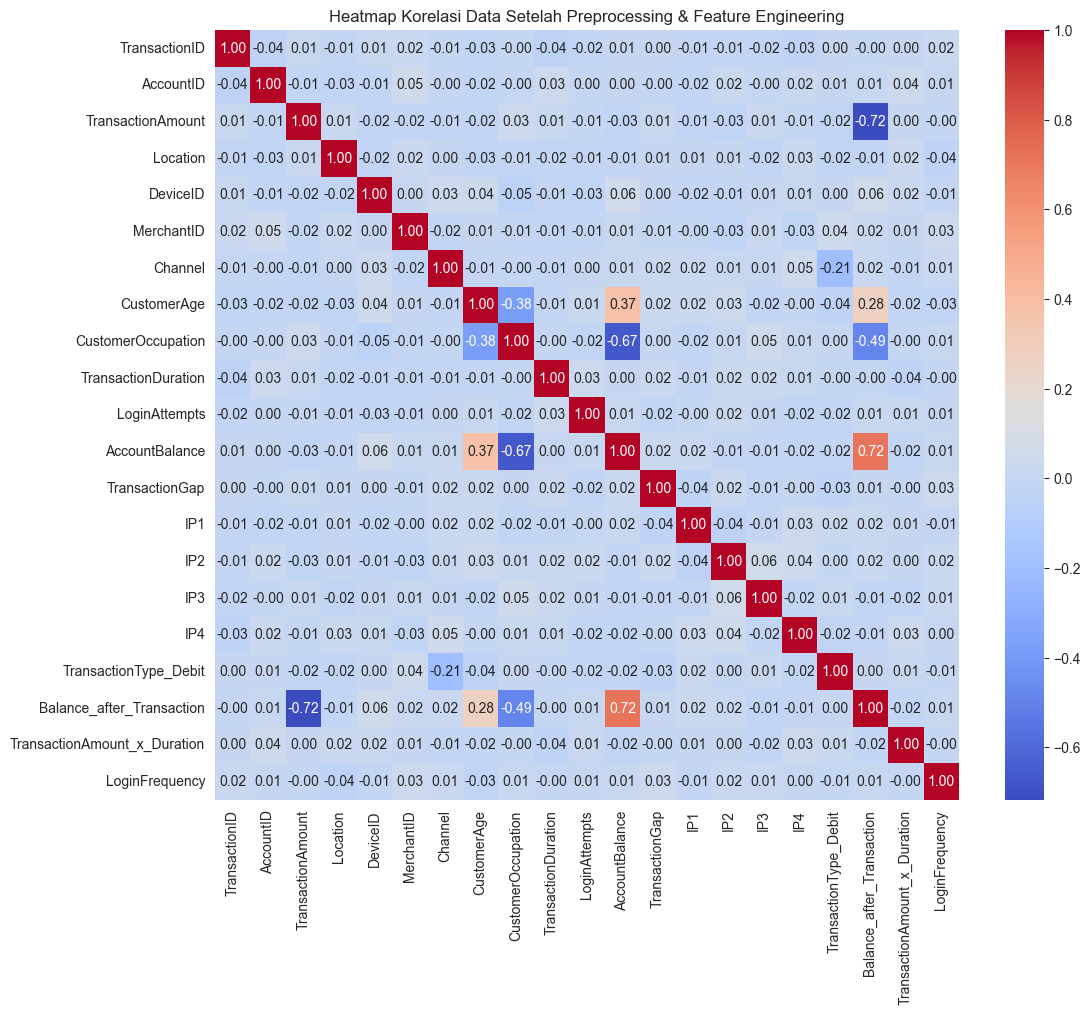


Cek Missing Values pada data_improve:
TransactionID                   0
AccountID                       0
TransactionAmount               0
Location                        0
DeviceID                        0
MerchantID                      0
Channel                         0
CustomerAge                     0
CustomerOccupation              0
TransactionDuration             0
LoginAttempts                   0
AccountBalance                  0
TransactionGap                  0
IP1                             0
IP2                             0
IP3                             0
IP4                             0
TransactionType_Debit           0
Balance_after_Transaction       0
TransactionAmount_x_Duration    0
LoginFrequency                  0
dtype: int64


In [20]:
# --- 5.4 VISUALISASI PAIRPLOT & MATRIX CORRELATION ---
sns.pairplot(data_improve[numeric_cols])
plt.suptitle('Pairplot Data Setelah Preprocessing & Feature Engineering', y=1.02)
plt.show()

plt.figure(figsize=(12, 10))
corr_matrix = data_improve.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Data Setelah Preprocessing & Feature Engineering')
plt.show()

print("\nCek Missing Values pada data_improve:")
print(data_improve.isna().sum())

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

Kolom yang digunakan (Sebelum Feature Selection):
['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionGap', 'IP1', 'IP2', 'IP3', 'IP4', 'Balance_after_Transaction', 'TransactionAmount_x_Duration', 'LoginFrequency']
[Sebelum] k = 2, Silhouette Score = 0.9880
[Sebelum] k = 3, Silhouette Score = 0.8823
[Sebelum] k = 4, Silhouette Score = 0.8877
[Sebelum] k = 5, Silhouette Score = 0.1900
[Sebelum] k = 6, Silhouette Score = 0.1892
[Sebelum] k = 7, Silhouette Score = 0.1984
[Sebelum] k = 8, Silhouette Score = 0.1983
[Sebelum] k = 9, Silhouette Score = 0.1984
[Sebelum] k = 10, Silhouette Score = 0.2029


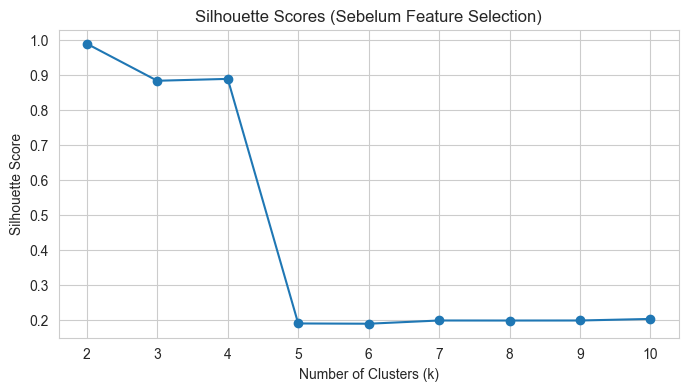

Best k (Sebelum Feature Selection): 2


In [21]:
# Gunakan semua kolom numerik yang ada di data_improve (tanpa menghapus apa pun)
data_before = data_improve.select_dtypes(include=['float64', 'int64']).copy()
print("Kolom yang digunakan (Sebelum Feature Selection):")
print(data_before.columns.tolist())

# Evaluasi K-Means untuk k = 2 hingga 10
candidate_ks = range(2, 11)
sil_scores_before = []

for k in candidate_ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_before)
    score = silhouette_score(data_before, labels)
    sil_scores_before.append(score)
    print(f"[Sebelum] k = {k}, Silhouette Score = {score:.4f}")

# Plot kurva Silhouette Score untuk data_before
plt.figure(figsize=(8, 4))
plt.plot(candidate_ks, sil_scores_before, marker='o', linestyle='-')
plt.title("Silhouette Scores (Sebelum Feature Selection)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(candidate_ks)
plt.grid(True)
plt.show()

# Tentukan best k untuk data_before
best_k_before = candidate_ks[np.argmax(sil_scores_before)]
print("Best k (Sebelum Feature Selection):", best_k_before)

# Lakukan clustering dengan best k
kmeans_best_before = KMeans(n_clusters=best_k_before, random_state=42).fit(data_before)
labels_best_before = kmeans_best_before.labels_

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.


Jumlah data dalam setiap cluster (Sebelum Feature Selection):
0    2507
1       5
Name: count, dtype: int64


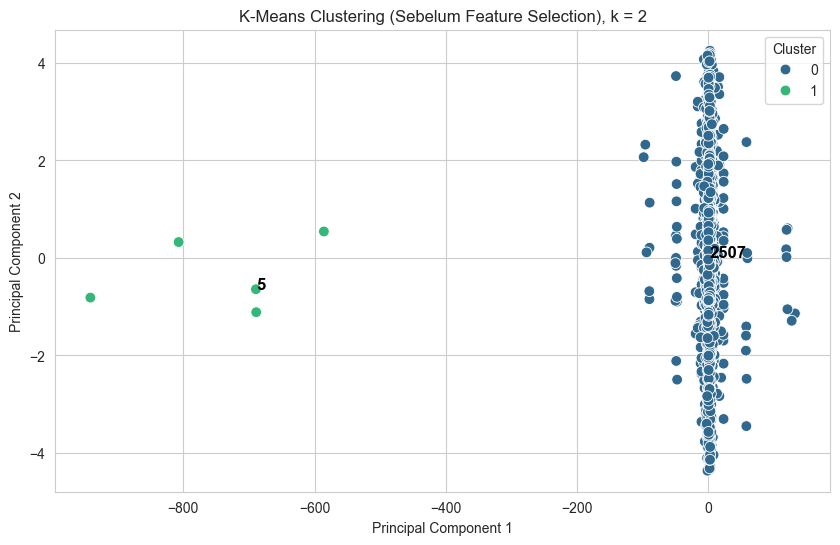

In [22]:
# Hitung jumlah data dalam setiap cluster sebelum feature selection
cluster_counts_before = pd.Series(labels_best_before).value_counts().sort_index()
print("\nJumlah data dalam setiap cluster (Sebelum Feature Selection):")
print(cluster_counts_before)

# Visualisasi clustering dengan PCA
pca_before = PCA(n_components=2, random_state=42)
pca_components_before = pca_before.fit_transform(data_before)
pca_df_before = pd.DataFrame(pca_components_before, columns=['PC1', 'PC2'])
# Pastikan label cluster dalam format string untuk konsistensi
pca_df_before['Cluster'] = pd.Series(labels_best_before).astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df_before, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60)
plt.title(f"K-Means Clustering (Sebelum Feature Selection), k = {best_k_before}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

# Tambahkan anotasi jumlah data di setiap cluster
for cluster, count in cluster_counts_before.items():
    cluster_str = str(cluster)
    cluster_data = pca_df_before[pca_df_before['Cluster'] == cluster_str]
    median_PC1 = cluster_data['PC1'].median()
    median_PC2 = cluster_data['PC2'].median()
    plt.annotate(f"{count}", xy=(median_PC1, median_PC2), fontsize=12, color='black', weight='bold')

plt.show()


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [23]:
# # Tampilkan kolom yang tersedia sebelum feature selection
# print("Kolom yang tersedia sebelum Feature Selection:")
# print(data_improve.columns.tolist())

# # ---------------------------
# # Feature Selection Otomatis Unsupervised dengan VarianceThreshold
# # ---------------------------
# # Misalnya, kita menghilangkan fitur yang variansinya kurang dari 0.1
# vt = VarianceThreshold(threshold=0.1)
# vt.fit(data_improve)

# # Dapatkan fitur-fitur yang lolos seleksi
# selected_features = data_improve.columns[vt.get_support()]
# print("\nFitur yang terpilih berdasarkan VarianceThreshold:")
# print(selected_features.tolist())

# # Buat data baru hanya dengan fitur terpilih
# data_after = data_improve[selected_features].copy()
# print("\nKolom yang digunakan (Setelah Feature Selection):")
# print(data_after.columns.tolist())

# # ---------------------------
# # Evaluasi Clustering dengan K-Means (Setelah Feature Selection)
# # ---------------------------
# # Misal kita evaluasi jumlah cluster k dari 2 hingga 10
# candidate_ks = list(range(2, 11))
# sil_scores_after = []

# for k in candidate_ks:
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(data_after)
#     score = silhouette_score(data_after, labels)
#     sil_scores_after.append(score)
#     print(f"[Setelah] k = {k}, Silhouette Score = {score:.4f}")

# # Plot kurva Silhouette Score untuk data_after
# plt.figure(figsize=(8, 4))
# plt.plot(candidate_ks, sil_scores_after, marker='o', linestyle='-')
# plt.title("Silhouette Scores (Setelah Feature Selection)")
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Silhouette Score")
# plt.xticks(candidate_ks)
# plt.grid(True)
# plt.show()

# # Tentukan best k berdasarkan skor tertinggi
# best_k_after = candidate_ks[np.argmax(sil_scores_after)]
# print("\nBest k (Setelah Feature Selection):", best_k_after)

# # Lakukan clustering dengan best k
# kmeans_best_after = KMeans(n_clusters=best_k_after, random_state=42).fit(data_after)
# labels_best_after = kmeans_best_after.labels_

# # Hitung jumlah data dalam setiap cluster setelah feature selection
# cluster_counts_after = pd.Series(labels_best_after).value_counts().sort_index()
# print("\nJumlah data dalam setiap cluster (Setelah Feature Selection):")
# print(cluster_counts_after)

# # ---------------------------
# # Visualisasi Clustering dengan PCA (Setelah Feature Selection)
# # ---------------------------
# # Reduksi dimensi ke 2 komponen utama untuk visualisasi
# pca_after = PCA(n_components=2, random_state=42)
# pca_components_after = pca_after.fit_transform(data_after)
# pca_df_after = pd.DataFrame(pca_components_after, columns=['PC1', 'PC2'])
# pca_df_after['Cluster'] = labels_best_after.astype(str)

# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=pca_df_after, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60)
# plt.title(f"K-Means Clustering (Setelah Feature Selection), k = {best_k_after}")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")

# # Tambahkan anotasi jumlah data di setiap cluster
# for cluster, count in cluster_counts_after.items():
#     median_PC1 = pca_df_after[pca_df_after['Cluster'] == str(cluster)]['PC1'].median()
#     median_PC2 = pca_df_after[pca_df_after['Cluster'] == str(cluster)]['PC2'].median()
#     plt.annotate(f"{count}", xy=(median_PC1, median_PC2), fontsize=12, color='black', weight='bold')

# plt.show()


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

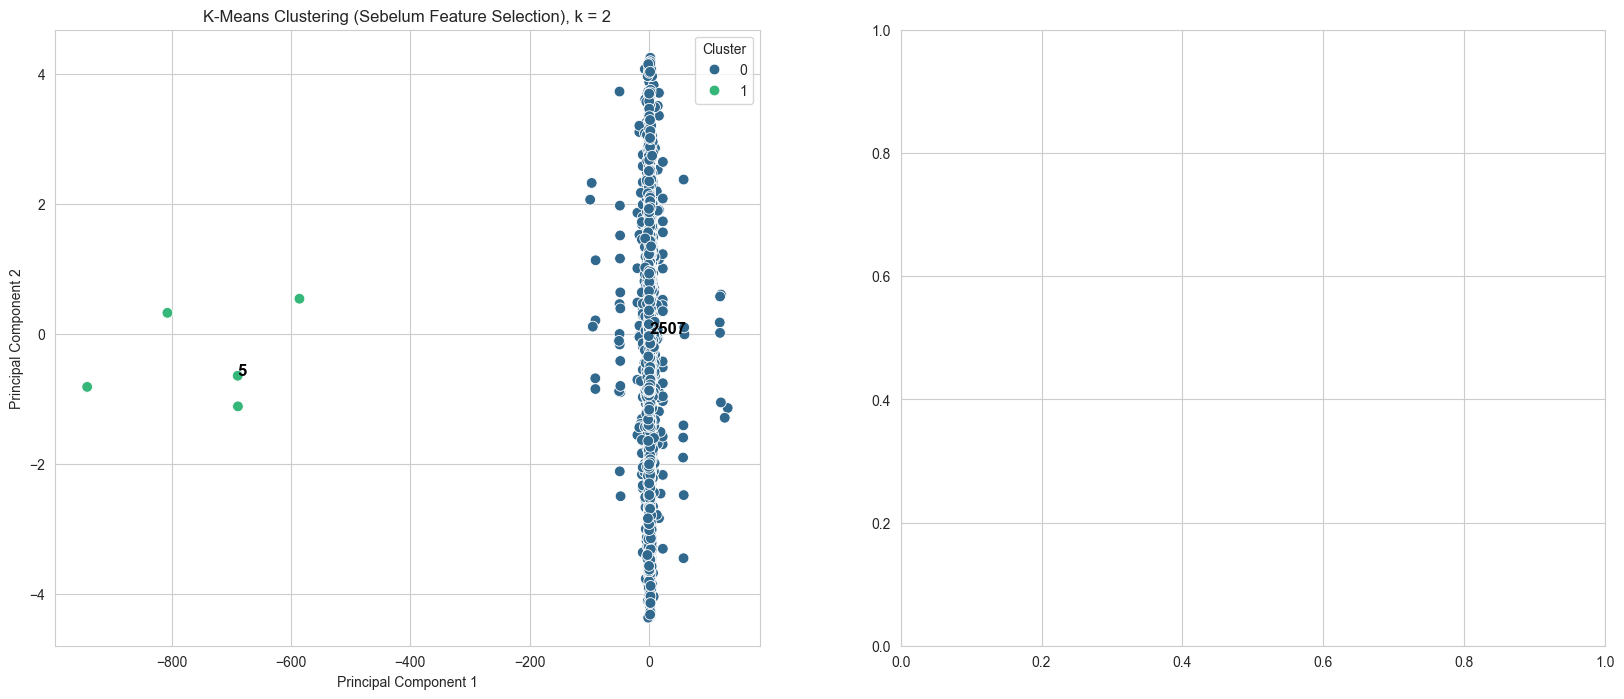

In [24]:
# --- Visualisasi Kedua Clustering: Sebelum dan Setelah Feature Selection ---

# Visualisasi Sebelum Feature Selection sudah disiapkan
pca_before = PCA(n_components=2, random_state=42)
pca_components_before = pca_before.fit_transform(data_before)
pca_df_before = pd.DataFrame(pca_components_before, columns=['PC1', 'PC2'])
pca_df_before['Cluster'] = pd.Series(labels_best_before).astype(str)

# # Visualisasi Setelah Feature Selection sudah disiapkan
# pca_after = PCA(n_components=2, random_state=42)
# pca_components_after = pca_after.fit_transform(data_after)
# pca_df_after = pd.DataFrame(pca_components_after, columns=['PC1', 'PC2'])
# pca_df_after['Cluster'] = pd.Series(labels_best_after).astype(str)

# Membuat figure dengan 2 subplot (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Visualisasi clustering sebelum feature selection
sns.scatterplot(ax=axes[0], data=pca_df_before, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60)
axes[0].set_title(f"K-Means Clustering (Sebelum Feature Selection), k = {best_k_before}")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(title="Cluster")

# Tambahkan anotasi jumlah data di setiap cluster (sebelum feature selection)
for cluster, count in cluster_counts_before.items():
    cluster_str = str(cluster)
    cluster_data = pca_df_before[pca_df_before['Cluster'] == cluster_str]
    median_PC1 = cluster_data['PC1'].median()
    median_PC2 = cluster_data['PC2'].median()
    axes[0].annotate(f"{count}", xy=(median_PC1, median_PC2), fontsize=12, color='black', weight='bold')

# # Visualisasi clustering setelah feature selection
# sns.scatterplot(ax=axes[1], data=pca_df_after, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60)
# axes[1].set_title(f"K-Means Clustering (Setelah Feature Selection), k = {best_k_after}")
# axes[1].set_xlabel("Principal Component 1")
# axes[1].set_ylabel("Principal Component 2")
# axes[1].legend(title="Cluster")

# # Tambahkan anotasi jumlah data di setiap cluster (setelah feature selection)
# for cluster, count in cluster_counts_after.items():
#     cluster_str = str(cluster)
#     cluster_data = pca_df_after[pca_df_after['Cluster'] == cluster_str]
#     median_PC1 = cluster_data['PC1'].median()
#     median_PC2 = cluster_data['PC2'].median()
#     axes[1].annotate(f"{count}", xy=(median_PC1, median_PC2), fontsize=12, color='black', weight='bold')

# plt.tight_layout()
# plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [25]:
# ===============================================================
# 1. Inverse Transform untuk Semua Data (URUTAN DIPERBAIKI)
# ===============================================================

def inverse_transform_all(df_transformed, transformation_info):
    df_inversed = df_transformed.copy()

    # Reverse Initial Date Handling (TransactionGap)
    if 'LoginFrequency' in transformation_info and 'TransactionGap' in df_inversed.columns:
        print("\nInverse Feature Engineering (TransactionGap):")
        print("Nilai sebelum:")
        print(df_inversed['LoginFrequency'].head())
        try:
            epsilon = transformation_info['LoginFrequency'].get('epsilon', 1e-07)
            df_inversed['TransactionGap'] = 1 / (df_inversed['LoginFrequency'] + epsilon)
            print("Nilai setelah:")
            print(df_inversed['TransactionGap'].head())
        except Exception as e:
            print(f"Peringatan: Inverse Feature Engineering gagal untuk LoginFrequency (TransactionGap): {e}")
        df_inversed.drop(columns=['LoginFrequency'], inplace=True, errors='ignore')

    # Inverse Label Encoding (Custom)
    if 'label_encoders' in transformation_info:
        label_encoders = transformation_info['label_encoders']
        print("\nInverse Label Encoding (Custom):")
        cols_custom_encoded = ['Location', 'CustomerOccupation', 'Channel']
        for col in cols_custom_encoded:
            if col in df_inversed.columns and col in label_encoders:
                encoder = label_encoders[col]
                print(f"\nKolom: {col}")
                print("Nilai sebelum:")
                print(df_inversed[col].head())
                try:
                    # Ensure the data type is appropriate for inverse transform
                    if df_inversed[col].dtype == np.float64:
                        df_inversed[col] = df_inversed[col].round().astype(int)
                    df_inversed[col] = encoder.inverse_transform(df_inversed[col])
                    print("Nilai setelah:")
                    print(df_inversed[col].head())
                except Exception as e:
                    print(f"Peringatan: Inverse Label Encoding gagal untuk kolom '{col}': {e}")

    # Inverse Scaling (StandardScaler)
    if 'StandardScaler' in transformation_info:
        scaler = transformation_info['StandardScaler']['scaler']
        columns_to_inverse = transformation_info['StandardScaler']['columns']
        print("\nInverse StandardScaler:")
        print(f"Kolom yang di-inverse: {columns_to_inverse}")
        print("Nilai sebelum:")
        print(df_inversed[columns_to_inverse].head())
        try:
            df_inversed[columns_to_inverse] = scaler.inverse_transform(df_inversed[columns_to_inverse])
            print("Nilai setelah:")
            print(df_inversed[columns_to_inverse].head())
        except Exception as e:
            print(f"Peringatan: Inverse StandardScaler gagal: {e}")

    # Inverse Skewness Reduction
    if 'skewness_reduction' in transformation_info:
        skewness_transformers = transformation_info['skewness_reduction']
        data_before_skew_info = transformation_info.get('data_before_skew', {})
        print("\nInverse Skewness Reduction:")
        for col, transform_data in skewness_transformers.items():
            if col in df_inversed.columns:
                method = transform_data.get('method')
                transformer = transform_data.get('transformer')
                print(f"\nKolom: {col}, Metode: {method}")
                print("Nilai sebelum:")
                print(df_inversed[col].head())
                if method == "Yeo-Johnson" and transformer:
                    try:
                        df_inversed[col] = transformer.inverse_transform(df_inversed[[col]]).flatten()
                        print("Nilai setelah Inverse Yeo-Johnson:")
                        print(df_inversed[col].head())
                    except Exception as e:
                        print(f"Peringatan: Inverse Yeo-Johnson gagal untuk kolom '{col}': {e}")
                elif method == "QuantileTransformer" and transformer:
                    try:
                        df_inversed[col] = transformer.inverse_transform(df_inversed[[col]])
                        print("Nilai setelah Inverse QuantileTransformer:")
                        print(df_inversed[col].head())
                    except Exception as e:
                        print(f"Peringatan: Inverse QuantileTransformer gagal untuk kolom '{col}': {e}")
                elif method == "log1p":
                    try:
                        df_inversed[col] = np.expm1(df_inversed[col])
                        original_min = data_before_skew_info.get(col, {}).get('min')
                        if original_min is not None:
                            df_inversed[col] = df_inversed[col] - abs(original_min) - 1
                        print("Nilai setelah Inverse log1p:")
                        print(df_inversed[col].head())
                    except Exception as e:
                        print(f"Peringatan: Inverse log1p gagal untuk kolom '{col}': {e}")
                elif method == "Box-Cox" and transformer is not None:
                    try:
                        original_min = data_before_skew_info.get(col, {}).get('min')
                        shift = abs(original_min) + 1 if original_min <= 0 else 0
                        df_inversed[col] = inv_boxcox(df_inversed[col] + shift, transformer) - shift
                        print("Nilai setelah Inverse Box-Cox:")
                        print(df_inversed[col].head())
                    except Exception as e:
                        print(f"Peringatan: Inverse Box-Cox gagal untuk kolom '{col}': {e}")

    # Inverse Scaling (RobustScaler)
    if 'RobustScaler' in transformation_info:
        scaler = transformation_info['RobustScaler']['scaler']
        columns_to_inverse = transformation_info['RobustScaler']['columns']
        print("\nInverse RobustScaler:")
        print(f"Kolom yang di-inverse: {columns_to_inverse}")
        print("Nilai sebelum:")
        print(df_inversed[columns_to_inverse].head())
        try:
            df_inversed[columns_to_inverse] = scaler.inverse_transform(df_inversed[columns_to_inverse])
            print("Nilai setelah:")
            print(df_inversed[columns_to_inverse].head())
        except Exception as e:
            print(f"Peringatan: Inverse RobustScaler gagal: {e}")

    # Inverse Label Encoding (Other Categorical)
    if 'label_encoders' in transformation_info:
        label_encoders = transformation_info['label_encoders']
        print("\nInverse Label Encoding (Other Categorical):")
        categorical_cols = [col for col in df_inversed.columns if col not in ['Location', 'CustomerOccupation', 'Channel'] and col in label_encoders]
        for col in categorical_cols:
            encoder = label_encoders[col]
            print(f"\nKolom: {col}")
            print("Nilai sebelum:")
            print(df_inversed[col].head())
            try:
                # Ensure the data type is appropriate for inverse transform
                if df_inversed[col].dtype == np.float64:
                    df_inversed[col] = df_inversed[col].round().astype(int)
                df_inversed[col] = encoder.inverse_transform(df_inversed[col])
                print("Nilai setelah:")
                print(df_inversed[col].head())
            except Exception as e:
                print(f"Peringatan: Inverse Label Encoding gagal untuk kolom '{col}': {e}")

    # Inverse One-Hot Encoding
    if 'TransactionType' in transformation_info and transformation_info['TransactionType']['transformation'] == 'one_hot_encoding':
        ohe_cols = [col for col in df_inversed.columns if col.startswith('TransactionType_')]
        if ohe_cols:
            print("\nInverse One-Hot Encoding:")
            print("Kolom One-Hot Encoding:", ohe_cols)
            print("Nilai sebelum:")
            print(df_inversed[ohe_cols].head())

            # Tambahan debugging prints
            print("Nama-nama kolom OHE:", ohe_cols)
            print("Tipe data kolom OHE:")
            print(df_inversed[ohe_cols].dtypes)
            print("Nilai unik dalam kolom OHE:")
            for col in ohe_cols:
                print(f"{col}: {df_inversed[col].unique()}")

            try:
                if len(ohe_cols) == 1:
                    ohe_col = ohe_cols[0]
                    # Assuming 'Credit' was the dropped category (alphabetically first)
                    df_inversed['TransactionType'] = np.where(df_inversed[ohe_col], 'Debit', 'Credit')
                else:
                    df_inversed['TransactionType'] = df_inversed[ohe_cols].idxmax(axis=1).str.replace('TransactionType_', '', regex=False)
                df_inversed.drop(columns=ohe_cols, inplace=True, errors='ignore')
                original_type = transformation_info['TransactionType'].get('original_type')
                if original_type is not None and original_type != 'object':
                    pass # Add logic to convert back to original type if needed
                print("Nilai setelah:")
                print(df_inversed['TransactionType'].head())
            except Exception as e:
                print(f"Peringatan: Inverse One-Hot Encoding gagal: {e}")

    # Inverse IP Address Split
    ip_cols = ['IP1', 'IP2', 'IP3', 'IP4']
    if all(col in df_inversed.columns for col in ip_cols) and 'IP Address' in transformation_info:
        print("\nInverse IP Address Split:")
        print("Nilai sebelum:")
        print(df_inversed[ip_cols].head())
        try:
            df_inversed['IP Address'] = df_inversed[ip_cols].astype(int).astype(str).agg('.'.join, axis=1)
            df_inversed.drop(columns=ip_cols, inplace=True, errors='ignore')
            print("Nilai setelah:")
            print(df_inversed['IP Address'].head())
        except Exception as e:
            print(f"Peringatan: Inverse IP Address split gagal: {e}")

    # Inverse Datetime Components
    date_component_cols = [col for col in df_inversed.columns if '_year' in col or '_month' in col or '_day' in col or '_hour' in col or '_minute' in col or '_second' in col]
    original_date_cols = set(transformation_info.get(col, {}).get('original_column') for col in df_inversed.columns if 'datetime_component' in transformation_info.get(col, {}).get('transformation', ''))
    print("\nInverse Datetime Components:")
    for original_col in original_date_cols:
        year_col = f'{original_col}_year'
        month_col = f'{original_col}_month'
        day_col = f'{original_col}_day'
        hour_col = f'{original_col}_hour'
        minute_col = f'{original_col}_minute'
        second_col = f'{original_col}_second'
        if all(col in df_inversed.columns for col in [year_col, month_col, day_col]):
            print(f"\nKolom Original: {original_col}")
            print("Nilai sebelum:")
            print(df_inversed[[year_col, month_col, day_col, hour_col, minute_col, second_col]].head())
            try:
                df_inversed[original_col] = pd.to_datetime(df_inversed[[year_col, month_col, day_col, hour_col, minute_col, second_col]].fillna(0).astype(int).astype(str).agg('-'.join, axis=1), format='%Y-%m-%d-%H-%M-%S', errors='coerce')
                df_inversed.drop(columns=[year_col, month_col, day_col, hour_col, minute_col, second_col], inplace=True, errors='ignore')
                print("Nilai setelah:")
                print(df_inversed[original_col].head())
            except Exception as e:
                print(f"Peringatan: Inverse datetime components gagal untuk kolom '{original_col}': {e}")

    print("\nContoh data setelah inverse transform:")
    print(df_inversed.head())

    return df_inversed

# ===============================================================
# 2. Visualisasi Perbandingan: Data Original vs. Hasil Inverse Transform
# ===============================================================
def visualize_comparison(df_original, df_inversed, transformation_info):
    # Ambil kolom numerik dan kategorikal dari data original yang *sebenarnya*
    numeric_cols_original = df_original.select_dtypes(include=['float64', 'int64']).columns
    categorical_cols_original = df_original.select_dtypes(include=['object', 'category']).columns

    # Visualisasi untuk kolom numerik
    for col in numeric_cols_original:
        if col in df_inversed.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            sns.histplot(df_original[col], bins=50, kde=True, ax=axes[0], color='blue')
            axes[0].set_title(f"{col} - Original")
            sns.histplot(df_inversed[col], bins=50, kde=True, ax=axes[1], color='orange')
            axes[1].set_title(f"{col} - Inversed")
            plt.suptitle(f"Perbandingan Distribusi untuk Kolom Numerik: {col}")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            sns.boxplot(x=df_original[col], ax=axes[0], color='blue')
            axes[0].set_title(f"{col} - Original")
            sns.boxplot(x=df_inversed[col], ax=axes[1], color='orange')
            axes[1].set_title(f"{col} - Inversed")
            plt.suptitle(f"Perbandingan Boxplot untuk Kolom Numerik: {col}")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    # Visualisasi untuk kolom kategorikal
    # Kita perlu memetakan kolom-kolom hasil inverse transform ke kolom original
    label_encoded_cols = list(transformation_info.get('label_encoders', {}).keys())
    cols_custom_encoded = ['Location', 'CustomerOccupation', 'Channel']
    all_encoded_categorical = list(set(label_encoded_cols + cols_custom_encoded))

    for col in categorical_cols_original:
        # Perlu penyesuaian nama kolom jika inverse transform tidak mengembalikan nama yang sama persis
        inversed_col_name = col
        if col in ['Location', 'CustomerOccupation', 'Channel']:
            inversed_col_name = col # Nama kolom ini tetap sama setelah inverse

        if inversed_col_name in df_inversed.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            df_original[col].value_counts().nlargest(10).plot(kind='bar', ax=axes[0], color='blue')
            axes[0].set_title(f"{col} - Original (Top 10)")
            df_inversed[inversed_col_name].value_counts().nlargest(10).plot(kind='bar', ax=axes[1], color='orange')
            axes[1].set_title(f"{inversed_col_name} - Inversed (Top 10)")
            plt.suptitle(f"Perbandingan Value Counts untuk Kolom Kategorikal: {col}")
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```


Inverse Feature Engineering (TransactionGap):
Nilai sebelum:
0    -1.248811
1   -13.036725
2    21.674265
3    -1.738837
4     1.033708
Name: LoginFrequency, dtype: float64
Nilai setelah:
0   -0.800762
1   -0.076706
2    0.046138
3   -0.575097
4    0.967391
Name: TransactionGap, dtype: float64

Inverse Label Encoding (Custom):

Kolom: Location
Nilai sebelum:
0    36
1    15
2    23
3    33
4     1
Name: Location, dtype: int32
Nilai setelah:
0    San Diego
1      Houston
2         Mesa
3      Raleigh
4      Atlanta
Name: Location, dtype: object

Kolom: CustomerOccupation
Nilai sebelum:
0    0
1    0
2    3
3    3
4    3
Name: CustomerOccupation, dtype: int32
Nilai setelah:
0     Doctor
1     Doctor
2    Student
3    Student
4    Student
Name: CustomerOccupation, dtype: object

Kolom: Channel
Nilai sebelum:
0    0
1    0
2    2
3    2
4    2
Name: Channel, dtype: int32
Nilai setelah:
0       ATM
1       ATM
2    Online
3    Online
4    Online
Name: Channel, dtype: object

Inverse Standa

c:\ProgramFilesX\Python310\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\ProgramFilesX\Python310\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
c:\ProgramFilesX\Python310\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(


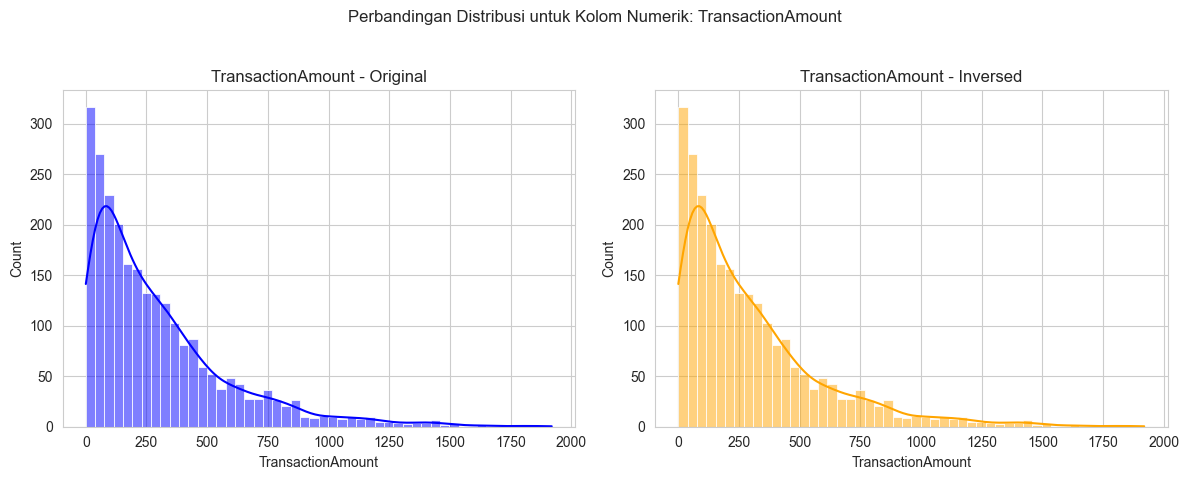

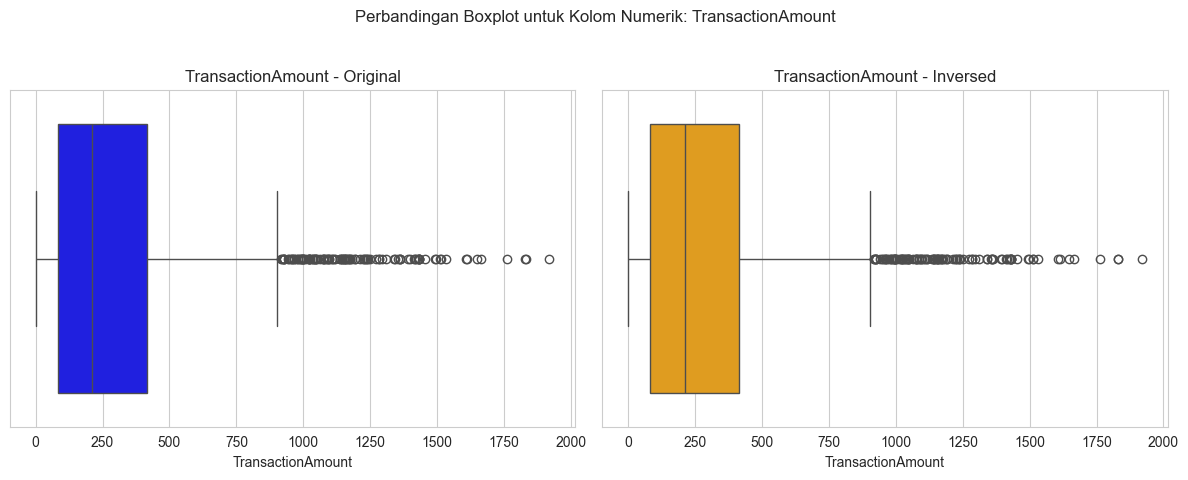

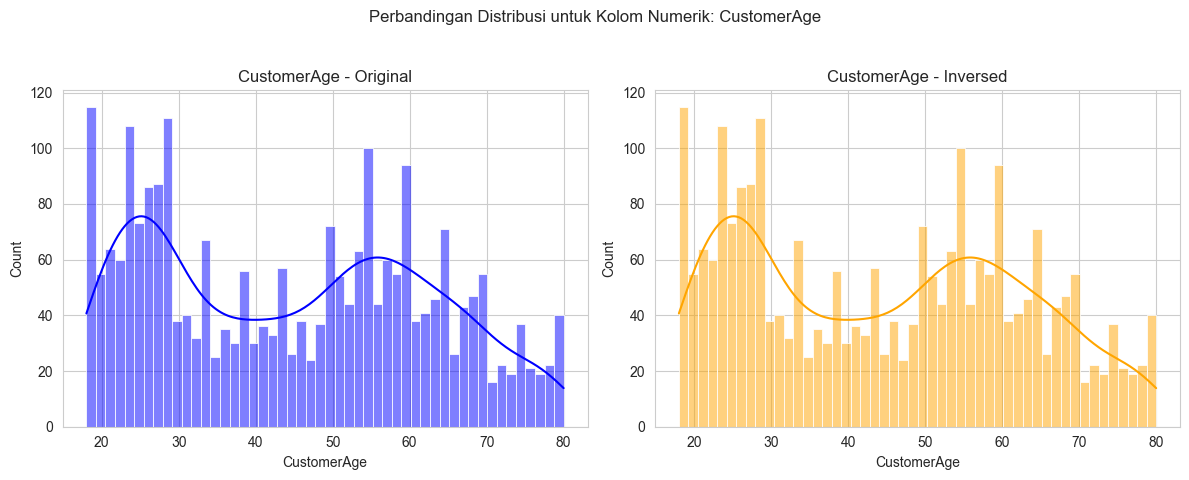

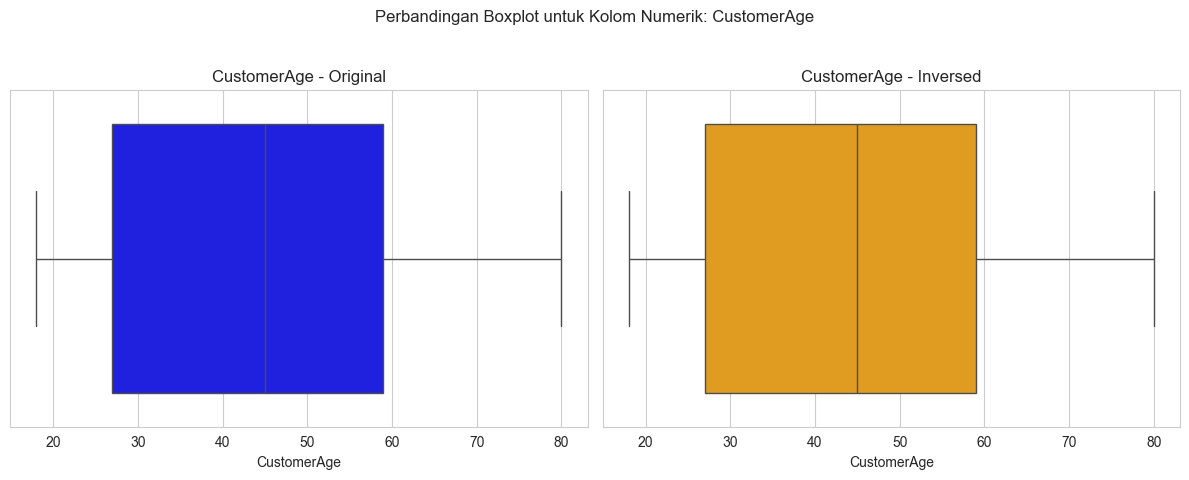

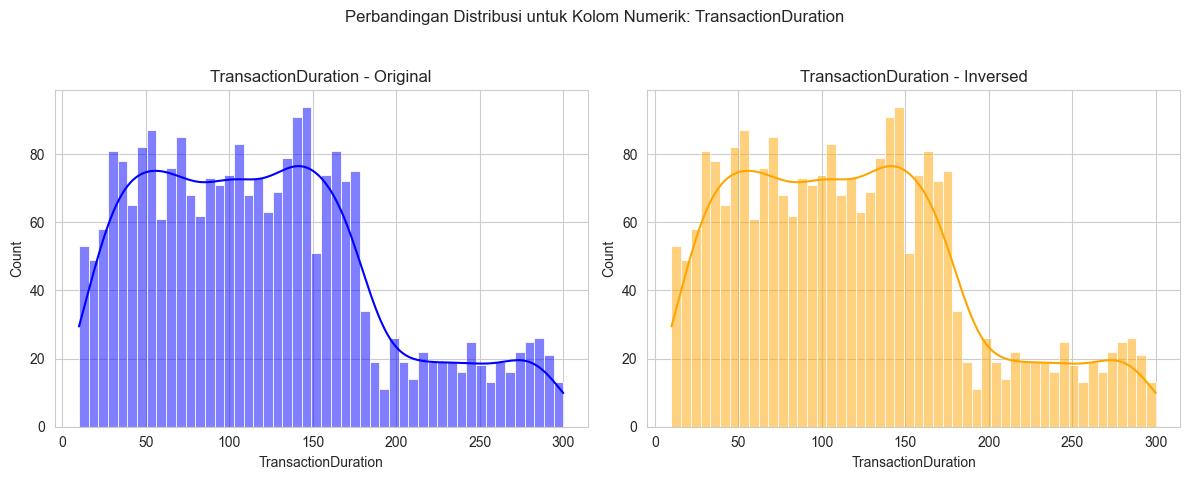

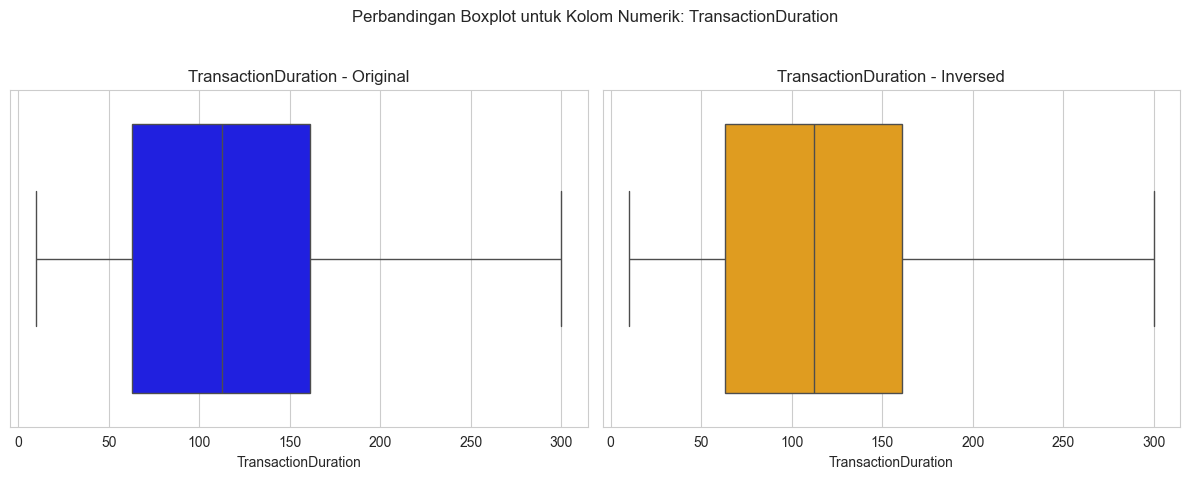

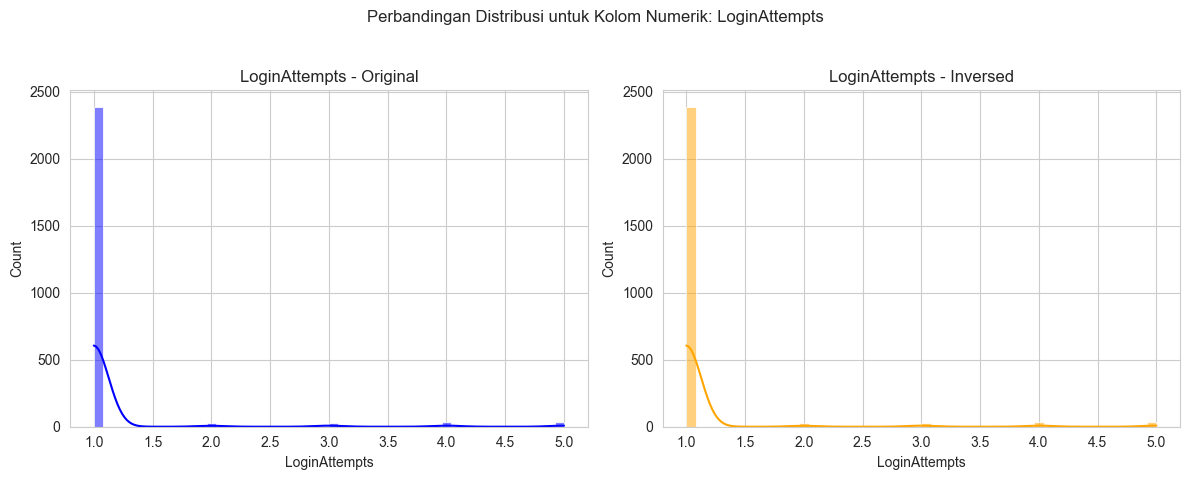

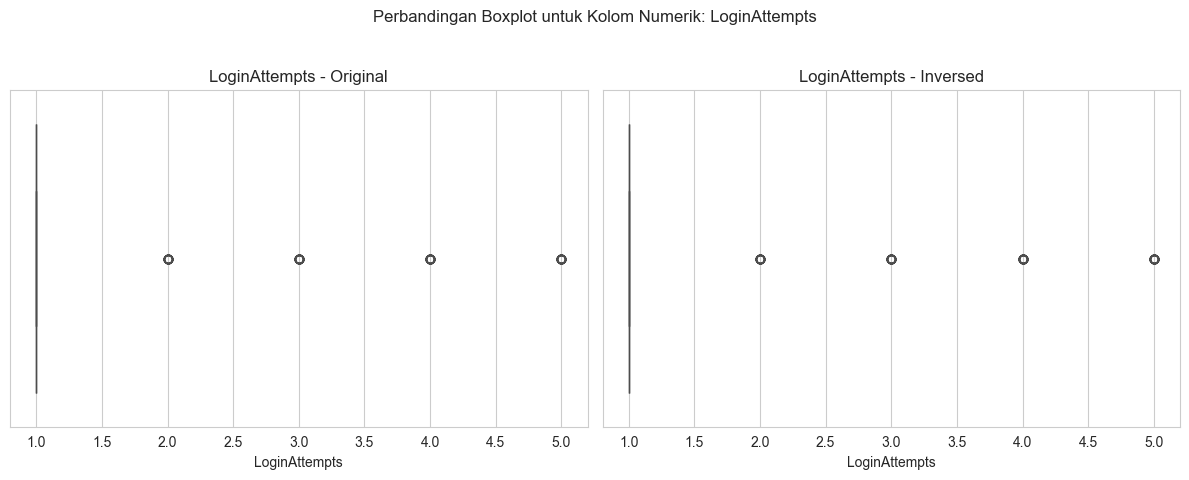

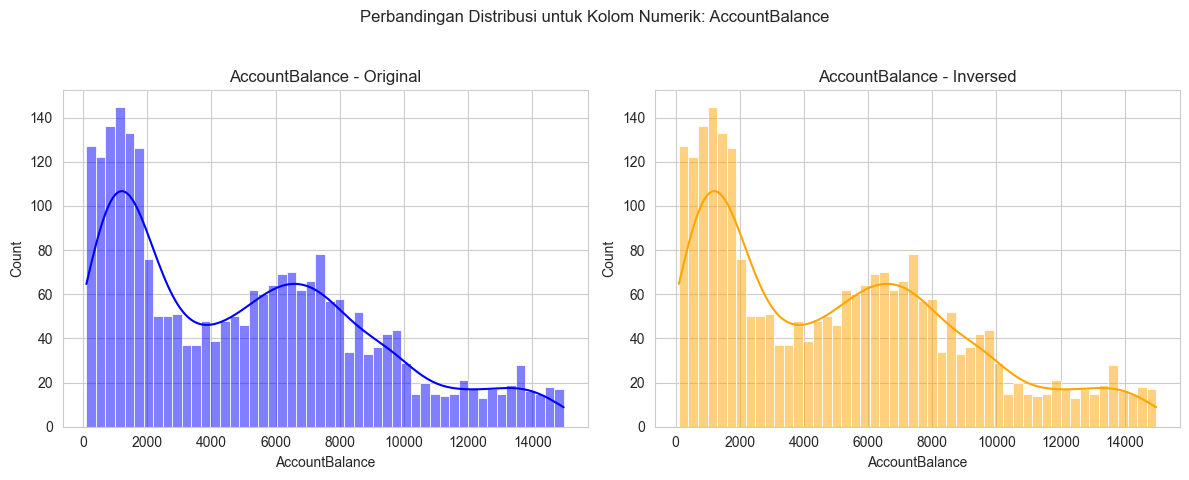

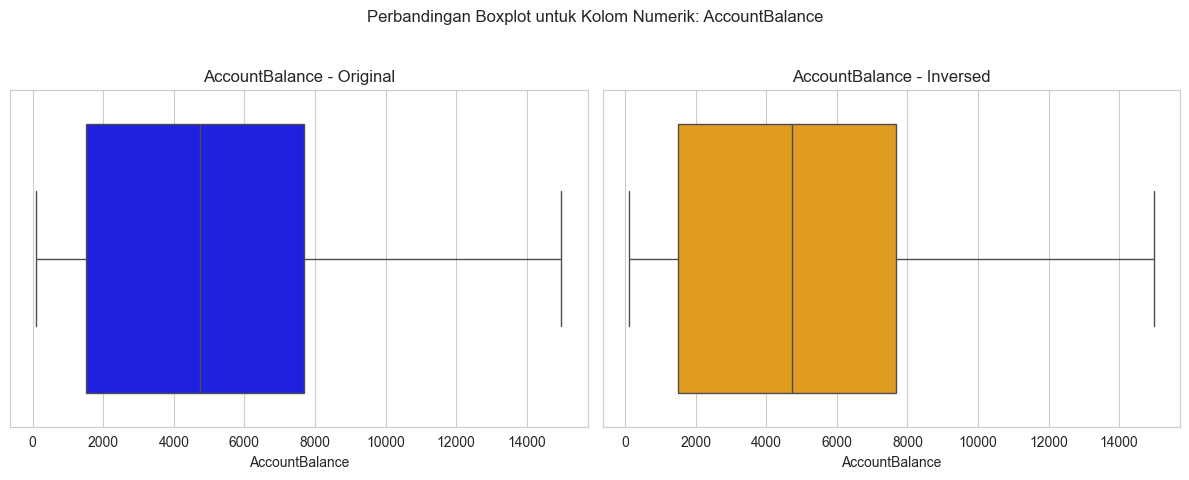

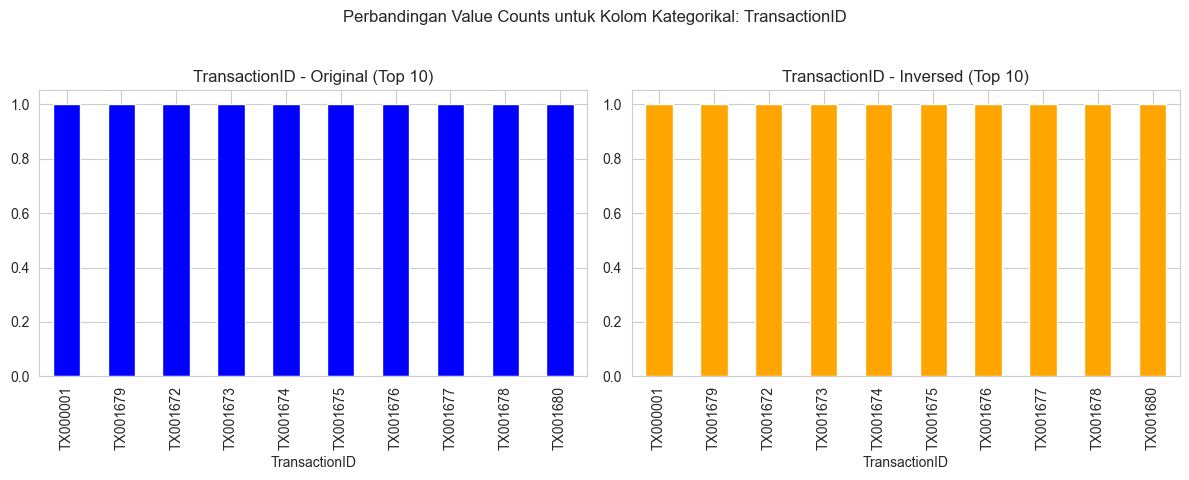

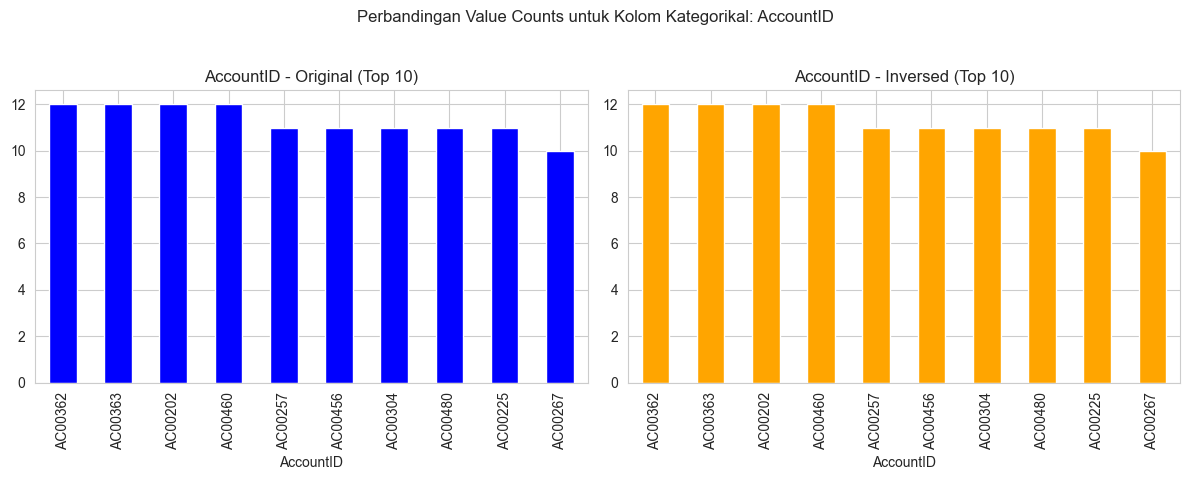

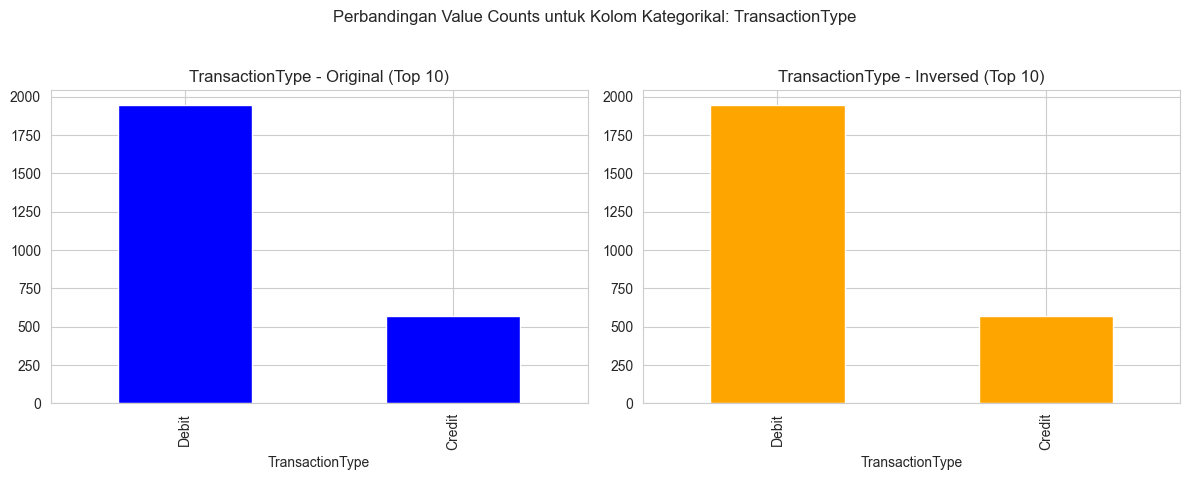

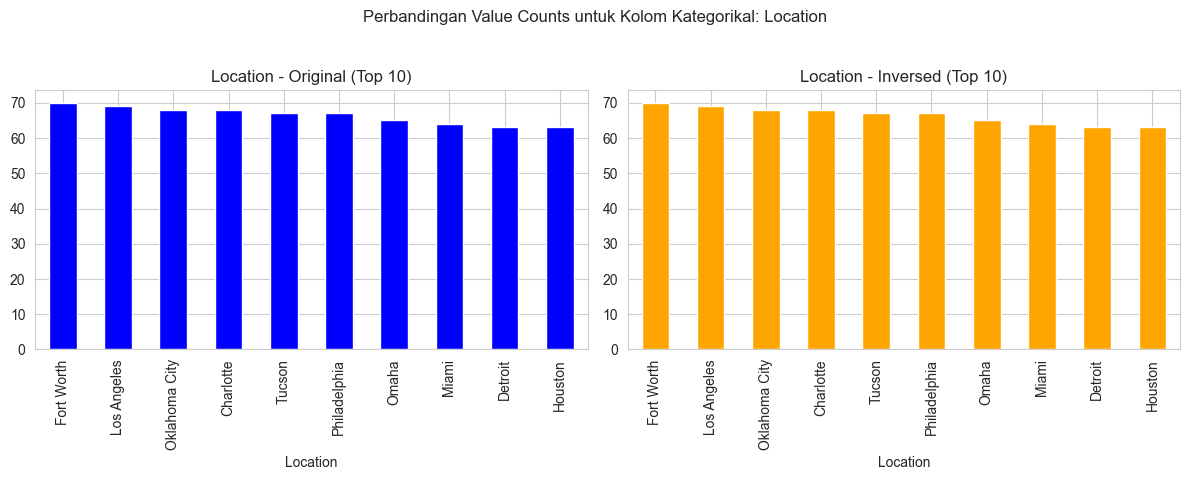

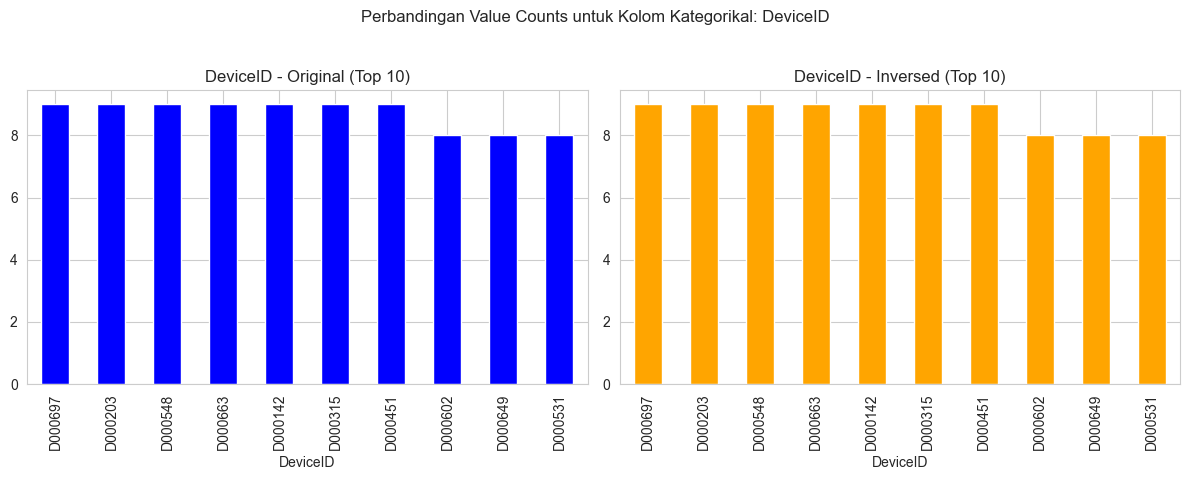

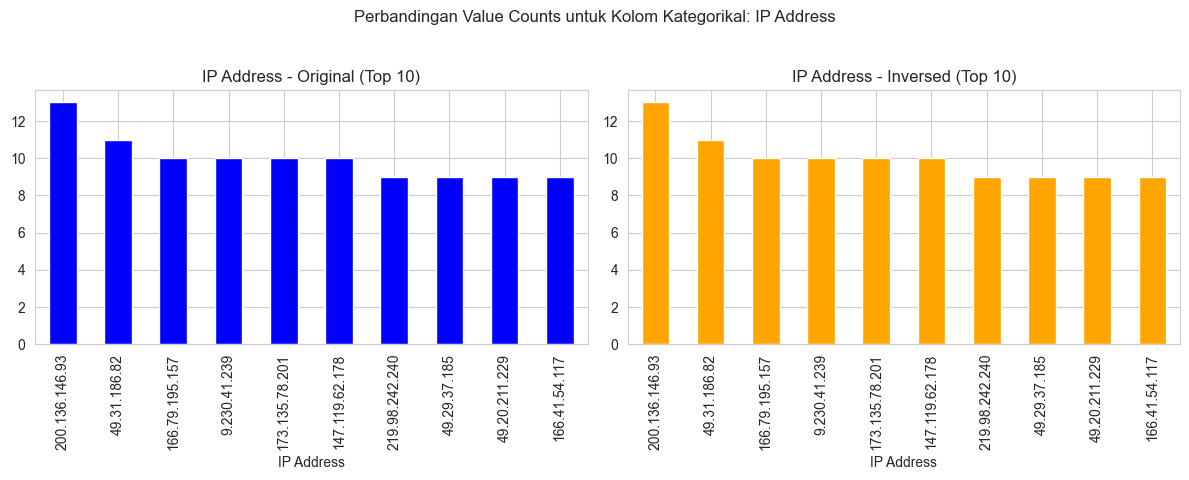

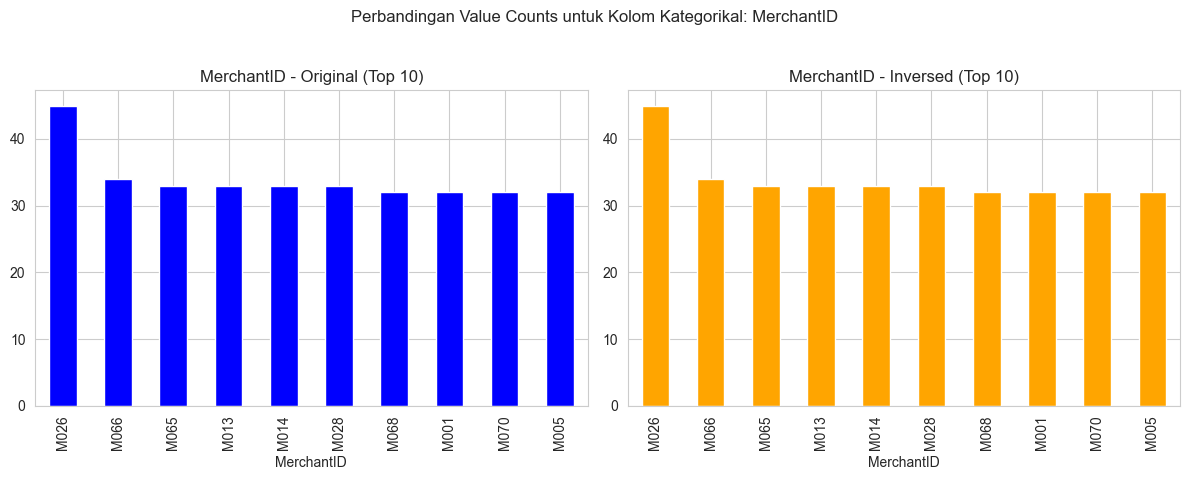

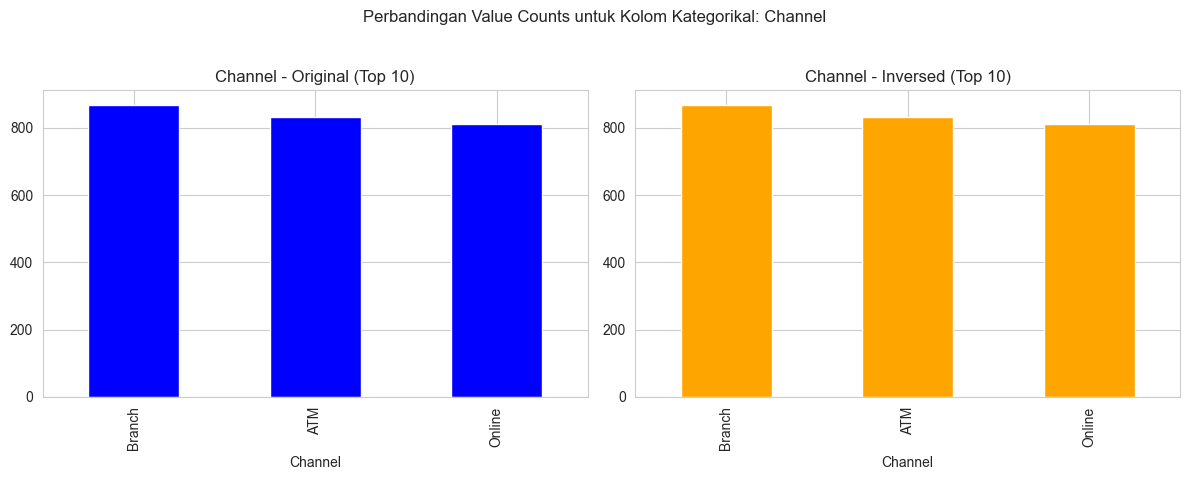

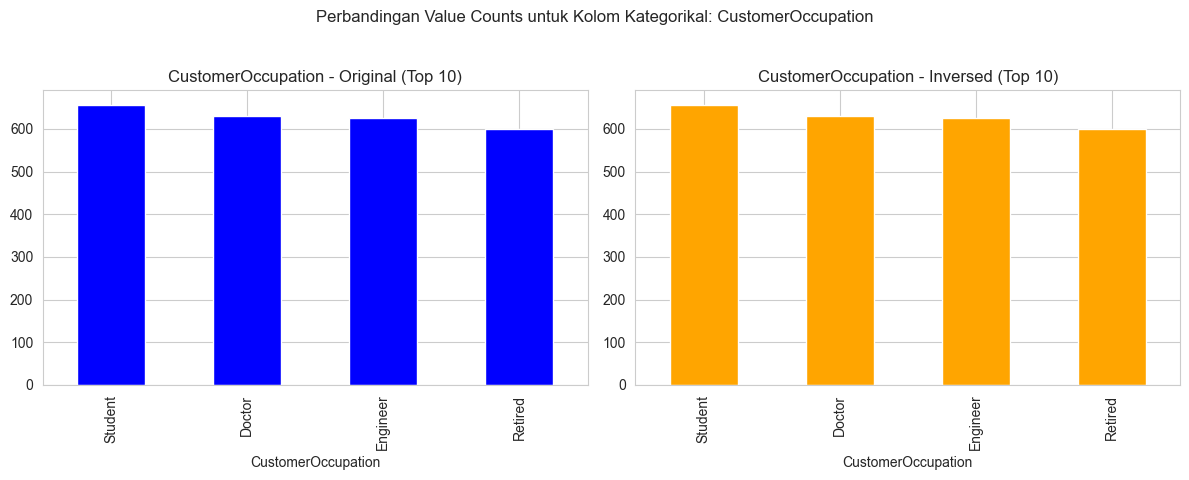

In [26]:
# Lakukan Inverse Transform
df_inversed = inverse_transform_all(data_improve.copy(), transformation_info)

# Tampilkan contoh data setelah inverse transform
print("\nContoh data Original (sebelum preprocessing awal):")
print(data_truly_original.head())
print("\nContoh data setelah Inverse Transform (df_inversed):")
print(df_inversed.head())

# Panggil fungsi visualisasi untuk membandingkan data original (sebelum preprocessing awal) 
# dengan data setelah inverse transform
visualize_comparison(data_truly_original.copy(), df_inversed.copy(), transformation_info)

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [27]:
# ---------------------------
# 6.e. Analisis dan Interpretasi Hasil Cluster (Setelah Inverse Transform)
# ---------------------------

# Tambahkan label cluster ke DataFrame
data_improve['Cluster'] = labels_best_before
# data_improve['Cluster_After_FS'] = labels_best_after
df_inversed['Cluster'] = data_improve['Cluster']

# Buat numeric_cols_inversed dengan menghilangkan kolom IP1-IP4 dan menambahkan 'IP Address'
numeric_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                'LoginAttempts', 'AccountBalance', 'TransactionGap',
                'IP1', 'IP2', 'IP3', 'IP4']
# Hapus IP1 sampai IP4 dan tambahkan 'IP Address'
numeric_cols_inversed = [col for col in numeric_cols if col not in ['IP1', 'IP2', 'IP3', 'IP4']] + ['IP Address']
print("Numeric columns (inversed):", numeric_cols_inversed)

# Karena kolom 'IP Address' berupa string, buat daftar kolom numerik sebenarnya
numeric_cols_inversed_numeric = [col for col in numeric_cols_inversed if col != 'IP Address']

# Agregasi untuk fitur numerik: hitung min, max, dan mean pada kolom numerik saja
agg_numeric = df_inversed.groupby('Cluster')[numeric_cols_inversed_numeric].agg(['min', 'max', 'mean'])
print("\nHasil Agregasi Fitur Numerik (tanpa 'IP Address'):")
print(agg_numeric)

# Agregasi untuk fitur kategorikal: hitung modus (nilai terbanyak muncul)
def mode_func(x):
    # Jika terdapat lebih dari satu modus, ambil yang pertama
    return x.mode().iloc[0] if not x.mode().empty else np.nan

# Tentukan kolom-kolom kategorikal (pastikan nama kolom sudah benar di df_inversed)
categorical_cols = ['Location', 'CustomerOccupation', 'Channel', 'IP Address']
agg_categorical = df_inversed.groupby('Cluster')[categorical_cols].agg(mode_func)

# Reset index untuk memudahkan akses kolom
agg_categorical = agg_categorical.reset_index()
print("\nHasil Agregasi Fitur Kategorikal:")
print(agg_categorical)

# Interpretasi Hasil Cluster
print("\nInterpretasi Hasil Cluster:")
for _, row in agg_categorical.iterrows():
    cluster = row['Cluster']
    # Mengambil statistik dari hasil agregasi numerik.
    ta_stats = agg_numeric.loc[cluster, ('TransactionAmount',)]
    age_stats = agg_numeric.loc[cluster, ('CustomerAge',)]
    
    loc_mode = row['Location']
    occ_mode = row['CustomerOccupation']
    ch_mode  = row['Channel']
    ip_mode  = row['IP Address']
    
    interpretasi = (
        f"Klaster {cluster} didapatkan karena TransactionAmount memiliki nilai rata-rata {ta_stats['mean']:.2f} "
        f"dengan batas minimum {ta_stats['min']:.2f} dan maksimum {ta_stats['max']:.2f}, "
        f"CustomerAge memiliki nilai rata-rata {age_stats['mean']:.2f}, serta mayoritas nasabah berasal dari "
        f"Location '{loc_mode}', dengan CustomerOccupation '{occ_mode}', Channel '{ch_mode}', dan IP Address (modus) '{ip_mode}'."
    )
    
    print(interpretasi)

print("\nContoh Data Setelah Inverse Transform (Sebelum Feature Selection):")
print(df_inversed.head())

# print("\nContoh Data Setelah Inverse Transform (Setelah Feature Selection):")
# print(df_inversed_after_fs.head())

# Analisis Cluster (Sebelum Feature Selection)
print("\n--- Analisis Cluster (Sebelum Feature Selection) ---")
for cluster_num in range(best_k_before):
    print(f"\nCluster {cluster_num}:")
    cluster_data = df_inversed[df_inversed['Cluster'] == cluster_num]
    print(cluster_data.describe(include='all')) # Sertakan statistik untuk kolom non-numerik

    # Analisis tambahan untuk kolom kategorikal (contoh)
    categorical_cols_to_analyze = ['Location', 'CustomerOccupation', 'Channel', 'TransactionType']
    for col in categorical_cols_to_analyze:
        if col in cluster_data.columns:
            print(f"\nDistribusi Kolom '{col}' di Cluster {cluster_num}:")
            print(cluster_data[col].value_counts(normalize=True))

Numeric columns (inversed): ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionGap', 'IP Address']

Hasil Agregasi Fitur Numerik (tanpa 'IP Address'):
        TransactionAmount                      CustomerAge                   \
                      min      max        mean         min   max       mean   
Cluster                                                                       
0                    0.26  1919.11  297.579693        18.0  80.0  44.653371   
1                   85.35   770.65  304.656000        31.0  67.0  55.000000   

        TransactionDuration                    LoginAttempts                \
                        min    max        mean           min  max     mean   
Cluster                                                                      
0                      10.0  300.0  119.646191           1.0  5.0  1.12485   
1                      30.0  178.0  118.200000           1.0  1.0  1.00000   

      

## Analisis Cluster Baru dan Implikasinya untuk Optimisasi Limit Kartu Kredit

### Cluster 0

**Karakteristik Data (Agregasi Numerik & Kategorikal):**

- **Volume Transaksi:**  
  Cluster 0 merupakan kelompok mayoritas (misalnya, ribuan transaksi) dengan nilai transaksi yang bervariasi dari sangat kecil (min: 0.26) hingga yang cukup besar (max: 1919.11), dengan rata-rata sebesar 297.58.  
- **Usia Nasabah:**  
  Usia nasabah berkisar antara 18 hingga 80 tahun, dengan rata-rata 44.65 tahun. Pola ini menunjukkan dominasi nasabah berusia paruh baya.  
- **Durasi Transaksi:**  
  Transaksi berlangsung antara 10 dan 300 detik dengan rata-rata 119.65 detik, menggambarkan variasi pada tingkat kecepatan dan efisiensi transaksi.  
- **Saldo Akun:**  
  Saldo nasabah beragam dari nilai minimum 101.25 hingga 14977.99, dengan rata-rata 5118.16. Rentang yang luas ini mengindikasikan adanya perbedaan signifikan dalam kondisi keuangan nasabah.  
- **TransactionGap:**  
  Nilai gap transaksi cukup besar secara absolut (rata-rata sekitar -4.21186 × 10⁷), meskipun angka ini memerlukan interpretasi lebih lanjut dari aspek bisnis atau metode perhitungannya.  

- **Fitur Kategorikal:**  
  - **Location:** Mode adalah *Fort Worth*. Meskipun distribusi lokasi cukup merata, Fort Worth muncul sebagai kota dengan frekuensi tertinggi.  
  - **CustomerOccupation:** Mode menunjukkan mayoritas nasabah berstatus *Student*.  
  - **Channel:** Mode penggunaan channel adalah *Branch*, menunjukkan bahwa nasabah cenderung melakukan transaksi secara langsung di kantor cabang.  
  - **IP Address:** Mode tercatat sebagai *200.136.146.93*, yang bisa mengindikasikan pola geografis atau jaringan tertentu dalam aktivitas transaksi.

**Implikasi untuk Optimisasi Limit Kartu Kredit dan Tujuan Bisnis:**

- **Meningkatkan Profitabilitas:**  
  Dengan variasi nilai transaksi yang besar dan saldo akun rata-rata yang stabil, penetapan limit yang lebih tinggi bisa dipertimbangkan untuk segmen ini. Namun, karena mayoritas nasabah merupakan kelompok usia paruh baya (44.65 tahun) dengan kecenderungan mahasiswa (Student), strategi harus mempertimbangkan potensi risiko kredit melalui evaluasi pola pengeluaran historis.
  
- **Mengurangi Risiko Kredit Macet:**  
  Segmentasi ini menunjukkan adanya keragaman dalam kondisi keuangan. Penggunaan data transaksi dan saldo yang besar perlu diimbangi dengan analisis risiko tambahan. Produk kartu kredit dengan limit menengah-hingga-tinggi, disertai mekanisme monitoring, bisa mengurangi risiko kredit macet.

- **Meningkatkan Kepuasan Nasabah & Personalisasi Penawaran:**  
  Dengan mayoritas nasabah yang berasal dari wilayah *Fort Worth* dan penggunaan channel *Branch*, bank dapat merancang program khusus—misalnya, penawaran eksklusif atau fitur digital di kantor cabang—untuk meningkatkan loyalitas dan kenyamanan nasabah.

---

### Cluster 1

**Karakteristik Data (Agregasi Numerik & Kategorikal):**

- **Volume Transaksi:**  
  Cluster 1 merupakan segmen kecil (contoh: hanya 5 transaksi) dengan nilai transaksi yang lebih sempit, yakni antara 85.35 dan 770.65, dengan rata-rata 304.66.  
- **Usia Nasabah:**  
  Usia nasabah cenderung lebih tinggi, dengan nilai minimum 31 dan maksimum 67, serta rata-rata 55.00 tahun.  
- **Durasi Transaksi & LoginAttempts:**  
  Durasi transaksi relatif konsisten (rata-rata 118.20 detik) dan semua transaksi tercatat dengan 1 kali login, menunjukkan proses transaksi yang efisien dan konsisten.  
- **Saldo Akun:**  
  Rata-rata saldo akun di segmen ini adalah 3178.94, yang lebih rendah dibandingkan Cluster 0, mengindikasikan keterbatasan keuangan.  
- **TransactionGap:**  
  Nilai gap transaksi hampir konsisten, mencerminkan standar perhitungan yang seragam dalam segmen ini.

- **Fitur Kategorikal:**  
  - **Location:** Mode adalah *Jacksonville*, menunjukkan konsentrasi geografis tertentu.  
  - **CustomerOccupation:** Sebagian besar nasabah adalah *Retired*, sesuai dengan rata-rata usia yang lebih tua.  
  - **Channel:** Mode penggunaan channel di Cluster 1 adalah *ATM*, yang mengindikasikan preferensi terhadap transaksi yang cepat dan mandiri.  
  - **IP Address:** Mode tercatat sebagai *100.4.40.132*, yang bisa mewakili jaringan atau area spesifik.

**Implikasi untuk Optimisasi Limit Kartu Kredit dan Tujuan Bisnis:**

- **Meningkatkan Profitabilitas:**  
  Meskipun nilai transaksi rata-rata serupa dengan Cluster 0, saldo akun yang lebih rendah pada Cluster 1 mengindikasikan bahwa limit kredit yang terlalu tinggi bisa meningkatkan risiko. Oleh karena itu, penetapan limit yang lebih konservatif dan disesuaikan dengan profil risiko pensiunan menjadi krusial untuk meningkatkan profitabilitas secara berkelanjutan.
  
- **Mengurangi Risiko Kredit Macet:**  
  Dengan mayoritas nasabah yang merupakan pensiunan (*Retired*) dan memiliki saldo yang lebih terbatas, penggunaan data historis dalam segmentasi ini membantu menentukan limit yang tidak memberatkan nasabah dan mengurangi kemungkinan kredit macet.
  
- **Meningkatkan Kepuasan Nasabah & Personalisasi Penawaran:**  
  Karena segmen ini cenderung mengakses layanan melalui ATM dan memiliki preferensi lokasi tertentu (*Jacksonville*), penawaran produk dapat disesuaikan—misalnya, dengan fitur kemudahan akses, suku bunga yang kompetitif, atau program loyalitas khusus untuk pensiunan—untuk meningkatkan kepuasan dan loyalitas nasabah.

---

## Rangkuman dan Strategi Bisnis Berdasarkan Segmentasi

Berdasarkan hasil clustering yang telah di‑inverse dan agregasi fitur:
- **Cluster 0** merupakan kelompok nasabah dengan volume transaksi besar, variasi kondisi keuangan yang signifikan, dan dominasi nasabah paruh baya (Student) yang cenderung mengakses layanan melalui kantor cabang (*Branch*).  
  - **Strategi:**  
    - Tawarkan limit kartu kredit yang lebih fleksibel dan menengah-tinggi dengan monitoring risiko tambahan.
    - Terapkan program personalisasi berbasis lokasi yang mendekati pola aktivitas di *Fort Worth*.
  
- **Cluster 1** merupakan segmen kecil dengan nasabah yang lebih tua (Retired) dan memiliki keterbatasan keuangan, dengan kecenderungan memanfaatkan channel otomatis seperti ATM.  
  - **Strategi:**  
    - Tetapkan limit yang lebih konservatif untuk mengurangi risiko gagal bayar.
    - Rancang penawaran produk yang memudahkan transaksi secara digital dan memberikan kemudahan bagi pensiunan, serta pertimbangkan fitur khusus seperti suku bunga kompetitif atau program bantuan finansial.

---

## Kaitan dengan Tujuan Bisnis

Analisis segmentasi ini secara langsung mendukung tujuan bisnis yang telah didefinisikan di README.md:
- **Meningkatkan Profitabilitas:**  
  Dengan menetapkan limit yang tepat berdasarkan profil penggunaan dan risiko, bank dapat mengoptimalkan pendapatan bunga dan menghindari over-limit pada nasabah yang berisiko.
- **Mengurangi Risiko Kredit Macet:**  
  Segmentasi yang mempertimbangkan profil keuangan dan perilaku transaksi memungkinkan penetapan limit yang realistis, terutama pada segmen dengan nasabah yang memiliki saldo lebih rendah.
- **Meningkatkan Kepuasan Nasabah:**  
  Penawaran produk yang disesuaikan dengan karakteristik segmen (misalnya, layanan khusus untuk pensiunan atau nasabah muda) berpotensi meningkatkan kenyamanan dan loyalitas nasabah.
- **Personalisasi Penawaran Produk:**  
  Insight dari cluster seperti distribusi lokasi, channel, dan status pekerjaan memberikan dasar untuk mengembangkan produk dan fitur yang lebih personal dan relevan dengan kebutuhan tiap segmen.

Dengan demikian, hasil analisis segmentasi ini tidak hanya memberikan pemahaman mendalam tentang perilaku transaksi nasabah, tetapi juga mendukung pengembangan strategi optimisasi limit kartu kredit yang sejalan dengan target bisnis—yaitu, peningkatan profitabilitas, pengurangan risiko kredit macet, peningkatan kepuasan nasabah, dan penawaran produk yang lebih personal.

---

Analisis ini dapat dijadikan sebagai landasan untuk penyusunan model optimisasi limit, sehingga setiap keputusan terkait penetapan limit akan semakin tepat sasaran dan mendukung tujuan bisnis secara menyeluruh.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [28]:
# Buat folder 'data' jika belum ada
os.makedirs("data", exist_ok=True)

# Simpan ke file CSV
data_improve.to_csv("bank_transaction_segmented_dataset.csv", index=False)
print("Data berhasil diekspor ke 'bank_transaction_segmented_dataset.csv'")

Data berhasil diekspor ke 'bank_transaction_segmented_dataset.csv'
